# Analysis Notebook

# Setup

In [ ]:
#| label: setup
#| include: false

knitr::opts_knit$set(root.dir = normalizePath(".."))
options(warn = -1)
packages <- c(
  "here","kableExtra","emmeans","rstatix","multcompView","brglm2","patchwork","gratia","pROC","caret",
  "mgcv","tidyr","purrr","corrplot","glmmTMB","performance","tibble","tidyverse",
  "dplyr","writexl","readxl","lubridate")

quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(pkg, dependencies = TRUE)))
  }
  suppressPackageStartupMessages(require(pkg, character.only = TRUE, quietly = TRUE))
  invisible(TRUE)
}

invisible(lapply(packages, quiet_load))

systemfonts and textshaping have been compiled with different versions of Freetype. Because of this, textshaping will not use the font cache provided by systemfonts

New names:
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`

New names:
• `` -> `...22`
• `` -> `...23`
• `` -> `...24`
• `` -> `...25`
• `` -> `...26`
• `` -> `...27`
• `` -> `...28`

# CPUE and BPUE derivation

## Length–weight model and predicted weights

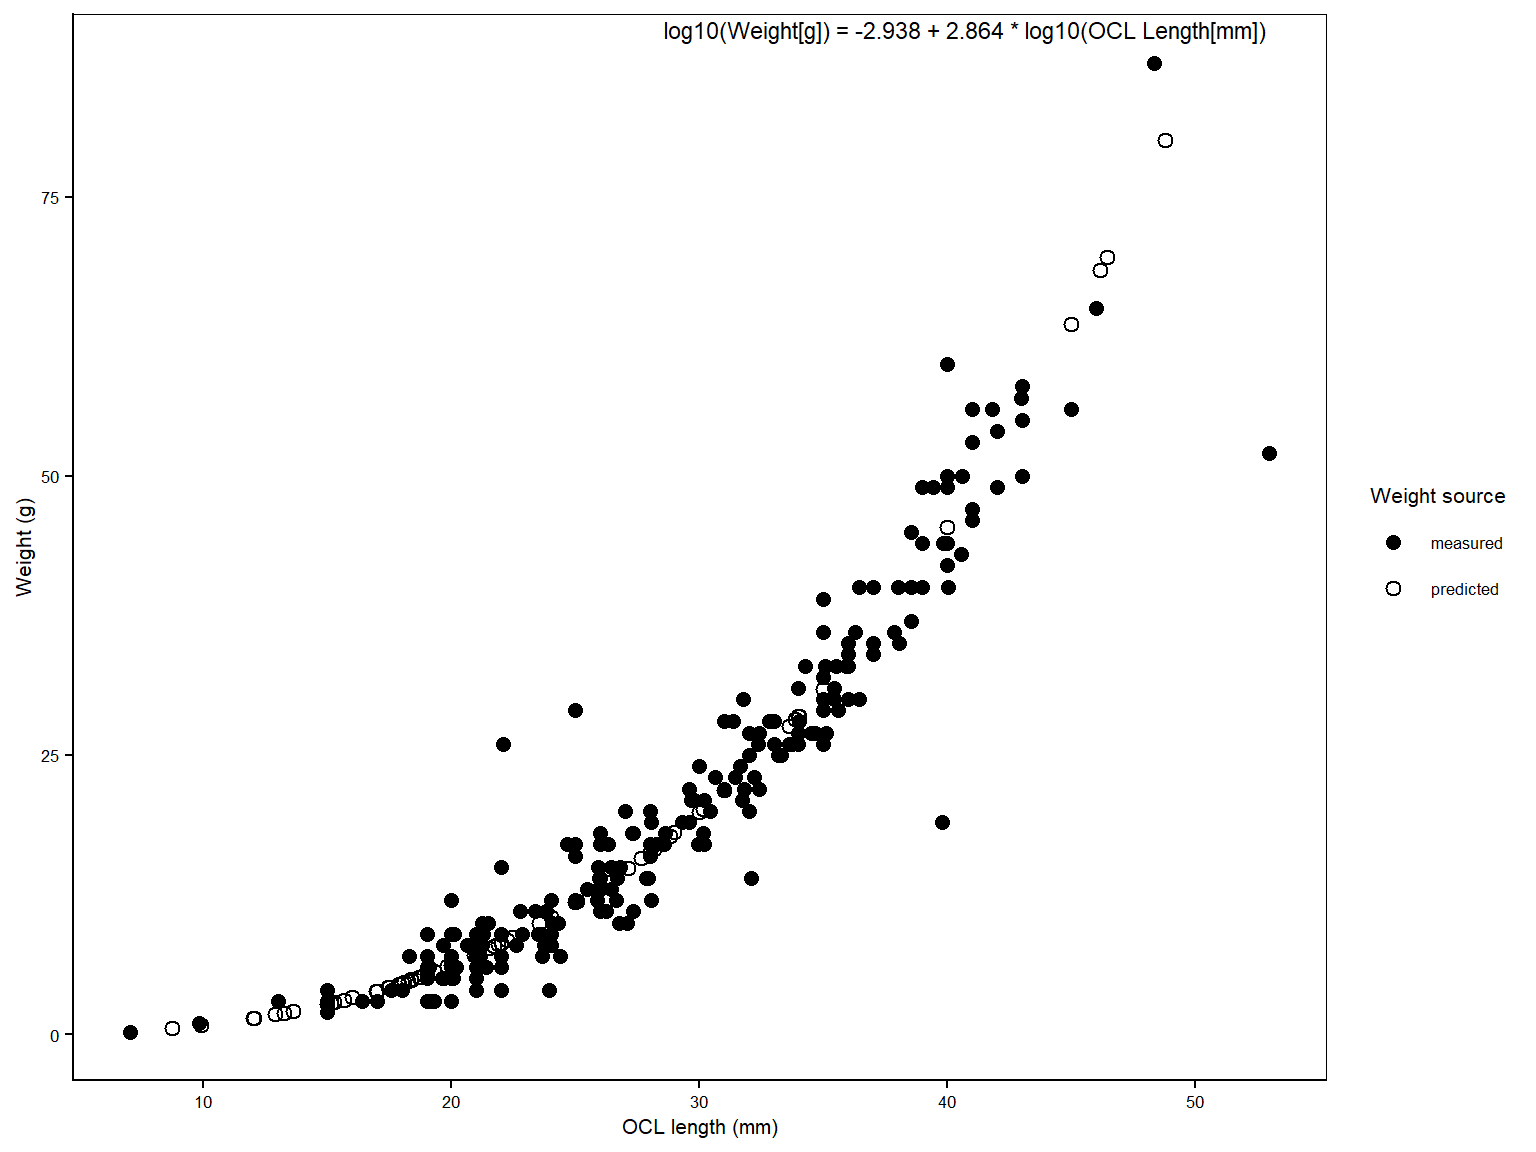

In [ ]:
#| label: fig-length-weight
#| include: true
#| fig-cap: "Length–weight relationship used to estimate missing kōura weights. Observed (measured) and model-predicted body weights are shown in relation to orbital carapace length (OCL). The log₁₀–log₁₀ regression was fitted to individuals with both length and weight measurements (n = 240) and used to estimate missing weights (n = 81). Predicted values were back-transformed using a lognormal bias correction factor. The fitted regression equation is shown on the plot."

lw_model <- lm(
log10(Weight_g) ~ log10(Length_mm),
data = Fish_data,
subset = Species_name == "Freshwater_crayfish" | Maori_name == "Kōura",
na.action = na.exclude
)

sigma_log10 <- sigma(lw_model)
c <- 10^(0.5 * sigma_log10^2)

Fish_data <- Fish_data |>
mutate(
is_koura = Species_name == "Freshwater_crayfish" | Maori_name == "Kōura",
Predicted_weight = case_when(
!is.na(Weight_g) ~ Weight_g,
is_koura ~ {
pred_log <- predict(lw_model, newdata = pick(everything()))
10^(pred_log) * c
},
TRUE ~ NA_real_
),
Weight_source = case_when(
is_koura & !is.na(Weight_g) ~ "measured",
is_koura & is.na(Weight_g) ~ "predicted",
TRUE ~ NA_character_
)
)

a <- coef(lw_model)[1]
b <- coef(lw_model)[2]
formula_text <- paste0(
"log10(Weight[g]) = ", round(a, 3), " + ", round(b, 3),
" * log10(OCL Length[mm])"
)

length_weight_plot <- ggplot(
Fish_data |> dplyr::filter(is_koura),
aes(x = Length_mm, y = Predicted_weight, shape = Weight_source)) +
geom_point(size = 2.2, colour = "black", stroke = 0.6) +
scale_shape_manual(values = c("measured" = 16, "predicted" = 1)) +
labs(x = "OCL length (mm)", y = "Weight (g)", shape = "Weight source") +
annotate("text", x = Inf, y = Inf, label = formula_text, hjust = 1.1, vjust = 1.3, size = 3) 

ggsave(filename = file.path(out_dir, "fig-length-weight.png"), plot = length_weight_plot, width = 170, height = 120, units = "mm", dpi = 1200, create.dir = TRUE)

length_weight_plot

## CPUE and BPUE calculations

In [ ]:
#| label: cpue-bpue-calculations
#| include: false

CPUE_BPUE_legacy <- Fish_data %>%
filter(!is.na(Species)) %>%
group_by(Monitoring_ID, Species, Net_type) %>%
dplyr::reframe(
Total_Individuals = sum(Amount, na.rm = TRUE),
Total_Weight      = sum(Predicted_weight, na.rm = TRUE),
Total_Effort      = dplyr::first(Amount_nets),
CPUE              = Total_Individuals / Total_Effort,
BPUE              = Total_Weight / Total_Effort,
Mean_Length       = mean(Length_mm, na.rm = TRUE),
Min_Length        = ifelse(all(is.na(Length_mm)), NA, min(Length_mm, na.rm = TRUE)),
Max_Length        = ifelse(all(is.na(Length_mm)), NA, max(Length_mm, na.rm = TRUE)),
Mean_Weight       = mean(Predicted_weight, na.rm = TRUE),
Min_Weight        = ifelse(all(is.na(Predicted_weight)), NA, min(Predicted_weight, na.rm = TRUE)),
Max_Weight        = ifelse(all(is.na(Predicted_weight)), NA, max(Predicted_weight, na.rm = TRUE))
)

CPUE_BPUE_weighted <- CPUE_BPUE_legacy %>%
group_by(Monitoring_ID, Species) %>%
summarise(
Total_Individuals       = sum(Total_Individuals, na.rm = TRUE),
Total_Weight            = sum(Total_Weight,      na.rm = TRUE),
Weighted_CPUE_numerator = sum(CPUE * Total_Effort,  na.rm = TRUE),
Weighted_BPUE_numerator = sum(BPUE * Total_Effort,  na.rm = TRUE),
Total_Effort_sum        = sum(Total_Effort,         na.rm = TRUE),
Mean_Length             = mean(Mean_Length, na.rm = TRUE),
Min_Length              = ifelse(all(is.na(Min_Length)), NA, min(Min_Length, na.rm = TRUE)),
Max_Length              = ifelse(all(is.na(Max_Length)), NA, max(Max_Length, na.rm = TRUE)),
Mean_Weight             = mean(Mean_Weight, na.rm = TRUE),
Min_Weight              = ifelse(all(is.na(Min_Weight)), NA, min(Min_Weight, na.rm = TRUE)),
Max_Weight              = ifelse(all(is.na(Max_Weight)), NA, max(Max_Weight, na.rm = TRUE)),
.groups = "drop"
) %>%
mutate(
Total_Effort_sum = ifelse(Monitoring_ID %in% c("96_0", "101_0", "117_1", "119_1"), 3, 4),
Weighted_CPUE    = Weighted_CPUE_numerator / Total_Effort_sum,
Weighted_BPUE    = Weighted_BPUE_numerator / Total_Effort_sum
)

species_presence_absence <- Fish_data %>%
filter(!is.na(Species)) %>%
distinct(Monitoring_ID, Species) %>%
mutate(Presence = 1) %>%
pivot_wider(
names_from  = Species,
values_from = Presence,
values_fill = list(Presence = 0),
names_prefix = "Presence_"
) %>%
mutate(Predator_Fish_Presence = pmax(Presence_Trout, Presence_Eel, Presence_Catfish))

CPUE_BPUE_weighted_summary <- CPUE_BPUE_weighted %>%
pivot_wider(
names_from  = Species,
values_from = c(
Total_Individuals, Weighted_CPUE, Weighted_BPUE, Total_Weight,
Mean_Length, Mean_Weight, Weighted_CPUE_numerator, Weighted_BPUE_numerator,
Total_Effort_sum, Min_Length, Max_Length, Min_Weight, Max_Weight
),
names_sep   = "_",
values_fill = list(Total_Individuals = 0, Weighted_CPUE = 0, Weighted_BPUE = 0)
) %>%
mutate(
Richness  = rowSums(dplyr::select(., starts_with("Total_Individuals_")) > 0),
Abundance = rowSums(dplyr::select(., starts_with("Total_Individuals_") & !ends_with(c("_Bullies", "_Common_smelt"))))
)

# Combined dataset and habitat classification

In [ ]:
#| label: combine-dataframes
#| include: false

unit_metadata <- Monitoring_data %>%
dplyr::select(Parameter, Unit) %>%
distinct()

Monitoring_summary <- Monitoring_data %>%
dplyr::select(-Group, -Notes, -Unit) %>%
pivot_wider(
names_from  = c(Parameter),
values_from = Value,
values_fill = list(Value = NA)
) %>%
mutate(across(
c(
Bottom_visible, Water_clarity, Depth_10m, Slope, Riparian_vegetation, Vegetation_nearby,
Overhanging_trees, Erosion, Structure, Bedrock, Boulders, Cobble, Gravel,
Sand, Mud, Organic_matter, Rock_size, Temperature, DO_mgl, DO_percent,
Conductivity, Specific_conductivity, pH, Wood_cover
),
~ as.numeric(.)
))

Weed_summary <- Weed_data %>%
group_by(Monitoring_ID, Weed_Type, Native_Status) %>%
summarise(Total_Cover = sum(Percentage_Cover, na.rm = TRUE), .groups = "drop") %>%
pivot_wider(
names_from  = c(Weed_Type, Native_Status),
values_from = Total_Cover,
values_fill = 0
)

Macroinvertebrates_sum <- Macroinvertebrates %>%
group_by(Monitoring_ID, Species) %>%
summarise(Total_amount = sum(Amount, na.rm = TRUE), .groups = "drop") %>%
pivot_wider(names_from = c(Species), values_from = Total_amount, values_fill = 0) %>%
mutate(
Invertebrates_Richness  = rowSums(dplyr::select(., -Monitoring_ID) > 0),
Invertebrates_Abundance = rowSums(dplyr::select(., -Monitoring_ID))
)

Monitoring_CPUE_data <- Site_info %>%
left_join(Monitoring_summary, by = "Monitoring_ID") %>%
left_join(
Weed_summary %>% dplyr::select(
Monitoring_ID,
Emergent_Native, Emergent_Non_Native,
Submerged_Native, Submerged_Non_Native, Turf_Native
),
by = "Monitoring_ID"
) %>%
left_join(CPUE_BPUE_weighted_summary, by = "Monitoring_ID") %>%
left_join(species_presence_absence, by = "Monitoring_ID") %>%
left_join(Macroinvertebrates_sum, by = "Monitoring_ID")

Monitoring_CPUE_data <- Monitoring_CPUE_data %>%
  mutate(
    Presence_rocks = if_else(Cobble > 1 | Boulders > 1, 1, 0),
    Slope_5m       = 5 / Distance_5m,
    Site_ID_       = Site_ID.x - 60,
    Monitoring_ID_ = paste0(
      as.numeric(sub("_.*", "", Monitoring_ID)) - 60,
      sub("^[^_]*", "", Monitoring_ID)
    ),
    Monitoring     = sub(".*?_", "", Monitoring_ID),
    Date           = as.Date(Date_Time),
    Time           = format(as.POSIXct(Date_Time), "%H:%M:%S"),
    Year           = lubridate::year(Date_Time),
    Month          = lubridate::month(Date_Time, label = TRUE),
    Day            = lubridate::day(Date_Time),
    Season         = case_when(
      Month %in% c("Dec", "Jan", "Feb") ~ "Summer",
      Month %in% c("Mar", "Apr", "May") ~ "Autumn",
      Month %in% c("Jun", "Jul", "Aug") ~ "Winter",
      Month %in% c("Sep", "Oct", "Nov") ~ "Spring",
      TRUE ~ NA_character_
    ),
    Date_Time_Numeric = as.numeric(Date_Time)
  )

habitat_classification <- Monitoring_CPUE_data %>%
dplyr::select(
Monitoring_ID, DHT, Lake,
Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter,
Emergent_Native, Emergent_Non_Native,
Submerged_Native, Submerged_Non_Native, Wood_cover
) %>%
pivot_longer(
cols = c(
Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter,
Emergent_Native, Emergent_Non_Native,
Submerged_Native, Submerged_Non_Native, Wood_cover
),
names_to = "Type",
values_to = "Percentage"
) %>%
group_by(Monitoring_ID) %>%
summarise(
Rocky_Percentage = sum(Percentage[Type %in% c("Bedrock", "Boulders", "Cobble")], na.rm = TRUE),
Sand_Percentage  = sum(Percentage[Type == "Sand"], na.rm = TRUE),
Mud_Percentage   = sum(Percentage[Type %in% c("Mud", "Organic_matter")], na.rm = TRUE),
Emergent_Percentage = sum(Percentage[Type == "Emergent_Native"], na.rm = TRUE),
Substrate_index = sum(
0.08 * Percentage[Type == "Bedrock"] +
0.07 * Percentage[Type == "Boulders"] +
0.06 * Percentage[Type == "Cobble"] +
0.04 * Percentage[Type == "Gravel"] +
0.03 * Percentage[Type == "Sand"] +
0.02 * Percentage[Type == "Organic_matter"] +
0.01 * Percentage[Type == "Mud"],
na.rm = TRUE
),
Substrate_CV = {
substrate_vals <- Percentage[Type %in% c("Bedrock", "Boulders", "Cobble", "Gravel", "Sand", "Mud", "Organic_matter")]
substrate_vals <- substrate_vals[!is.na(substrate_vals)]
if (length(substrate_vals) > 1 && mean(substrate_vals) > 0) {
sd(substrate_vals) / mean(substrate_vals)
} else {
NA_real_
}
},
.groups = "drop"
) %>%
mutate(
Habitat_Type = case_when(
Rocky_Percentage > 25 ~ "Rocky",
Emergent_Percentage > 25 ~ "Emergent Macrophyte",
Sand_Percentage >= Mud_Percentage ~ "Sandy",
TRUE ~ "Muddy"
)
) %>%
dplyr::select(Monitoring_ID, Habitat_Type, Substrate_index, Substrate_CV)

Monitoring_CPUE_data <- Monitoring_CPUE_data %>%
left_join(habitat_classification, by = "Monitoring_ID")

#writexl::write_xlsx(Monitoring_CPUE_data, file.path(der_data_dir, "Monitoring_CPUE_data.xlsx"))
#write.csv(Monitoring_CPUE_data, file.path(der_data_dir, "Monitoring_CPUE_data.csv"), row.names = FALSE)
#write.csv(habitat_classification, file.path(der_data_dir, "habitat_classification.csv"), row.names = FALSE)

#head(Monitoring_CPUE_data)

## habitat-correlation

In [ ]:
#| label: habitat-correlation
#| include: true

cor(habitat_classification$Substrate_index,
habitat_classification$Substrate_CV,
use = "complete.obs")

[1] -0.4785045

# Lake overview table

In [ ]:
#| label: tbl-lake-overview
#| echo: FALSE
#| tbl-cap: "Physical, morphometric, and trophic characteristics of the five Rotorua Te Arawa lakes surveyed, including sampling dates and number of littoral sites sampled per lake. Lake surface area, perimeter length, catchment area, depth, elevation, mixing regime, and trophic state for 2024, values are derived from the Land, Air, Water Aotearoa (LAWA) database (@LAWA2025)."

lake_data <- data.frame(
  `Lake name` = c("Rotorua", "Rotoiti", "Rotoehu", "Rotomā", "Ōkāreka"),
  `Sampling date (number of sites)` = c("20/02/2025 (12)", "15/01/2025 (12)", "10/12/2024 (12)", "6/11/2024 (12)", "31/10/2024 (10), 22/01/2025 (2)"),
  `Surface area (km²)` = c(81, 34, 8, 11, 3),
  `Perimeter length (km)` = c(45, 61, 40, 24, 11),
  `Catchment area size (km²)` = c(508, 123.7, 49.2, 27.8, 19.6),
  `Mean depth (m)` = c(11, 31.5, 8, 36.9, 20),
  `Maximum depth (m)` = c(45, 124, 13.5, 83, 33.5),
  `Elevation (m)` = c(280, 279, 295, 316, 355),
  `Mixing regime` = c("Polymictic", "Stratified", "Polymictic", "Stratified", "Stratified"),
  `Trophic state` = c("Eutrophic", "Mesotrophic", "Eutrophic", "Oligotrophic", "Mesotrophic")
)

kable(lake_data, caption = "Table 1: Physical, morphometric, and trophic characteristics of the five Rotorua Te Arawa lakes surveyed.")

  -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  Lake.name   Sampling.date..number.of.sites.     Surface.area..km..   Perimeter.length..km.   Catchment.area.size..km..   Mean.depth..m.   Maximum.depth..m.   Elevation..m. Mixing.regime   Trophic.state
  ----------- --------------------------------- -------------------- ----------------------- --------------------------- ---------------- ------------------- --------------- --------------- ---------------
  Rotorua     20/02/2025 (12)                                     81                      45                       508.0             11.0                45.0             280 Polymictic      Eutrophic

  Rotoiti     15/01/2025 (12)                                     34                      61                       123.7             31.5               124.0             279 Stratified      Mesotrophic

  Rotoehu     10/12/2024 (12)                                      8                      40                        49.2              8.0                13.5             295 Polymictic      Eutrophic

  Rotomā      6/11/2024 (12)                                      11                      24                        27.8             36.9                83.0             316 Stratified      Oligotrophic

  Ōkāreka     31/10/2024 (10), 22/01/2025 (2)                      3                      11                        19.6             20.0                33.5             355 Stratified      Mesotrophic
  -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

  : Table 1: Physical, morphometric, and trophic characteristics of the
  five Rotorua Te Arawa lakes surveyed. {.cell}


# Overview of environmental and biotic variables

In [ ]:
#| label: tbl-environmental-biotic-overview
#| echo: FALSE
#| tbl-cap: "Overview of environmental and biotic variables measured at littoral sampling sites, including variable descriptions, units, and hypothesised relevance for kōura (Paranephrops planifrons). Variables were selected a priori based on known habitat requirements, physiological constraints, and potential biotic interactions influencing kōura occurrence, abundance, and biomass in lake littoral zones."

biotic_vars <- data.frame(
  Variable = c(
    "Lake identity (LID)",
    "Substrate index",
    "Slope",
    "Riparian vegetation",
    "Overhanging trees",
    "Wood cover",
    "Emergent and submerged vegetation",
    "Temperature",
    "Dissolved oxygen",
    "Specific conductivity",
    "pH",
    "Fish presence"
  ),
  `Description / Unit` = c(
    "Categorical variable identifying lake",
    "Index based on % cover of bedrock, boulders, cobble, gravel, sand, mud, and organic matter",
    "Slope from shoreline to the 5 m depth contour",
    "Percentage cover of vegetation growing in the riparian zone",
    "Percentage cover of trees hanging over the shoreline",
    "Cover of wooden logs and tree branches in the sample site",
    "Percentage cover of vegetation divided over emergent/submerged and native/non-native species",
    "Temperature of surface water in °C",
    "Dissolved oxygen concentration in mg L⁻¹",
    "Electrical conductivity of the water in µS cm⁻¹",
    "Acidity or alkalinity of the water",
    "Presence/absence of selected native and non-native fish species"
  ),
  `Hypothesised importance for kōura` = c(
    "Captures unmeasured lake specific differences in water chemistry, productivity, and catchment characteristics.",
    "Important for burrowing and shelter availability. Coarser substrates increase shelter availability through more crevices.",
    "Steeper slopes facilitate access to deeper water during daylight refuging and associate with coarser substrates.",
    "Contributes detrital inputs, bank stability, and shading at the water’s edge.",
    "Provides direct shading and structural inputs into littoral habitats.",
    "Provides physical structure creating refuge spaces and supports macroinvertebrate prey availability.",
    "Native vegetation provides cover and food source; non-native may alter movement and habitat conditions.",
    "Influences metabolic rate, activity, physiological stress, and habitat suitability.",
    "Essential for respiration; reduced oxygen may constrain activity and habitat use.",
    "Reflects overall lake productivity, supporting food availability.",
    "Influences moulting success and exoskeleton strength, affected by acidity or calcium levels.",
    "Fish act as predators, competitors, or indirectly modify habitat structure."
  ),
  References = c(
    "Zuur et al., (2009)",
    "Usio & Townsend, (2000); Kusabs et al., (2015b)",
    "Devcich, (1979); Kusabs et al., (2015b)",
    "Parkyn et al., (2002)",
    "Smith et al., (1996); Vedia et al., (2017)",
    "Parkyn et al., (2009)",
    "Coffey & Clayton, (1988); Kusabs & Quinn, (2009)",
    "Devcich, (1979); Hammond et al., (2006); Parkyn et al., (2002); Parkyn & Collier, (2002); Angilletta et al., (2004)",
    "Hammond et al., (2006); Broughton et al., (2017)",
    "Devcich, (1979)",
    "Olsson et al., (2006)",
    "Shave et al., (1994); Barnes, (1996); Usio & Townsend, (2000); Barnes & Hicks, (2003)"
  )
)

kable(biotic_vars, caption = "Table 2: Overview of environmental and biotic variables measured at littoral sampling sites.")

  ----------------------------------------------------------------------------------------------
  Variable       Description...Unit   Hypothesised.importance.for.kōura   References
  -------------- -------------------- ----------------------------------- ----------------------
  Lake identity  Categorical variable Captures unmeasured lake specific   Zuur et al., (2009)
  (LID)          identifying lake     differences in water chemistry,     
                                      productivity, and catchment         
                                      characteristics.                    

  Substrate      Index based on %     Important for burrowing and shelter Usio & Townsend,
  index          cover of bedrock,    availability. Coarser substrates    (2000); Kusabs et al.,
                 boulders, cobble,    increase shelter availability       (2015b)
                 gravel, sand, mud,   through more crevices.              
                 and organic matter                                       

  Slope          Slope from shoreline Steeper slopes facilitate access to Devcich, (1979);
                 to the 5 m depth     deeper water during daylight        Kusabs et al., (2015b)
                 contour              refuging and associate with coarser 
                                      substrates.                         

  Riparian       Percentage cover of  Contributes detrital inputs, bank   Parkyn et al., (2002)
  vegetation     vegetation growing   stability, and shading at the       
                 in the riparian zone water's edge.                       

  Overhanging    Percentage cover of  Provides direct shading and         Smith et al., (1996);
  trees          trees hanging over   structural inputs into littoral     Vedia et al., (2017)
                 the shoreline        habitats.                           

  Wood cover     Cover of wooden logs Provides physical structure         Parkyn et al., (2009)
                 and tree branches in creating refuge spaces and supports 
                 the sample site      macroinvertebrate prey              
                                      availability.                       

  Emergent and   Percentage cover of  Native vegetation provides cover    Coffey & Clayton,
  submerged      vegetation divided   and food source; non-native may     (1988); Kusabs &
  vegetation     over                 alter movement and habitat          Quinn, (2009)
                 emergent/submerged   conditions.                         
                 and                                                      
                 native/non-native                                        
                 species                                                  

  Temperature    Temperature of       Influences metabolic rate,          Devcich, (1979);
                 surface water in °C  activity, physiological stress, and Hammond et al.,
                                      habitat suitability.                (2006); Parkyn et al.,
                                                                          (2002); Parkyn &
                                                                          Collier, (2002);
                                                                          Angilletta et al.,
                                                                          (2004)

  Dissolved      Dissolved oxygen     Essential for respiration; reduced  Hammond et al.,
  oxygen         concentration in mg  oxygen may constrain activity and   (2006); Broughton et
                 L⁻¹                  habitat use.                        al., (2017)

  Specific       Electrical           Reflects overall lake productivity, Devcich, (1979)
  conductivity   conductivity of the  supporting food availability.       
                 water in µS cm⁻¹                                         

  pH             Acidity or           Influences moulting success and     Olsson et al., (2006)
                 alkalinity of the    exoskeleton strength, affected by   
                 water                acidity or calcium levels.          

  Fish presence  Presence/absence of  Fish act as predators, competitors, Shave et al., (1994);
                 selected native and  or indirectly modify habitat        Barnes, (1996); Usio &
                 non-native fish      structure.                          Townsend, (2000);
                 species                                                  Barnes & Hicks, (2003)
  ----------------------------------------------------------------------------------------------

  : Table 2: Overview of environmental and biotic variables measured at
  littoral sampling sites. {.cell}


# Environmental and fish summaries (tables)

In [ ]:
#| label: tbl-env-fish-summary
#| include: true
#| tbl-cap: "Distribution of environmental and biotic variables measured at littoral sampling sites across five Te Arawa lakes in the Rotorua region of Aotearoa New Zealand."

M_C_data <- Monitoring_CPUE_data
lake_order <- c("Rotorua", "Rotoiti", "Rotoehu", "Rotomā", "Ōkāreka")
M_C_data$Lake <- factor(M_C_data$Lake, levels = lake_order)

ci95 <- function(x) {
  x <- x[!is.na(x)]
  n <- length(x)
  if (n < 2) return(c(NA_real_, NA_real_))
  se <- sd(x) / sqrt(n)
  tcrit <- qt(0.975, df = n - 1)
  m <- mean(x)
  c(m - tcrit * se, m + tcrit * se)
}

unit_lookup <- Monitoring_data %>%
  dplyr::select(Parameter, Unit) %>%
  dplyr::distinct() %>%
  dplyr::mutate(
    Variable = dplyr::case_when(
      Parameter == "Riparian_vegetation"       ~ "Riparian_vegetation",
      Parameter == "Overhanging_trees"         ~ "Overhanging_trees",
      Parameter == "Wood_cover"                ~ "Wood_cover",
      Parameter == "Temperature"               ~ "Temperature",
      Parameter == "DO_mgl"                    ~ "DO_mgl",
      Parameter == "pH"                        ~ "pH",
      Parameter == "Specific_conductivity"     ~ "Specific_conductivity",
      Parameter == "Substrate_index"           ~ "Substrate_index",
      Parameter == "Slope_5m"                  ~ "Slope_5m",
      TRUE ~ NA_character_
    )
  ) %>%
  dplyr::filter(!is.na(Variable)) %>%
  dplyr::select(Variable, Unit) %>%
  dplyr::distinct()

# Add units for derived variables (not in Monitoring_data)
derived_units <- tibble::tibble(
  Variable = c("Emergent_vegetation", "Submerged_vegetation"),
  Unit     = c("%", "%")
)

# Fish presence units (binary)
fish_units <- tibble::tibble(
  Variable = c(
    "Presence_Eel","Presence_Common_smelt","Presence_Catfish",
    "Presence_Goldfish","Presence_Kōaro","Presence_Trout"
  ),
  Unit = ""
)

unit_lookup_all <- dplyr::bind_rows(unit_lookup, derived_units, fish_units) %>%
  dplyr::distinct(Variable, .keep_all = TRUE)

# ---- Environmental summary ----
Env_data <- M_C_data %>%
  dplyr::mutate(
    Emergent_vegetation  = Emergent_Native + Emergent_Non_Native,
    Submerged_vegetation = Submerged_Native + Submerged_Non_Native
  ) %>%
  dplyr::select(
    Lake, Substrate_index, Slope_5m, Riparian_vegetation, Overhanging_trees, Wood_cover,
    Temperature, DO_mgl, pH, Specific_conductivity, Emergent_vegetation, Submerged_vegetation
  ) %>%
  tidyr::pivot_longer(-Lake, names_to = "Variable", values_to = "Value")

Env_summary_table <- Env_data %>%
  dplyr::group_by(Lake, Variable) %>%
  dplyr::summarise(
    n       = sum(!is.na(Value)),
    Mean    = mean(Value, na.rm = TRUE),
    Median  = median(Value, na.rm = TRUE),
    Min     = min(Value, na.rm = TRUE),
    Max     = max(Value, na.rm = TRUE),
    CI_low  = ci95(Value)[1],
    CI_high = ci95(Value)[2],
    .groups = "drop"
  )

Env_summary_all <- Env_data %>%
  dplyr::group_by(Variable) %>%
  dplyr::summarise(
    Lake    = "All lakes",
    n       = sum(!is.na(Value)),
    Mean    = mean(Value, na.rm = TRUE),
    Median  = median(Value, na.rm = TRUE),
    Min     = min(Value, na.rm = TRUE),
    Max     = max(Value, na.rm = TRUE),
    CI_low  = ci95(Value)[1],
    CI_high = ci95(Value)[2],
    .groups = "drop"
  ) %>%
  dplyr::select(Lake, dplyr::everything())

Env_summary_table <- dplyr::bind_rows(Env_summary_table, Env_summary_all)

# ---- Fish presence summary ----
Fish_data_long <- M_C_data %>%
  dplyr::select(
    Lake, Presence_Eel, Presence_Common_smelt, Presence_Catfish,
    Presence_Goldfish, Presence_Kōaro, Presence_Trout
  ) %>%
  tidyr::pivot_longer(-Lake, names_to = "Variable", values_to = "Presence")

Fish_summary_lake <- Fish_data_long %>%
  dplyr::group_by(Lake, Variable) %>%
  dplyr::summarise(
    n       = sum(!is.na(Presence)),
    Mean    = mean(Presence, na.rm = TRUE),
    Median  = median(Presence, na.rm = TRUE),
    Min     = min(Presence, na.rm = TRUE),
    Max     = max(Presence, na.rm = TRUE),
    CI_low  = ci95(Presence)[1],
    CI_high = ci95(Presence)[2],
    .groups = "drop"
  )

Fish_summary_all <- Fish_data_long %>%
  dplyr::group_by(Variable) %>%
  dplyr::summarise(
    Lake    = "All lakes",
    n       = sum(!is.na(Presence)),
    Mean    = mean(Presence, na.rm = TRUE),
    Median  = median(Presence, na.rm = TRUE),
    Min     = min(Presence, na.rm = TRUE),
    Max     = max(Presence, na.rm = TRUE),
    CI_low  = ci95(Presence)[1],
    CI_high = ci95(Presence)[2],
    .groups = "drop"
  ) %>%
  dplyr::select(Lake, dplyr::everything())

Fish_summary_table <- dplyr::bind_rows(Fish_summary_lake, Fish_summary_all)

# ---- Combine + attach units + make Variable labels pretty ----
EnvBio_summary_table <- dplyr::bind_rows(Env_summary_table, Fish_summary_table) %>%
  dplyr::left_join(unit_lookup_all, by = "Variable") %>%
  dplyr::mutate(
    Variable = dplyr::recode(
      Variable,
      Substrate_index       = "Substrate index",
      Slope_5m              = "Slope 5m",
      Riparian_vegetation   = "Riparian vegetation",
      Overhanging_trees     = "Overhanging trees",
      Wood_cover            = "Wood cover",
      Emergent_vegetation   = "Emergent vegetation",
      Submerged_vegetation  = "Submerged vegetation",
      Temperature           = "Temperature",
      DO_mgl                = "Dissolved oxygen",
      Specific_conductivity = "Specific conductivity",
      pH                    = "pH",
      Presence_Catfish      = "Presence Catfish",
      Presence_Eel          = "Presence Eel",
      Presence_Goldfish     = "Presence Goldfish",
      Presence_Common_smelt = "Presence Common smelt",
      Presence_Kōaro        = "Presence Kōaro",
      Presence_Trout        = "Presence Trout"
    ),
    Unit = dplyr::coalesce(Unit, "")
  )

lake_order_exact <- c("Rotorua", "Rotoiti", "Rotoehu", "Rotomā", "Ōkāreka", "All lakes")

var_order_exact <- c("Substrate index","Slope 5m","Riparian vegetation","Overhanging trees","Wood cover","Emergent vegetation", "Submerged vegetation", "Temperature", "Dissolved oxygen", "Specific conductivity","pH", "Presence Catfish", "Presence Eel", "Presence Goldfish", "Presence Common smelt", "Presence Kōaro", "Presence Trout")

EnvBio_summary_table <- EnvBio_summary_table %>%
  dplyr::mutate(
    Lake     = factor(as.character(Lake), levels = lake_order_exact),
    Variable = factor(as.character(Variable), levels = var_order_exact)
  ) %>%
  dplyr::select(Lake, Variable, Unit, n, Mean, Median, Min, Max, CI_low, CI_high) %>%
  dplyr::arrange(Variable, Lake) %>%
  dplyr::mutate(
    Lake     = as.character(Lake),
    Variable = as.character(Variable)
  )

# Save if you still want the CSV
write.csv(
  EnvBio_summary_table,
  file = file.path(out_dir, "EnvBio_summary_table.csv"),
  row.names = FALSE
)

knitr::kable(EnvBio_summary_table, digits = 2, align = c("l","l","l","r","r","r","r","r","r","r"))

  ------------------------------------------------------------------------------------------------
  Lake      Variable          Unit        n     Mean   Median      Min      Max   CI_low   CI_high
  --------- ----------------- -------- ---- -------- -------- -------- -------- -------- ---------
  Rotorua   Substrate index              12     3.66     3.30     2.80     6.30     3.01      4.31

  Rotoiti   Substrate index              12     3.92     3.20     2.00     8.00     2.73      5.11

  Rotoehu   Substrate index              12     2.77     2.45     2.00     4.90     2.15      3.39

  Rotomā    Substrate index              12     3.50     3.03     2.00     6.20     2.64      4.36

  Ōkāreka   Substrate index              12     2.86     2.70     1.00     6.20     1.92      3.79

  All lakes Substrate index              60     3.34     3.00     1.00     8.00     2.98      3.71

  Rotorua   Slope 5m                     12     0.02     0.01     0.01     0.16     0.00      0.05

  Rotoiti   Slope 5m                     12     0.09     0.07     0.04     0.30     0.04      0.14

  Rotoehu   Slope 5m                     12     0.08     0.06     0.02     0.27     0.03      0.12

  Rotomā    Slope 5m                     12     0.07     0.06     0.01     0.23     0.03      0.11

  Ōkāreka   Slope 5m                     12     0.11     0.13     0.01     0.20     0.07      0.15

  All lakes Slope 5m                     60     0.08     0.06     0.01     0.30     0.06      0.09

  Rotorua   Riparian          \%         12    67.50   100.00     0.00   100.00    40.12     94.88
            vegetation                                                                   

  Rotoiti   Riparian          \%         12    92.50   100.00    20.00   100.00    77.88    107.12
            vegetation                                                                   

  Rotoehu   Riparian          \%         12    67.50   100.00     0.00   100.00    36.95     98.05
            vegetation                                                                   

  Rotomā    Riparian          \%         12    63.33    90.00     0.00   100.00    35.13     91.53
            vegetation                                                                   

  Ōkāreka   Riparian          \%         12    75.83   100.00     0.00   100.00    48.01    103.66
            vegetation                                                                   

  All lakes Riparian          \%         60    73.33   100.00     0.00   100.00    62.65     84.02
            vegetation                                                                   

  Rotorua   Overhanging trees \%         12    46.67    30.00     0.00   100.00    15.50     77.83

  Rotoiti   Overhanging trees \%         12    54.17    65.00     0.00   100.00    23.22     85.11

  Rotoehu   Overhanging trees \%         12    35.83     0.00     0.00   100.00     5.25     66.42

  Rotomā    Overhanging trees \%         12    52.50    55.00     0.00   100.00    22.44     82.56

  Ōkāreka   Overhanging trees \%         12    52.50    65.00     0.00   100.00    21.71     83.29

  All lakes Overhanging trees \%         60    48.33    30.00     0.00   100.00    36.15     60.52

  Rotorua   Wood cover        \%         12     8.33     3.50     0.00    30.00     1.98     14.69

  Rotoiti   Wood cover        \%         12     4.25     1.50     0.00    20.00     0.31      8.19

  Rotoehu   Wood cover        \%         12    14.92    10.00     3.00    40.00     7.24     22.60

  Rotomā    Wood cover        \%         12    10.00    10.00     0.00    30.00     4.13     15.87

  Ōkāreka   Wood cover        \%         12    11.25     7.50     0.00    40.00     2.56     19.94

  All lakes Wood cover        \%         60     9.75     5.00     0.00    40.00     6.96     12.54

  Rotorua   Emergent          \%         12     0.00     0.00     0.00     0.00     0.00      0.00
            vegetation                                                                   

  Rotoiti   Emergent          \%         12     9.50     0.00     0.00   100.00    -8.71     27.71
            vegetation                                                                   

  Rotoehu   Emergent          \%         12     8.75     0.00     0.00    35.00    -0.74     18.24
            vegetation                                                                   

  Rotomā    Emergent          \%         12    10.83     0.00     0.00    80.00    -4.78     26.45
            vegetation                                                                   

  Ōkāreka   Emergent          \%         12    22.50     0.00     0.00    90.00    -0.35     45.35
            vegetation                                                                   

  All lakes Emergent          \%         60    10.32     0.00     0.00   100.00     3.98     16.65
            vegetation                                                                   

  Rotorua   Submerged         \%         12     0.83     0.00     0.00    10.00    -1.00      2.67
            vegetation                                                                   

  Rotoiti   Submerged         \%         12     0.83     0.00     0.00    10.00    -1.00      2.67
            vegetation                                                                   

  Rotoehu   Submerged         \%         12    51.42    52.50     0.00   100.00    20.51     82.33
            vegetation                                                                   

  Rotomā    Submerged         \%         12    21.67    10.00     0.00    85.00     2.21     41.12
            vegetation                                                                   

  Ōkāreka   Submerged         \%         12    10.83     0.00     0.00   100.00    -7.43     29.10
            vegetation                                                                   

  All lakes Submerged         \%         60    17.12     0.00     0.00   100.00     8.42     25.81
            vegetation                                                                   

  Rotorua   Temperature       Degree C   12    23.15    23.25    21.80    25.30    22.52     23.78

  Rotoiti   Temperature       Degree C   12    21.62    21.50    20.60    23.80    21.03     22.22

  Rotoehu   Temperature       Degree C   12    22.11    22.05    21.20    23.00    21.72     22.49

  Rotomā    Temperature       Degree C   12    17.02    16.85    16.30    18.10    16.64     17.39

  Ōkāreka   Temperature       Degree C   12    16.98    16.30    16.00    20.70    15.93     18.04

  All lakes Temperature       Degree C   60    20.18    21.25    16.00    25.30    19.44     20.91

  Rotorua   Dissolved oxygen  mg/l       12     8.49     7.92     5.25    11.05     7.39      9.59

  Rotoiti   Dissolved oxygen  mg/l       12     9.59     9.75     6.80    10.64     8.92     10.25

  Rotoehu   Dissolved oxygen  mg/l       12    10.36    10.77     8.85    11.79     9.67     11.05

  Rotomā    Dissolved oxygen  mg/l       12     9.72     9.76     8.66    10.31     9.45      9.98

  Ōkāreka   Dissolved oxygen  mg/l       12     9.37     9.38     8.83     9.74     9.20      9.53

  All lakes Dissolved oxygen  mg/l       60     9.50     9.62     5.25    11.79     9.20      9.81

  Rotorua   Specific          µS/cm      12   205.36   188.27   156.20   443.01   156.39    254.33
            conductivity                                                                 

  Rotoiti   Specific          µS/cm      12   163.11   158.70   155.79   196.01   156.22    170.00
            conductivity                                                                 

  Rotoehu   Specific          µS/cm      12   458.89   458.22   455.44   464.72   456.91    460.87
            conductivity                                                                 

  Rotomā    Specific          µS/cm      12   162.90   161.79   156.73   174.96   159.94    165.85
            conductivity                                                                 

  Ōkāreka   Specific          µS/cm      12    76.34    76.15    75.62    78.59    75.82     76.86
            conductivity                                                                 

  All lakes Specific          µS/cm      60   213.32   162.55    75.62   464.72   178.41    248.23
            conductivity                                                                 

  Rotorua   pH                           12     6.94     7.04     3.78     7.69     6.29      7.60

  Rotoiti   pH                           12     8.67     8.73     8.08     9.02     8.46      8.87

  Rotoehu   pH                           12     8.83     8.91     8.46     9.21     8.68      8.99

  Rotomā    pH                           12     7.80     7.92     6.44     8.56     7.47      8.13

  Ōkāreka   pH                           12     8.32     8.29     7.77     9.00     8.15      8.50

  All lakes pH                           60     8.11     8.28     3.78     9.21     7.89      8.34

  Rotorua   Presence Catfish             12     0.08     0.00     0.00     1.00    -0.10      0.27

  Rotoiti   Presence Catfish             12     0.42     0.00     0.00     1.00     0.09      0.74

  Rotoehu   Presence Catfish             12     0.00     0.00     0.00     0.00     0.00      0.00

  Rotomā    Presence Catfish             12     0.00     0.00     0.00     0.00     0.00      0.00

  Ōkāreka   Presence Catfish             12     0.00     0.00     0.00     0.00     0.00      0.00

  All lakes Presence Catfish             60     0.10     0.00     0.00     1.00     0.02      0.18

  Rotorua   Presence Eel                 12     0.33     0.00     0.00     1.00     0.02      0.65

  Rotoiti   Presence Eel                 12     0.08     0.00     0.00     1.00    -0.10      0.27

  Rotoehu   Presence Eel                 12     0.00     0.00     0.00     0.00     0.00      0.00

  Rotomā    Presence Eel                 12     0.25     0.00     0.00     1.00    -0.04      0.54

  Ōkāreka   Presence Eel                 12     0.00     0.00     0.00     0.00     0.00      0.00

  All lakes Presence Eel                 60     0.13     0.00     0.00     1.00     0.04      0.22

  Rotorua   Presence Goldfish            12     0.08     0.00     0.00     1.00    -0.10      0.27

  Rotoiti   Presence Goldfish            12     0.67     1.00     0.00     1.00     0.35      0.98

  Rotoehu   Presence Goldfish            12     1.00     1.00     1.00     1.00     1.00      1.00

  Rotomā    Presence Goldfish            12     0.50     0.50     0.00     1.00     0.17      0.83

  Ōkāreka   Presence Goldfish            12     0.25     0.00     0.00     1.00    -0.04      0.54

  All lakes Presence Goldfish            60     0.50     0.50     0.00     1.00     0.37      0.63

  Rotorua   Presence Common              12     0.25     0.00     0.00     1.00    -0.04      0.54
            smelt                                                                        

  Rotoiti   Presence Common              12     0.67     1.00     0.00     1.00     0.35      0.98
            smelt                                                                        

  Rotoehu   Presence Common              12     0.50     0.50     0.00     1.00     0.17      0.83
            smelt                                                                        

  Rotomā    Presence Common              12     0.42     0.00     0.00     1.00     0.09      0.74
            smelt                                                                        

  Ōkāreka   Presence Common              12     0.58     1.00     0.00     1.00     0.26      0.91
            smelt                                                                        

  All lakes Presence Common              60     0.48     0.00     0.00     1.00     0.35      0.61
            smelt                                                                        

  Rotorua   Presence Kōaro               12     0.00     0.00     0.00     0.00     0.00      0.00

  Rotoiti   Presence Kōaro               12     0.00     0.00     0.00     0.00     0.00      0.00

  Rotoehu   Presence Kōaro               12     0.00     0.00     0.00     0.00     0.00      0.00

  Rotomā    Presence Kōaro               12     0.00     0.00     0.00     0.00     0.00      0.00

  Ōkāreka   Presence Kōaro               12     0.67     1.00     0.00     1.00     0.35      0.98

  All lakes Presence Kōaro               60     0.13     0.00     0.00     1.00     0.04      0.22

  Rotorua   Presence Trout               12     0.17     0.00     0.00     1.00    -0.08      0.41

  Rotoiti   Presence Trout               12     0.17     0.00     0.00     1.00    -0.08      0.41

  Rotoehu   Presence Trout               12     0.00     0.00     0.00     0.00     0.00      0.00

  Rotomā    Presence Trout               12     0.00     0.00     0.00     0.00     0.00      0.00

  Ōkāreka   Presence Trout               12     0.17     0.00     0.00     1.00    -0.08      0.41

  All lakes Presence Trout               60     0.10     0.00     0.00     1.00     0.02      0.18
  ------------------------------------------------------------------------------------------------


# Kōura presence, CPUE, and BPUE across lakes

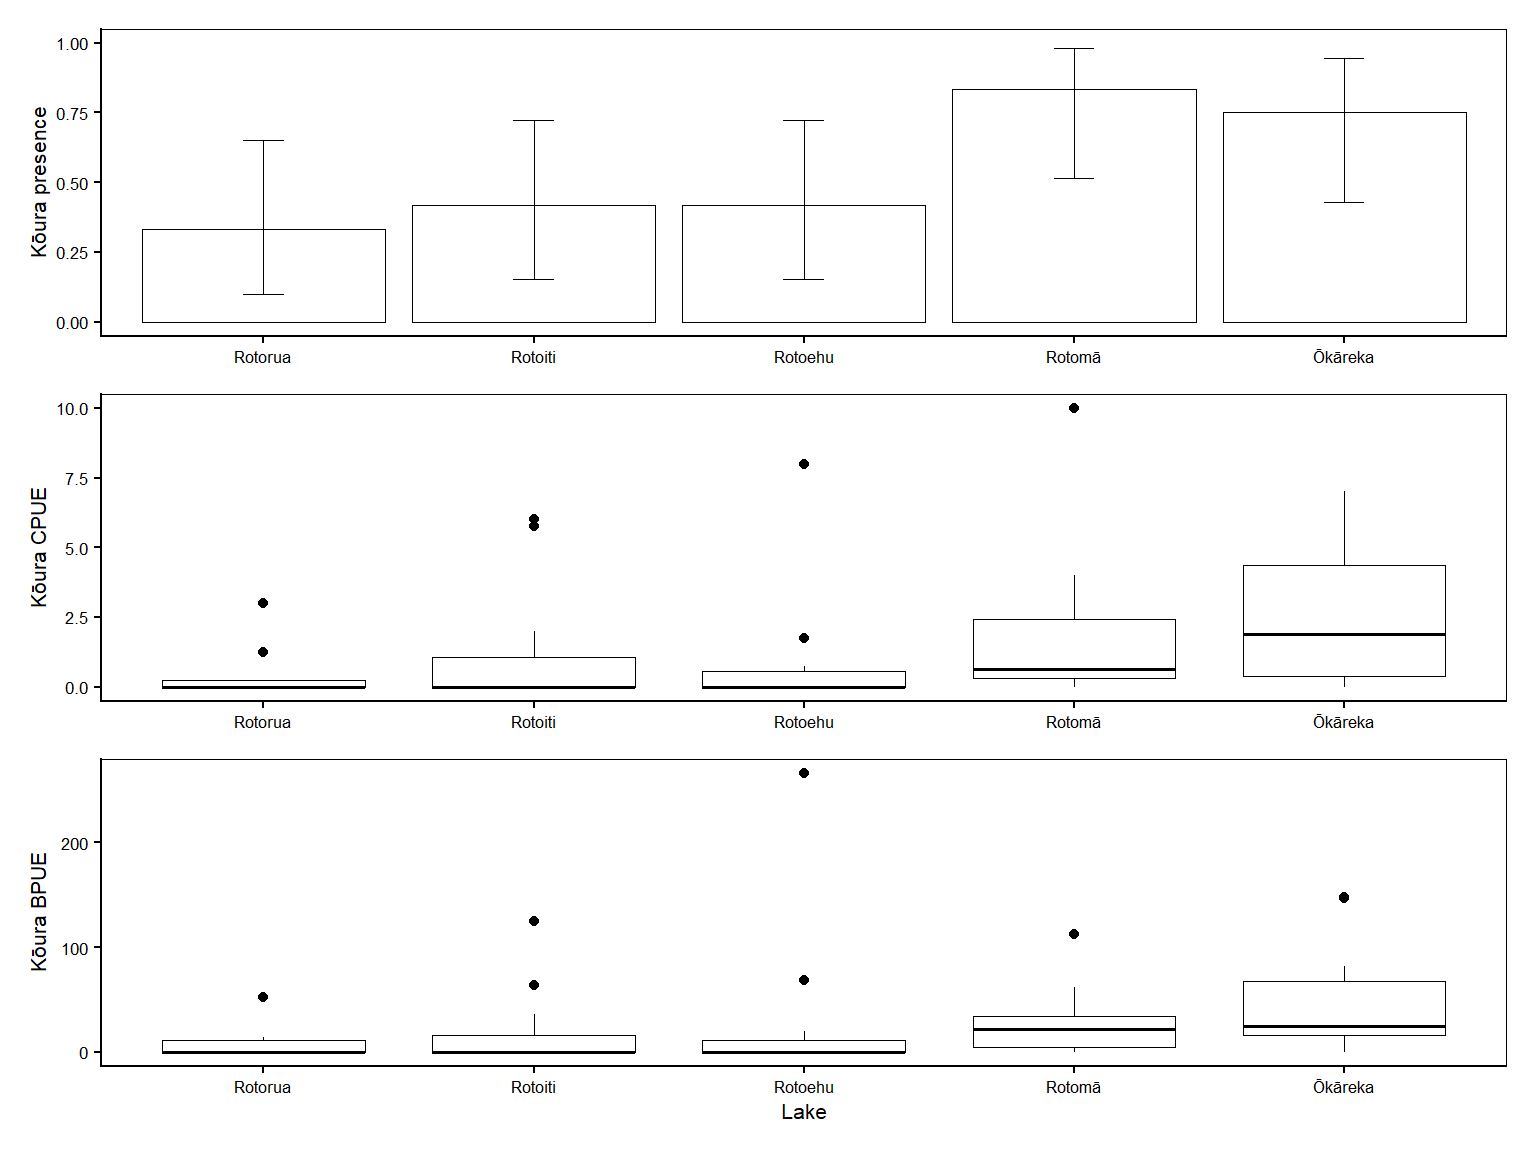

In [ ]:
#| label: fig-koura-by-lake
#| include: true
#| fig-cap: "Fig. 2 Kōura presence, CPUE, and BPUE across lakes. The upper panel shows the proportion of sampled sites with kōura present in each lake, with error bars indicating 95% binomial confidence intervals. The middle and lower panels show the distribution of kōura CPUE and BPUE, respectively, across lakes using boxplots (median, interquartile range, and range)."

plot_koura_stats <- function(data, y_var, y_label,
type = c("continuous", "presence"),
show_x_title = FALSE) {

type <- match.arg(type)
lakes <- levels(data$Lake)
xlab_text <- if (show_x_title) "Lake" else NULL

base_theme <- theme_classic() +
theme(
text = element_text(family = "Arial", size = 8),
axis.title = element_text(face = "plain"),
axis.text = element_text(face = "plain"),
panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.3)
)

if (type == "continuous") {


ggplot(data, aes(Lake, .data[[y_var]])) +
  geom_boxplot(fill = NA, colour = "black", linewidth = 0.3, outlier.size = 1.5) +
  labs(y = y_label, x = xlab_text) +
  base_theme
} else {
presence_summary <- data %>%
  group_by(Lake) %>%
  summarise(
    n = sum(!is.na(.data[[y_var]])),
    k = sum(.data[[y_var]] == 1, na.rm = TRUE),
    Presence_Rate = ifelse(n > 0, k / n, NA_real_),
    .groups = "drop"
  ) %>%
  rowwise() %>%
  mutate(
    CI_low  = ifelse(n > 0, binom.test(k, n)$conf.int[1], NA_real_),
    CI_high = ifelse(n > 0, binom.test(k, n)$conf.int[2], NA_real_)
  ) %>%
  ungroup() %>%
  mutate(Lake = factor(Lake, levels = lakes))

ggplot(presence_summary, aes(x = Lake, y = Presence_Rate)) +
  geom_col(fill = NA, colour = "black", linewidth = 0.3) +
  geom_errorbar(aes(ymin = CI_low, ymax = CI_high), width = 0.15, linewidth = 0.3) +
  scale_y_continuous(limits = c(0, 1)) +
  labs(x = xlab_text, y = y_label) 
}
}

KPRES_plot <- plot_koura_stats(M_C_data, "Presence_Kōura", "Kōura presence", type = "presence", show_x_title = FALSE)
KCPUE_plot <- plot_koura_stats(M_C_data, "Weighted_CPUE_Kōura", "Kōura CPUE", type = "continuous", show_x_title = FALSE)
KBPUE_plot <- plot_koura_stats(M_C_data, "Weighted_BPUE_Kōura", "Kōura BPUE", type = "continuous", show_x_title = TRUE)

Koura_plots <- KPRES_plot / KCPUE_plot / KBPUE_plot

ggsave(file.path(out_dir, "fig-koura-by-lake.png"), Koura_plots, 
       width = 80, height = 120, units = "mm", dpi = 1200)

Koura_plots

# Lake differences glmm

``` r
#| label: tbl-lake-glmm
#| include: true
#| tbl-cap: ""

fit_presence_glmm <- function(data, response, lake_var = "Lake", random_effect = "Habitat_Type") {
  form <- as.formula(paste0(response, " ~ ", lake_var, " + (1|", random_effect, ")"))
  glmmTMB::glmmTMB(form, data = data, family = binomial(link = "logit"))
}

fit_tweedie_glmm <- function(data, response, lake_var = "Lake", random_effect = "Habitat_Type") {
  form <- as.formula(paste0(response, " ~ ", lake_var, " + (1|", random_effect, ")"))
  glmmTMB::glmmTMB(form, data = data, family = glmmTMB::tweedie(link = "log"))
}

m_koura_pres <- fit_presence_glmm(M_C_data, response = "Presence_Kōura",       lake_var = "Lake", random_effect = "Habitat_Type")
m_koura_cpue <- fit_tweedie_glmm( M_C_data, response = "Weighted_CPUE_Kōura",  lake_var = "Lake", random_effect = "Habitat_Type")
m_koura_bpue <- fit_tweedie_glmm( M_C_data, response = "Weighted_BPUE_Kōura",  lake_var = "Lake", random_effect = "Habitat_Type")

# Overall lake effect (LRT via drop1)
pres_lrt <- drop1(m_koura_pres, test = "Chisq")
cpue_lrt <- drop1(m_koura_cpue, test = "Chisq")
bpue_lrt <- drop1(m_koura_bpue, test = "Chisq")

# Pairwise lake comparisons (BH-adjusted)
pres_pairs <- pairs(emmeans(m_koura_pres, ~ Lake, type = "response"), adjust = "BH")
cpue_pairs <- pairs(emmeans(m_koura_cpue, ~ Lake, type = "response"), adjust = "BH")
bpue_pairs <- pairs(emmeans(m_koura_bpue, ~ Lake, type = "response"), adjust = "BH")

pres_lrt
```

    Single term deletions

    Model:
    Presence_Kōura ~ Lake + (1 | Habitat_Type)
           Df    AIC    LRT Pr(>Chi)   
    <none>    75.422                   
    Lake    4 81.180 13.758 0.008109 **
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r
#| label: tbl-lake-glmm
#| include: true
#| tbl-cap: ""

cpue_lrt
```

    Single term deletions

    Model:
    Weighted_CPUE_Kōura ~ Lake + (1 | Habitat_Type)
           Df    AIC    LRT Pr(>Chi)  
    <none>    207.43                  
    Lake    4 212.03 12.601   0.0134 *
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r
#| label: tbl-lake-glmm
#| include: true
#| tbl-cap: ""

bpue_lrt
```

    Single term deletions

    Model:
    Weighted_BPUE_Kōura ~ Lake + (1 | Habitat_Type)
           Df    AIC    LRT Pr(>Chi)  
    <none>    410.66                  
    Lake    4 412.32 9.6552  0.04665 *
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

# GAM modelling

## Helpers

In [ ]:
#| label: GAM-helpers
#| include: false

Modeling_data <- Monitoring_CPUE_data

alpha_sig    <- 0.1
p_cutoff_ml  <- 0.05
vif_thresh   <- 5
INCLUDE_RE   <- TRUE

custom_k <- list(
Slope_5m             = 10,
Riparian_vegetation  = 7,
Overhanging_trees    = 5,
Wood_cover           = 10,
Substrate_index      = 10,
Temperature          = 10,
pH                   = 10,
DO_mgl               = 10,
Emergent_Native      = 9,
Submerged_Non_Native = 9,
Turf_Native          = 6,
Submerged_Native     = 6
)

fish_vars <- c(
"Presence_Goldfish",
"Presence_Eel",
"Presence_Catfish",
"Presence_Common_smelt",
"Presence_Kōaro"
)

vars_common <- c(
"LID",
"Slope_5m","Riparian_vegetation","Overhanging_trees","Wood_cover","Substrate_index",
"Temperature","pH","DO_mgl","DO_percent","Specific_conductivity",
"Emergent_Native","Submerged_Non_Native","Turf_Native","Submerged_Native","Emergent_Non_Native",
fish_vars
)

is_cont <- function(x) is.numeric(x) && dplyr::n_distinct(x, na.rm = TRUE) >= 5

build_smooth_gam <- function(var, data, custom_k = list(), include_re_for_LID = FALSE) {
if (identical(var, "LID") && include_re_for_LID) return("s(LID, bs='re')")
x <- data[[var]]
if (is.numeric(x)) {
nuniq <- dplyr::n_distinct(x, na.rm = TRUE)
if (nuniq < 5) return(var)
k_req <- if (!is.null(custom_k[[var]])) custom_k[[var]] else 10
k_cap <- max(3, min(k_req, nuniq - 1))
return(paste0("s(", var, ", bs='ts', k=", k_cap, ")"))
}
var
}

exclude_if_RE <- function(mod){
if (!length(mod$smooth)) return(NULL)
has_re <- vapply(mod$smooth, function(s) "LID" %in% s$term, logical(1))
if (any(has_re)) "s(LID)" else NULL
}

remove_high_vif_glmBI <- function(
data,
response,
predictors,
threshold    = vif_thresh,
protect_vars = character(0),
verbose      = FALSE
) {
nzv <- caret::nearZeroVar(data[, predictors, drop = FALSE])
if (length(nzv)) predictors <- predictors[-nzv]

rpt <- list(removed = character(), start = predictors)
last_vif <- NULL

repeat {
if (!length(predictors)) stop("All predictors removed during VIF pruning.")


fml <- as.formula(paste(response, "~", paste(predictors, collapse = " + ")))
model <- try(lm(fml, data = data), silent = TRUE)
if (inherits(model, "try-error")) break

vif_data <- performance::check_collinearity(model)
vif_data <- vif_data[!grepl("\\|", vif_data$Term), , drop = FALSE]
last_vif <- vif_data

if (!nrow(vif_data) || all(vif_data$VIF < threshold)) break

ord <- order(vif_data$VIF, decreasing = TRUE)
to_remove <- NA_character_
for (i in ord) {
  cand <- vif_data$Term[i]
  if (!(cand %in% protect_vars)) { to_remove <- cand; break }
}
if (is.na(to_remove)) break

predictors  <- setdiff(predictors, to_remove)
rpt$removed <- c(rpt$removed, to_remove)
}

rpt$final_vif <- last_vif
list(predictors = predictors, report = rpt)
}

remove_high_vif_glmmTMB <- function(
data,
response,
predictors,
threshold    = vif_thresh,
protect_vars = character(0),
verbose      = FALSE
) {
nzv <- caret::nearZeroVar(data[, predictors, drop = FALSE])
if (length(nzv)) predictors <- predictors[-nzv]

rpt <- list(removed = character(), start = predictors)
last_vif <- NULL

repeat {
if (!length(predictors)) stop("All predictors removed during VIF pruning.")


fml <- as.formula(paste(response, "~", paste(predictors, collapse = " + ")))
model <- try(lm(fml, data = data), silent = TRUE)
if (inherits(model, "try-error")) break

vif_data <- performance::check_collinearity(model)
vif_data <- vif_data[!grepl("\\|", vif_data$Term), , drop = FALSE]
last_vif <- vif_data

if (!nrow(vif_data) || all(vif_data$VIF < threshold)) break

ord <- order(vif_data$VIF, decreasing = TRUE)
to_remove <- NA_character_
for (i in ord) {
  cand <- vif_data$Term[i]
  if (!(cand %in% protect_vars)) { to_remove <- cand; break }
}
if (is.na(to_remove)) break

predictors  <- setdiff(predictors, to_remove)
rpt$removed <- c(rpt$removed, to_remove)

}

rpt$final_vif <- last_vif
list(predictors = predictors, report = rpt)
}

as_plot <- function(p) if (inherits(p, c("gg","ggplot","patchwork"))) p else patchwork::plot_spacer()

prepare_block <- function(Modeling_data, response, vars_common, id = "LID"){
vars <- c(response, vars_common)
Modeling_data %>%
dplyr::select(dplyr::all_of(vars)) %>%
dplyr::mutate(
"{id}" := factor(.data[[id]]),
dplyr::across(dplyr::any_of(fish_vars), ~ as.numeric(.x))
)
}

ref_row <- function(data){
dplyr::summarise(
data,
dplyr::across(
dplyr::everything(),
\(x){
if (is.numeric(x)) stats::median(x, na.rm = TRUE)
else if (is.factor(x)) levels(x)[1L]
else if (is.logical(x)) FALSE
else if (is.character(x)) unique(stats::na.omit(x))[1L]
else x[1L]
}
)
)
}

is_binary_numeric <- function(x) is.numeric(x) && dplyr::n_distinct(x, na.rm = TRUE) == 2

get_term_p <- function(m, var, kind = c("any","param","smooth")){
kind <- match.arg(kind)
sm <- summary(m)

if (kind %in% c("any","param")) {
if (!is.null(sm$p.table) && nrow(sm$p.table) > 0) {
pcol <- intersect(colnames(sm$p.table), c("Pr(>|t|)","Pr(>|z|)"))[1]
if (!is.na(pcol) && var %in% rownames(sm$p.table)) {
return(as.numeric(sm$p.table[var, pcol]))
}
}
}

if (kind %in% c("any","smooth")) {
if (!is.null(sm$s.table) && nrow(sm$s.table) > 0) {
sname <- paste0("s(", var, ")")
if (sname %in% rownames(sm$s.table)) {
return(as.numeric(sm$s.table[sname, "p-value"]))
}
}
}

NA_real_
}

plot_binary_single_component <- function(model, var, data,
family = c("binomial","gamma"),
S = 2000, alpha = 0.05,
exclude_RE = TRUE,
hold_binaries = c("mean","zero","one"),
id = "LID",
fish_covars = c("Presence_Goldfish","Presence_Eel","Presence_Catfish","Presence_Common_smelt"),
seed = 1) {
family <- match.arg(family)
hold_binaries <- match.arg(hold_binaries)

tl <- attr(terms(model), "term.labels")
has_term <- any(tl == var) || any(grepl(paste0("^s\\(", var, "(,|\\))"), tl))
if (!has_term) return(ggplot() + theme_void())

num_means <- data %>%
dplyr::summarise(across(where(is.numeric), ~ mean(.x, na.rm = TRUE)))
base <- as.list(num_means)
if (id %in% names(data) && is.factor(data[[id]]))
base[[id]] <- factor(levels(data[[id]])[1], levels = levels(data[[id]]))

others <- setdiff(intersect(fish_covars, names(data)), var)
set_bin <- function(x){
if (hold_binaries == "mean") round(mean(data[[x]], na.rm = TRUE))
else if (hold_binaries == "zero") 0L else 1L
}
for (x in others) base[[x]] <- set_bin(x)

mk_nd <- function(level){
nd <- as.data.frame(base, stringsAsFactors = FALSE)
nd[[var]] <- as.integer(level)
if (id %in% names(data) && is.factor(data[[id]])) {
nd <- do.call(
rbind,
lapply(levels(data[[id]]), function(lv){
r <- nd
r[[id]] <- factor(lv, levels = levels(data[[id]]))
r
})
)
}
if (!is.null(model$model)) {
common <- intersect(names(nd), names(model$model))
for (nm in common) if (is.factor(model$model[[nm]]))
nd[[nm]] <- factor(nd[[nm]], levels = levels(model$model[[nm]]))
}
nd
}
nd0 <- mk_nd(0L)
nd1 <- mk_nd(1L)
nd  <- dplyr::bind_rows(
dplyr::mutate(nd0, .level = 0L),
dplyr::mutate(nd1, .level = 1L)
)

excl <- if (exclude_RE) exclude_if_RE(model) else NULL
lp <- predict(model, newdata = nd, type = "link", se.fit = TRUE, exclude = excl)

set.seed(seed)
n <- nrow(nd)
Z <- matrix(
rnorm(n * S, lp$fit, pmax(lp$se.fit, .Machine$double.eps)),
nrow = n, ncol = S
)

if (family == "binomial") {
Y <- plogis(Z); ylab <- "Presence probability"
} else {
Y <- exp(Z);    ylab <- "Mean given presence (μ)"
}

sim_by_level <- function(level_flag){
sims <- Y[nd$.level == level_flag, , drop = FALSE]
colMeans(sims)
}
sim0 <- sim_by_level(0L)
sim1 <- sim_by_level(1L)

qlo <- alpha/2
qhi <- 1 - alpha/2
df <- data.frame(
level = factor(c(0,1), levels = c(0,1), labels = c("Absent","Present")),
mean  = c(mean(sim0), mean(sim1)),
lwr   = c(quantile(sim0, qlo), quantile(sim1, qlo)),
upr   = c(quantile(sim0, qhi), quantile(sim1, qhi))
)

ggplot(df, aes(x = level, y = mean)) +
geom_col(width = 0.6) +
geom_errorbar(aes(ymin = lwr, ymax = upr), width = 0.2) +
labs(x = var, y = ylab)
}

plot_linear_single_component <- function(model, var, data,
family = c("binomial","gamma"),
n = 100, alpha = 0.05,
exclude_RE = TRUE) {
family <- match.arg(family)

num_means <- data %>%
dplyr::summarise(across(where(is.numeric), ~ mean(.x, na.rm = TRUE)))
base <- as.list(num_means)

if (!is.null(model$model)) {
for (nm in names(model$model)) {
if (is.factor(model$model[[nm]])) {
base[[nm]] <- factor(
levels(model$model[[nm]])[1],
levels = levels(model$model[[nm]])
)
}
}
}

x  <- data[[var]]
xr <- range(x, na.rm = TRUE)
grid <- seq(xr[1], xr[2], length.out = n)

nd <- as.data.frame(base)
nd <- nd[rep(1, n), , drop = FALSE]
nd[[var]] <- grid

excl <- if (exclude_RE) exclude_if_RE(model) else NULL
pr <- predict(model, newdata = nd, type = "link", se.fit = TRUE, exclude = excl)

if (family == "binomial") {
fit <- plogis(pr$fit)
lwr <- plogis(pr$fit - qnorm(1 - alpha/2) * pr$se.fit)
upr <- plogis(pr$fit + qnorm(1 - alpha/2) * pr$se.fit)
ylab <- "Response (probability)"
} else {
fit <- exp(pr$fit)
lwr <- exp(pr$fit - qnorm(1 - alpha/2) * pr$se.fit)
upr <- exp(pr$fit + qnorm(1 - alpha/2) * pr$se.fit)
ylab <- "Response (μ)"
}

df <- data.frame(x = grid, fit = fit, lwr = lwr, upr = upr)
ggplot(df, aes(x, fit)) +
geom_ribbon(aes(ymin = lwr, ymax = upr), alpha = 0.2) +
geom_line() +
labs(x = var, y = ylab)
}

parametric_panel <- function(model, data, alpha = 0.1, exclude = character(0),
family = c("binomial","gamma"),
fish_covars = c("Presence_Goldfish","Presence_Eel","Presence_Catfish","Presence_Common_smelt"),
hold_binaries = "mean") {
family <- match.arg(family)

sm <- summary(model)
if (is.null(sm$p.table) || nrow(sm$p.table) == 0) return(ggplot() + theme_void())

pcol <- intersect(colnames(sm$p.table), c("Pr(>|t|)","Pr(>|z|)"))[1]
if (is.na(pcol)) return(ggplot() + theme_void())

par_names <- setdiff(rownames(sm$p.table), "(Intercept)")

smooth_rows <- if (!is.null(sm$s.table)) rownames(sm$s.table) else character(0)
smooth_vars <- sub("^s\\(([^,\\)]+).*$", "\\1", smooth_rows)
par_names <- setdiff(par_names, union(exclude, smooth_vars))

par_sig <- par_names[sm$p.table[par_names, pcol, drop = TRUE] <= alpha]
if (!length(par_sig)) return(ggplot() + theme_void())

plots <- lapply(par_sig, function(v) {
x <- data[[v]]
if (is.null(x)) return(ggplot() + theme_void())

is_bin_num <- is.numeric(x) && dplyr::n_distinct(x, na.rm = TRUE) <= 2
is_bin_fac <- is.factor(x)  && nlevels(x) == 2

if (is_bin_num || is_bin_fac) {
plot_binary_single_component(
model, v, data,
family        = family,
hold_binaries = hold_binaries,
fish_covars   = fish_covars
)
} else {
plot_linear_single_component(model, v, data, family = family)
}
})

if (!length(plots)) return(ggplot() + theme_void())
patchwork::wrap_plots(plots, ncol = 1)
}

## Occupancy model (presence/absence)

### model run

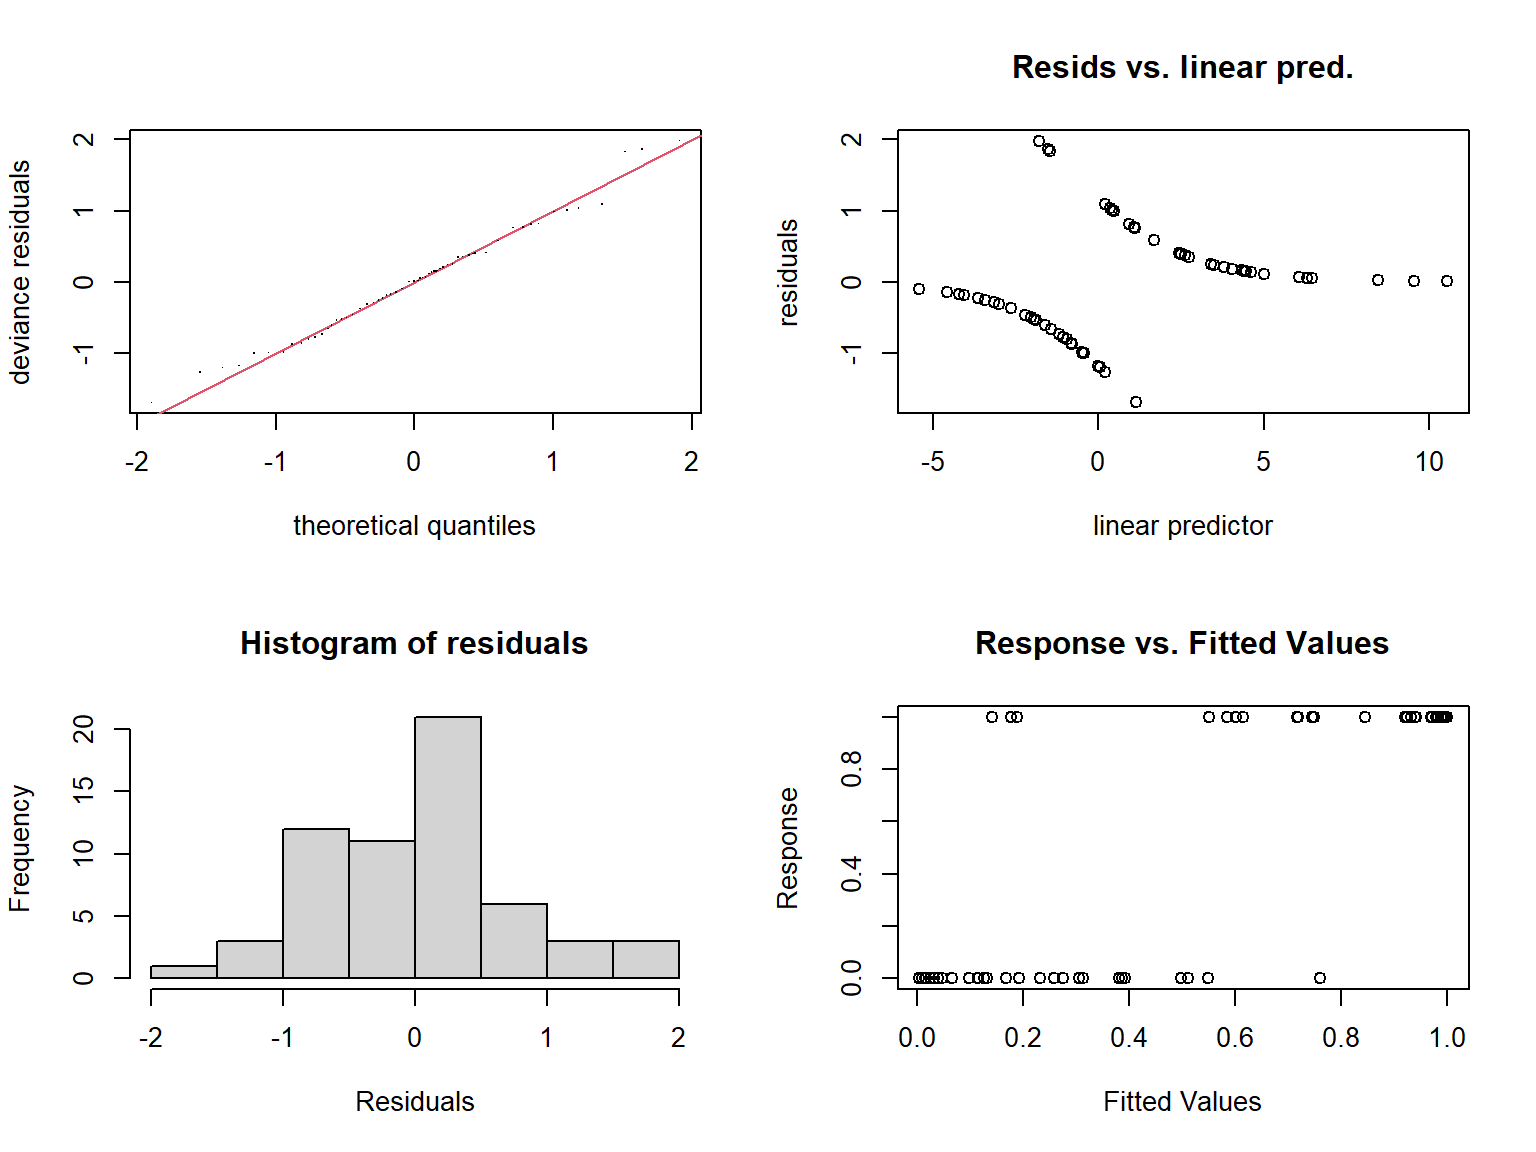


Method: REML   Optimizer: outer newton
full convergence after 7 iterations.
Gradient range [-1.302727e-06,2.078511e-08]
(score 23.01023 & scale 1).
Hessian positive definite, eigenvalue range [1.302724e-06,0.5351484].
Model rank =  41 / 41 

Basis dimension (k) checking results. Low p-value (k-index<1) may
indicate that k is too low, especially if edf is close to k'.

                               k'      edf k-index p-value
s(Riparian_vegetation)   6.00e+00 8.49e-01    1.20    0.91
s(Substrate_index)       9.00e+00 9.80e-01    0.99    0.40
s(Temperature)           9.00e+00 1.16e+00    1.00    0.40
s(Specific_conductivity) 9.00e+00 9.37e-01    0.95    0.34
s(LID)                   5.00e+00 5.93e-06      NA      NA

$worst
                                 para s(Riparian_vegetation) s(Substrate_index)
para                     1.000000e+00           1.047356e-25       4.795095e-20
s(Riparian_vegetation)   1.039998e-25           1.000000e+00       3.134858e-01
s(Substrate_index)       4.795079e-20           3.134858e-01       1.000000e+00
s(Temperature)           1.389459e-16           3.832410e-01       5.995062e-01
s(Specific_conductivity) 2.179319e-23           4.345519e-01       5.932841e-01
s(LID)                   1.000000e+00           1.800786e-01       3.202651e-01
                         s(Temperature) s(Specific_conductivity)    s(LID)
para                       1.389459e-16             2.213869e-23 1.0000000
s(Riparian_vegetation)     3.832410e-01             4.345519e-01 0.1800786
s(Substrate_index)         5.995062e-01             5.932841e-01 0.3202651
s(Temperature)             1.000000e+00             9.950952e-01 0.9451023
s(Specific_conductivity)   9.950952e-01             1.0000

In [ ]:
#| label: occupancy-model
#| include: true

PData <- prepare_block(Modeling_data, "Presence_Kōura", vars_common)

id <- "LID"
pred_fixed_occ <- setdiff(names(PData), c("Presence_Kōura", id))

vif_occ <- remove_high_vif_glmBI(
PData,
"Presence_Kōura",
pred_fixed_occ,
threshold    = vif_thresh,
protect_vars = character(0)
)
kept_fixed_occ <- vif_occ$predictors

vars_step_occ <- c(kept_fixed_occ, if (INCLUDE_RE) id)
rhs_full_occ <- paste(
vapply(
vars_step_occ,
function(v) build_smooth_gam(v, PData, custom_k, include_re_for_LID = INCLUDE_RE),
character(1)
),
collapse = " + "
)
form_full_occ <- as.formula(paste("Presence_Kōura ~", rhs_full_occ))

full_ml_occ <- mgcv::gam(
form_full_occ,
data   = PData,
family = binomial(link = "logit"),
method = "ML",
select = TRUE
)

remaining_occ <- vars_step_occ
protected_step_vars <- if (INCLUDE_RE) id else character(0)

repeat {
rhs_now <- paste(
vapply(
remaining_occ,
function(v) build_smooth_gam(v, PData, custom_k, include_re_for_LID = INCLUDE_RE),
character(1)
),
collapse = " + "
)
m_now <- mgcv::gam(
as.formula(paste("Presence_Kōura ~", rhs_now)),
data   = PData,
family = binomial(link = "logit"),
method = "ML",
select = TRUE
)
sm <- summary(m_now)

ps <- c()
if (!is.null(sm$p.table) && nrow(sm$p.table) > 0) {
pcol <- intersect(colnames(sm$p.table), c("Pr(>|t|)","Pr(>|z|)"))[1]
pvec <- sm$p.table[, pcol]
ps <- c(ps, pvec[names(pvec) != "(Intercept)"])
}
if (!is.null(sm$s.table) && nrow(sm$s.table) > 0) {
pvec <- sm$s.table[, "p-value"]
names(pvec) <- rownames(sm$s.table)
ps <- c(ps, pvec)
}
drop_candidates <- ps[ps > p_cutoff_ml]
if (!length(drop_candidates)) { red_ml_occ <- m_now; break }

ordered <- names(sort(drop_candidates, decreasing = TRUE))
ordered_vars <- vapply(
ordered,
function(x) if (grepl("^s\\(", x)) sub("^s\\(([^,]+).*\\)$", "\\1", x) else x,
character(1)
)

ordered_vars <- setdiff(ordered_vars, protected_step_vars)
if (!length(ordered_vars)) { red_ml_occ <- m_now; break }

remove_v <- ordered_vars[1]
remaining_occ <- setdiff(remaining_occ, remove_v)
if (!length(remaining_occ)) { red_ml_occ <- m_now; break }
}

final_occ <- mgcv::gam(
formula(red_ml_occ),
data   = PData,
family = binomial(link = "logit"),
method = "REML",
select = TRUE
)

gam.check(final_occ)

### occupancy model figure

Setting levels: control = FALSE, case = TRUE

Setting direction: controls < cases

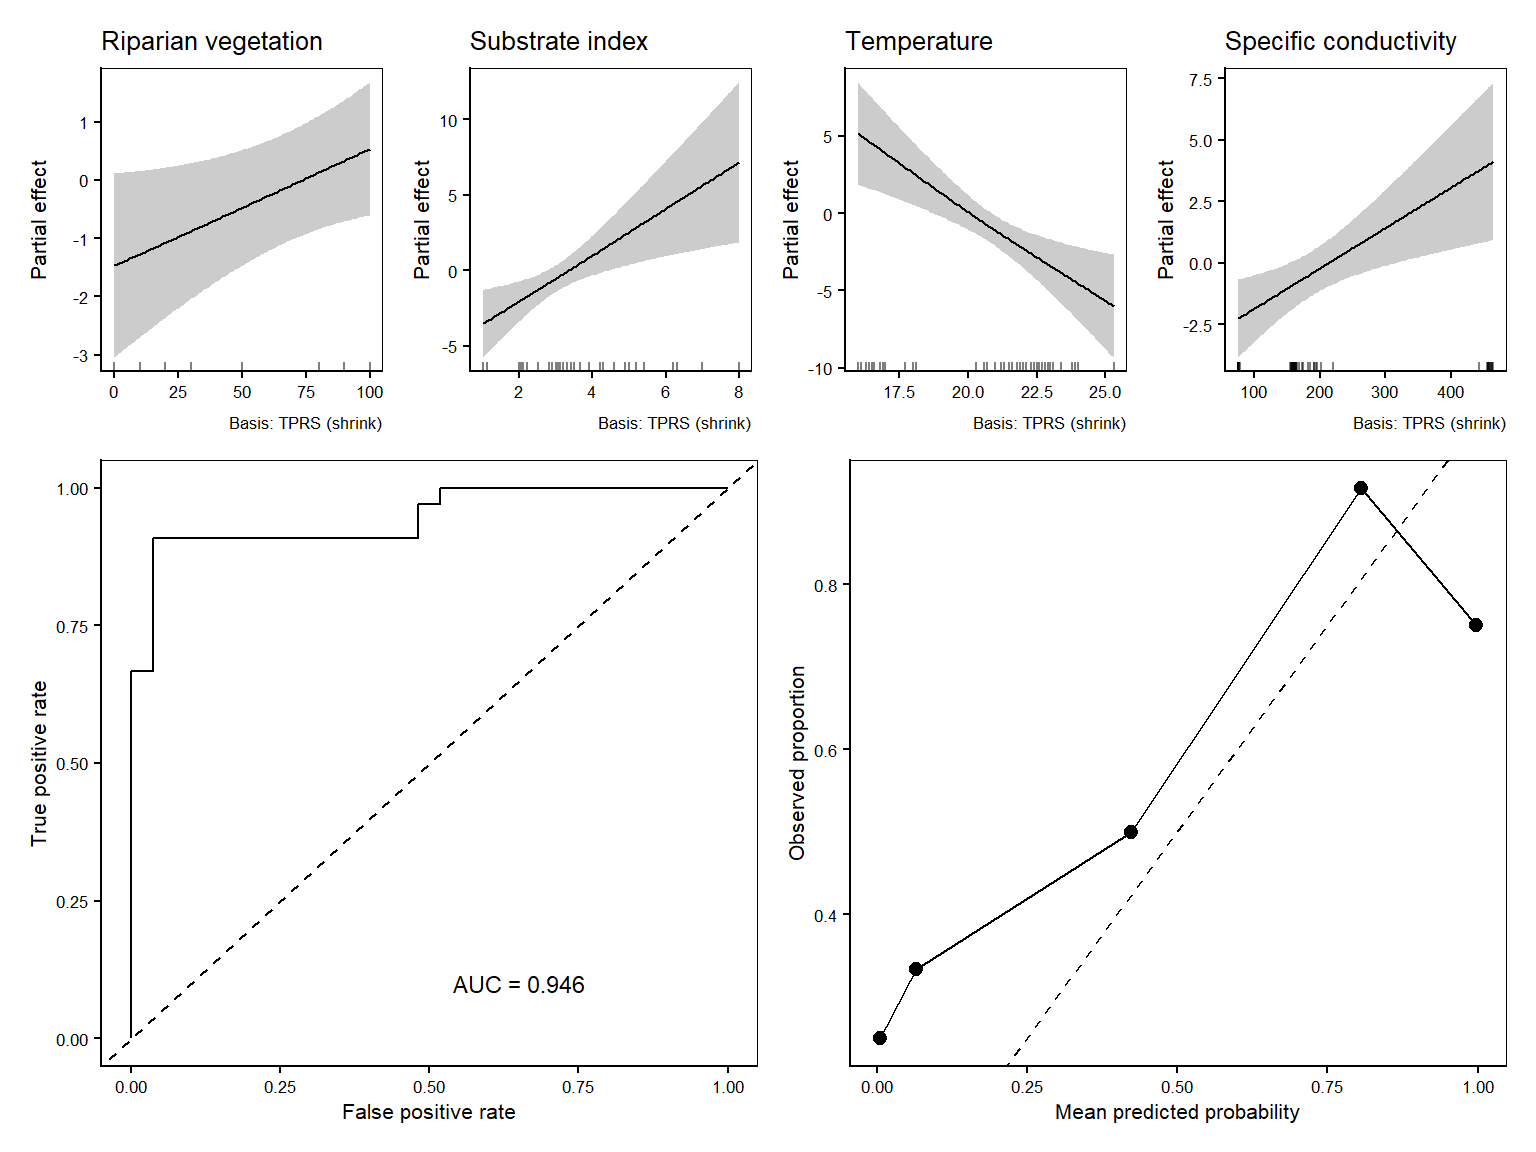

In [ ]:
#| label: fig-occupancy-model
#| include: true
#| fig-cap: "Kōura occupancy GAMM results and model performance. a) Estimated smooth terms for riparian vegetation, substrate index, surface water temperature, and specific conductivity, shown as partial effects with 95% confidence intervals. b) Receiver operating characteristic (ROC) curve illustrating model discrimination, with the area under the curve (AUC) reported. c) Calibration plot based on five equal-frequency bins, comparing mean predicted occupancy probabilities with observed proportions of occupied sites; the dashed 1:1 line indicates perfect calibration."

# Smooth plots: keep draw() outputs as-is (they may be ggplot OR patchwork)
sm <- gratia::smooth_estimates(final_occ)
smooth_names <- unique(sm$.smooth)
smooth_4_names <- smooth_names[1:min(4, length(smooth_names))]

plots_4 <- lapply(smooth_4_names, function(s) {
  p <- gratia::draw(final_occ, select = s, scales = "fixed", se = FALSE) +
    labs(title = clean_smooth_title(s), x = NULL, y = "Partial effect") +
    base_theme_bw
  p
})

# Combine without forcing wrap_dims assumptions about panel counts
final_p_occ_smooths <- patchwork::wrap_plots(plots_4, ncol = length(plots_4))

# Parametric panel (unchanged call)
p_occ_param <- parametric_panel(
  final_occ,
  PData,
  alpha       = 0.1,
  exclude     = c("LID"),
  family      = "binomial",
  fish_covars = fish_vars
) + base_theme_bw

# ROC on fitted model predictions
pred_pres <- predict(final_occ, type = "response", exclude = exclude_if_RE(final_occ))
obs_pres  <- PData$Presence_Kōura == 1
roc_obj   <- pROC::roc(obs_pres, pred_pres)

## CPUE hurdle model

### model run

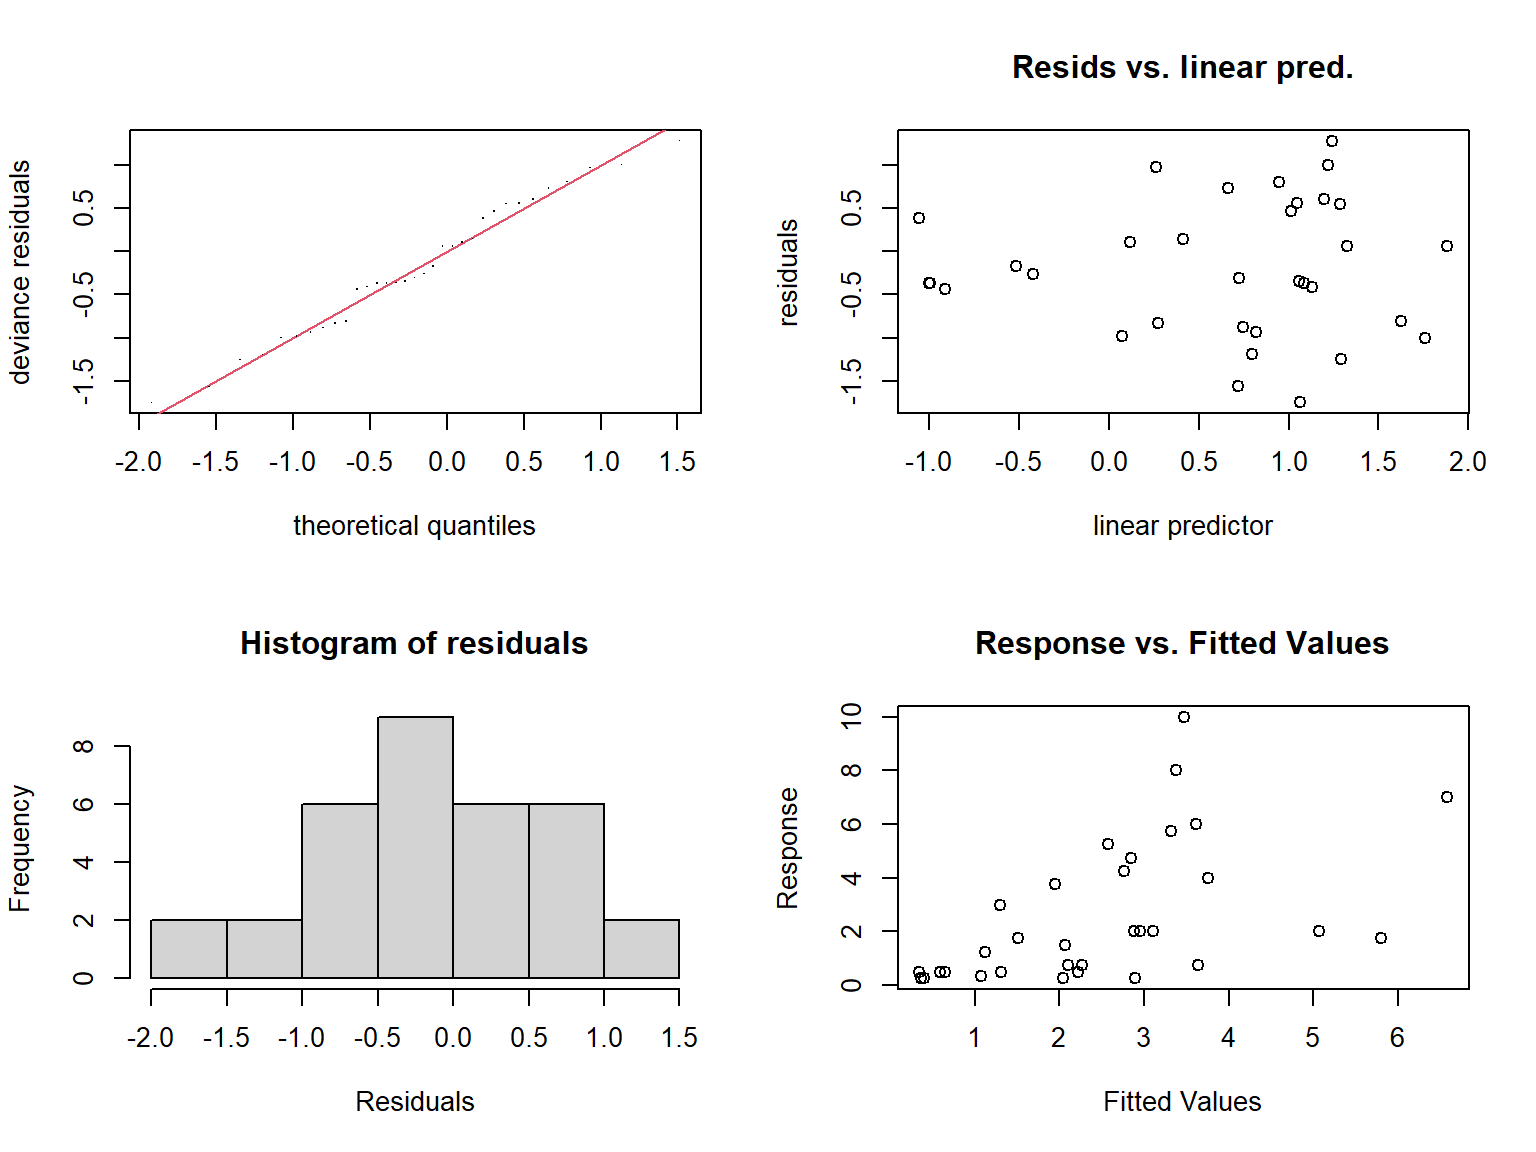


Method: REML   Optimizer: outer newton
full convergence after 12 iterations.
Gradient range [-2.08322e-05,6.435482e-05]
(score 58.0551 & scale 0.6129728).
Hessian positive definite, eigenvalue range [2.08349e-05,18.90857].
Model rank =  28 / 28 

Basis dimension (k) checking results. Low p-value (k-index<1) may
indicate that k is too low, especially if edf is close to k'.

                         k'      edf k-index p-value  
s(Temperature)     9.000000 0.823380    0.73   0.045 *
s(pH)              9.000000 1.020023    1.05   0.695  
s(Emergent_Native) 3.000000 0.980418    0.98   0.500  
s(LID)             5.000000 0.000184      NA      NA  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

$worst
                           para s(Temperature)        s(pH) s(Emergent_Native)
para               1.000000e+00   1.400984e-17 4.262655e-21       3.898474e-28
s(Temperature)     1.400980e-17   1.000000e+00 9.786073e-01       3.499890e-01
s(pH)              4.262769e-21   9.786073e-01 1.000000e+00       6.595492e-01
s(Emergent_Native) 3.743399e-28   3.499890e-01 6.595492e-01       1.000000e+00
s(LID)             1.000000e+00   9.368544e-01 9.509125e-01       2.576175e-01
                      s(LID)
para               1.0000000
s(Temperature)     0.9368544
s(pH)              0.9509125
s(Emergent_Native) 0.2576175
s(LID)             1.0000000

$observed
                           para s(Temperature)        s(pH) s(Emergent_Native)
para               1.000000e+00   4.529500e-27 3.388150e-30       4.565615e-34
s(Temperature)     1.400980e-17   1.000000e+00 5.568819e-01       1.857481e-01
s(pH)              4.262769e-21   4.682138e-01 1.000000e+00       2.957955e-01
s(Emergent_Native)

In [ ]:
#| label: cpue-hurdle
#| include: true

CData <- prepare_block(Modeling_data, "Weighted_CPUE_Kōura", vars_common) %>%
dplyr::mutate(CPUE_pos = as.integer(Weighted_CPUE_Kōura > 0))

id <- "LID"

pred_fixed_cpue_pres <- setdiff(
names(CData),
c("CPUE_pos", id, "Weighted_CPUE_Kōura", "Weighted_CPUE_Koura", "CPUE")
)



Cpos <- dplyr::filter(CData, CPUE_pos == 1L)

pred_fixed_cpue_pos <- setdiff(names(Cpos), c("Weighted_CPUE_Kōura", id))

vif_cpue_pos <- remove_high_vif_glmmTMB(
Cpos,
"Weighted_CPUE_Kōura",
pred_fixed_cpue_pos,
threshold    = vif_thresh,
protect_vars = character(0)
)
kept_fixed_cpue_pos <- vif_cpue_pos$predictors

vars_step_cpue_pos <- c(kept_fixed_cpue_pos, if (INCLUDE_RE) id)

rhs_cpue_pos <- paste(
vapply(
vars_step_cpue_pos,
function(v) build_smooth_gam(v, Cpos, custom_k, include_re_for_LID = INCLUDE_RE),
character(1)
),
collapse = " + "
)

full_ml_cpue_pos <- mgcv::gam(
as.formula(paste("Weighted_CPUE_Kōura ~", rhs_cpue_pos)),
data   = Cpos,
family = Gamma(link = "log"),
method = "ML",
select = TRUE
)

remaining_cpue_pos <- vars_step_cpue_pos
protected_step_vars_pos <- if (INCLUDE_RE) id else character(0)

repeat {
rhs_now <- paste(
vapply(
remaining_cpue_pos,
function(v) build_smooth_gam(v, Cpos, custom_k, include_re_for_LID = INCLUDE_RE),
character(1)
),
collapse = " + "
)
m_now <- mgcv::gam(
as.formula(paste("Weighted_CPUE_Kōura ~", rhs_now)),
data   = Cpos,
family = Gamma(link = "log"),
method = "ML",
select = TRUE
)
sm <- summary(m_now)

ps <- c()
if (!is.null(sm$p.table) && nrow(sm$p.table) > 0) {
pcol <- intersect(colnames(sm$p.table), c("Pr(>|t|)", "Pr(>|z|)"))[1]
pvec <- sm$p.table[, pcol]
ps   <- c(ps, pvec[names(pvec) != "(Intercept)"])
}
if (!is.null(sm$s.table) && nrow(sm$s.table) > 0) {
pvec <- sm$s.table[, "p-value"]
names(pvec) <- rownames(sm$s.table)
ps   <- c(ps, pvec)
}
drop_candidates <- ps[ps > p_cutoff_ml]
if (!length(drop_candidates)) { red_ml_cpue_pos <- m_now; break }

ordered <- names(sort(drop_candidates, decreasing = TRUE))
ordered_vars <- vapply(
ordered,
function(x) if (grepl("^s\\(", x)) sub("^s\\(([^,]+).*\\)$", "\\1", x) else x,
character(1)
)

ordered_vars <- setdiff(ordered_vars, protected_step_vars_pos)
if (!length(ordered_vars)) { red_ml_cpue_pos <- m_now; break }

remove_v <- ordered_vars[1]
remaining_cpue_pos <- setdiff(remaining_cpue_pos, remove_v)
if (!length(remaining_cpue_pos)) { red_ml_cpue_pos <- m_now; break }
}

final_cpue_pos <- mgcv::gam(
formula(red_ml_cpue_pos),
data   = Cpos,
family = Gamma(link = "log"),
method = "REML",
select = TRUE
)


gam.check(final_cpue_pos) 

### fig-cpue-hurdle

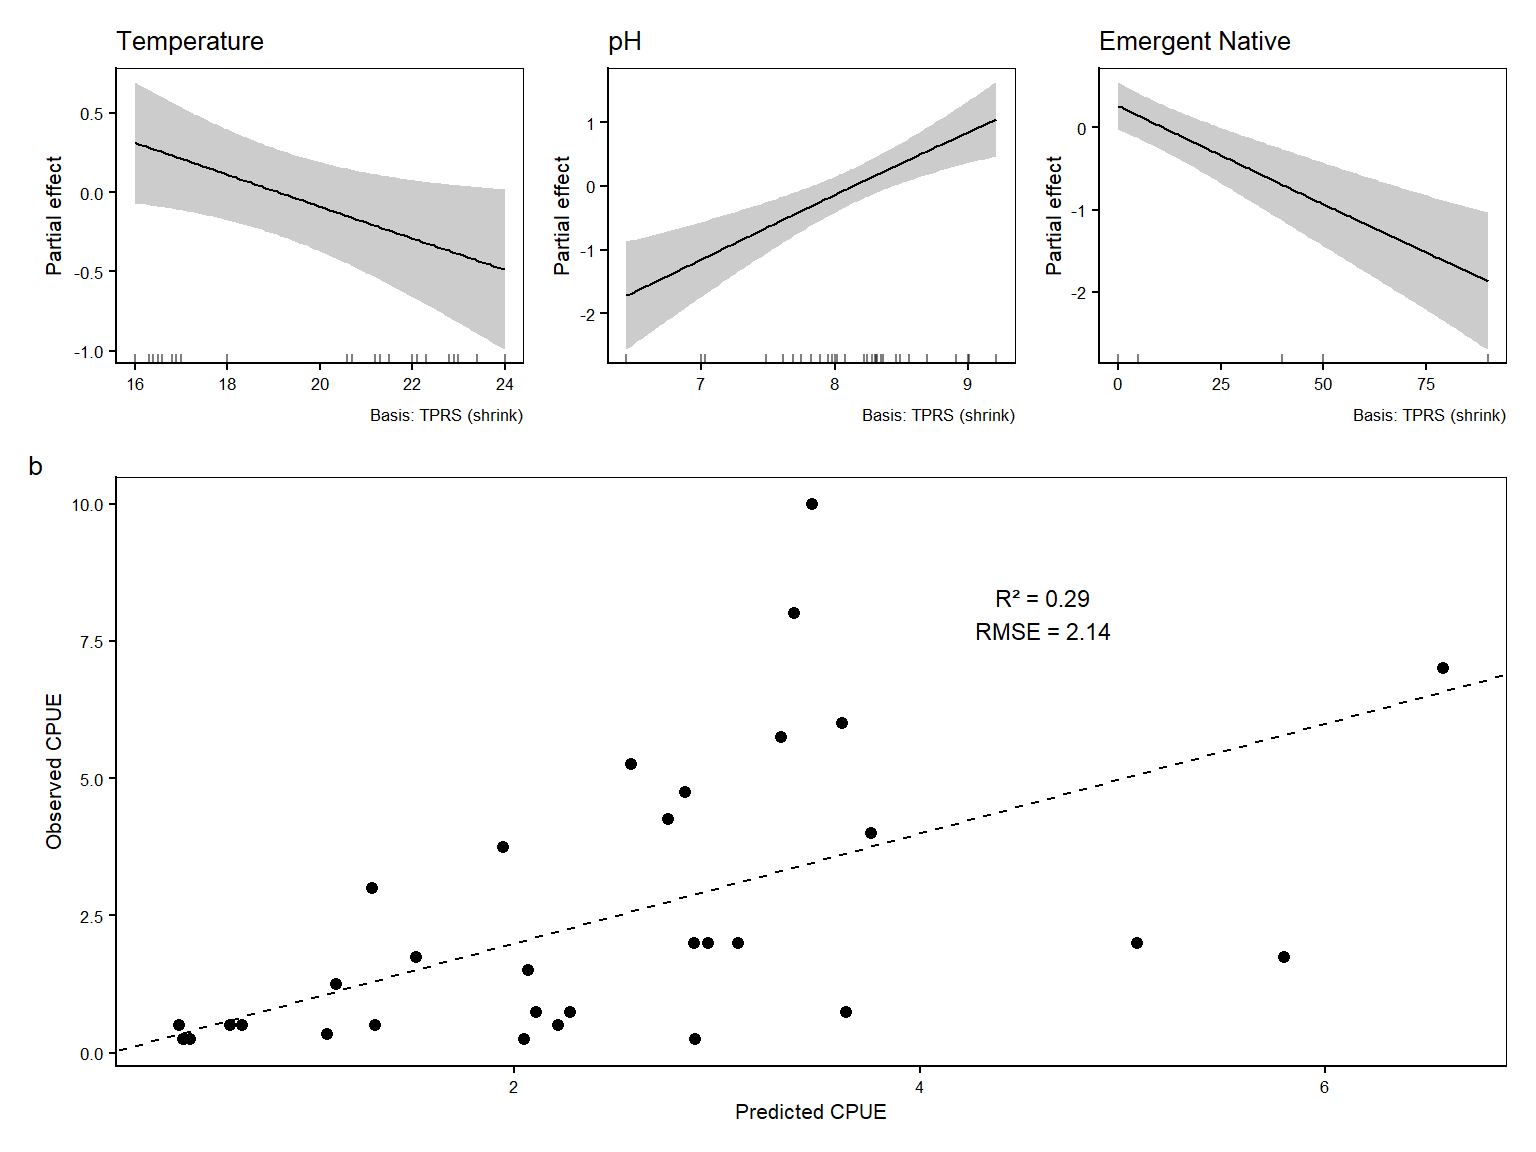

In [ ]:
#| label: fig-cpue-hurdle
#| include: true
#| fig-cap: "Kōura CPUE GAMM results and model performance. a) Estimated smooth terms for surface water temperature, pH, and emergent native vegetation, shown with partial effects and 95% confidence intervals. See Fig. S2 for raw data underlying modelled relationships. b) Predicted versus observed CPUE from the positive (Gamma) component of the hurdle model, with predictions excluding the random lake effect. The dashed 1:1 line indicates perfect agreement; annotated values report R² and RMSE to summarise model fit."

# make plot
sm_cpue <- smooth_estimates(final_cpue_pos)
cpue_smooth_names <- setdiff(unique(sm_cpue$.smooth), "s(LID)")
cpue_smooth_plots <- lapply(cpue_smooth_names, function(s) {
gratia::draw(final_cpue_pos, select = s, scales = "fixed", se = FALSE) +
labs(title = clean_smooth_title(s), x = NULL, y = "Partial effect") +
base_theme_bw
})

p_cpue_pos_smooths <- patchwork::wrap_plots(cpue_smooth_plots, ncol = length(cpue_smooth_plots)) +
patchwork::plot_annotation(tag_levels = "a")

pred_pos <- predict(final_cpue_pos, type = "response")
obs_pos  <- final_cpue_pos$y
R2   <- cor(pred_pos, obs_pos, use = "complete.obs")^2
RMSE <- sqrt(mean((pred_pos - obs_pos)^2, na.rm = TRUE))

df_scat <- data.frame(Predicted = pred_pos, Observed = obs_pos)

p_cpue_pos_scatter <- ggplot(df_scat, aes(Predicted, Observed)) +
geom_point(size = 1.8, colour = "black") +
geom_abline(slope = 1, intercept = 0, linetype = "dashed", colour = "black", linewidth = 0.4) +
annotate(
"text",
x = max(df_scat$Predicted, na.rm = TRUE) * 0.7,
y = max(df_scat$Observed,  na.rm = TRUE) * 0.8,
label = paste0("R\u00B2 = ", round(R2, 2), "\nRMSE = ", round(RMSE, 2)),
size = 3
) +
labs(x = "Predicted CPUE", y = "Observed CPUE", tag = "b") +
base_theme_bw

CPUE_panel_positives <- (p_cpue_pos_smooths / p_cpue_pos_scatter) +
patchwork::plot_layout(heights = c(1, 2))

ggsave(filename = file.path(out_dir, "fig-cpue-hurdle.png"),plot = CPUE_panel_positives,width = 130, height = 120, units = "mm", dpi = 1200)

CPUE_panel_positives

## BPUE hurdle model

### model run

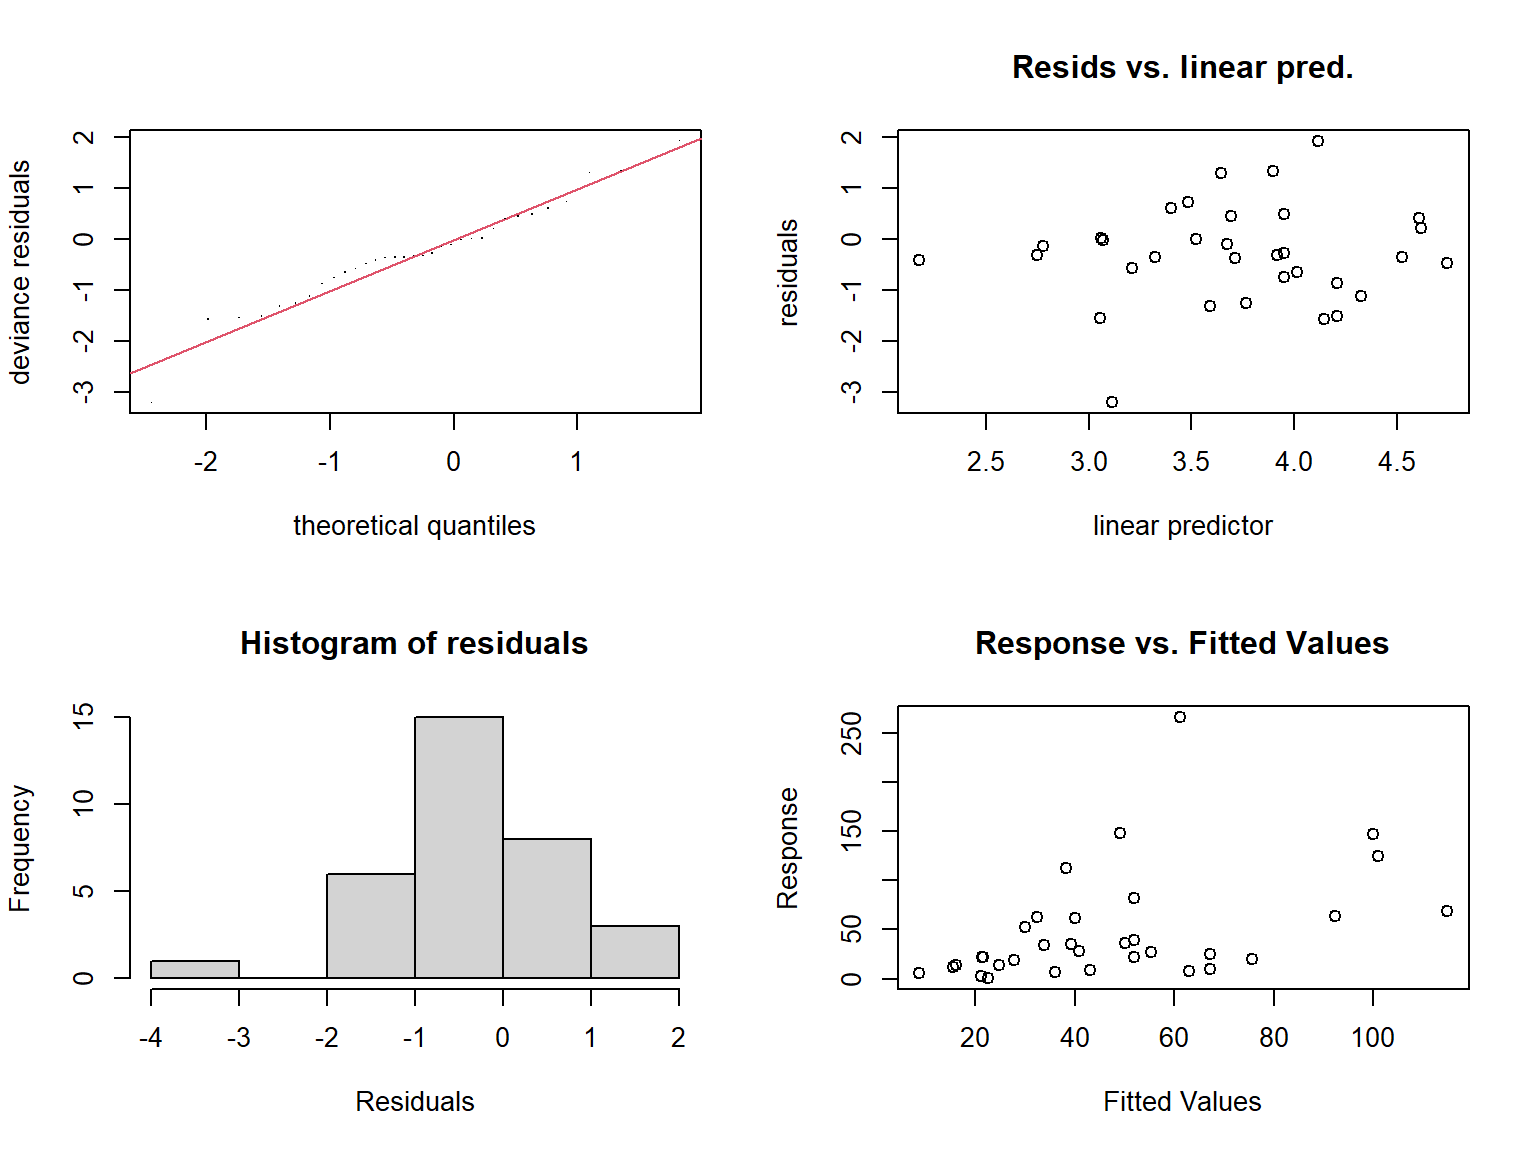


Method: REML   Optimizer: outer newton
full convergence after 6 iterations.
Gradient range [-3.720595e-06,7.313389e-06]
(score 158.6148 & scale 0.9394357).
Hessian positive definite, eigenvalue range [3.720601e-06,20.65057].
Model rank =  18 / 18 

Basis dimension (k) checking results. Low p-value (k-index<1) may
indicate that k is too low, especially if edf is close to k'.

                         k'      edf k-index p-value
s(pH)              9.00e+00 9.67e-01    1.24    0.98
s(Emergent_Native) 3.00e+00 7.61e-01    0.99    0.60
s(LID)             5.00e+00 2.35e-05      NA      NA

$worst
                           para        s(pH) s(Emergent_Native)    s(LID)
para               1.000000e+00 4.262655e-21       3.898474e-28 1.0000000
s(pH)              4.262706e-21 1.000000e+00       6.595492e-01 0.9509125
s(Emergent_Native) 3.228607e-28 6.595492e-01       1.000000e+00 0.2576175
s(LID)             1.000000e+00 9.509125e-01       2.576175e-01 1.0000000

$observed
                           para        s(pH) s(Emergent_Native)     s(LID)
para               1.000000e+00 3.314145e-30       1.369791e-33 0.01297495
s(pH)              4.262706e-21 1.000000e+00       2.955720e-01 0.39976445
s(Emergent_Native) 3.228607e-28 4.577087e-02       1.000000e+00 0.08782984
s(LID)             1.000000e+00 5.964829e-01       1.464507e-01 1.00000000

$estimate
                           para        s(pH) s(Emergent_Native)     s(LID)
para               1.000000e+00 3.747157e-23       3.061818e-31 0.22681359
s(pH)              4.262706e-21 1.000000e+00       2.960202e-01 0.49372556
s

In [ ]:
#| label: bpue-hurdle
#| inluce: true

BData <- prepare_block(Modeling_data, "Weighted_BPUE_Kōura", vars_common) %>%
dplyr::mutate(BPUE_pos = as.integer(Weighted_BPUE_Kōura > 0))

id <- "LID"

pred_fixed_BPUE_pres <- setdiff(names(BData),c("BPUE_pos", id, "Weighted_BPUE_Kōura", "Weighted_BPUE_Koura", "Weighted_BPUE"))

Bpos <- dplyr::filter(BData, BPUE_pos == 1L)

pred_fixed_BPUE_pos <- setdiff(names(Bpos), c("Weighted_BPUE_Kōura", id))

vif_BPUE_pos <- remove_high_vif_glmmTMB(Bpos,"Weighted_BPUE_Kōura",pred_fixed_BPUE_pos,threshold = vif_thresh,protect_vars = character(0))
kept_fixed_BPUE_pos <- vif_BPUE_pos$predictors

vars_step_BPUE_pos <- c(kept_fixed_BPUE_pos, if (INCLUDE_RE) id)

rhs_BPUE_pos <- paste(vapply(vars_step_BPUE_pos,function(v) build_smooth_gam(v, Bpos, custom_k, include_re_for_LID = INCLUDE_RE),
character(1)),
collapse = " + "
)

full_ml_BPUE_pos <- mgcv::gam(
as.formula(paste("Weighted_BPUE_Kōura ~", rhs_BPUE_pos)),
data   = Bpos,
family = Gamma(link = "log"),
method = "ML",
select = TRUE
)

remaining_BPUE_pos <- vars_step_BPUE_pos
protected_step_vars_bpos <- if (INCLUDE_RE) id else character(0)

repeat {
rhs_now <- paste(
vapply(
remaining_BPUE_pos,
function(v) build_smooth_gam(v, Bpos, custom_k, include_re_for_LID = INCLUDE_RE),
character(1)
),
collapse = " + "
)
m_now <- mgcv::gam(
as.formula(paste("Weighted_BPUE_Kōura ~", rhs_now)),
data   = Bpos,
family = Gamma(link = "log"),
method = "ML",
select = TRUE
)
sm <- summary(m_now)

ps <- c()
if (!is.null(sm$p.table) && nrow(sm$p.table) > 0) {
pcol <- intersect(colnames(sm$p.table), c("Pr(>|t|)", "Pr(>|z|)"))[1]
pvec <- sm$p.table[, pcol]
ps   <- c(ps, pvec[names(pvec) != "(Intercept)"])
}
if (!is.null(sm$s.table) && nrow(sm$s.table) > 0) {
pvec <- sm$s.table[, "p-value"]
names(pvec) <- rownames(sm$s.table)
ps   <- c(ps, pvec)
}
drop_candidates <- ps[ps > p_cutoff_ml]
if (!length(drop_candidates)) { red_ml_BPUE_pos <- m_now; break }

ordered <- names(sort(drop_candidates, decreasing = TRUE))
ordered_vars <- vapply(
ordered,
function(x) if (grepl("^s\\(", x)) sub("^s\\(([^,]+).*\\)$", "\\1", x) else x,
character(1)
)

ordered_vars <- setdiff(ordered_vars, protected_step_vars_bpos)
if (!length(ordered_vars)) { red_ml_BPUE_pos <- m_now; break }

remove_v <- ordered_vars[1]
remaining_BPUE_pos <- setdiff(remaining_BPUE_pos, remove_v)
if (!length(remaining_BPUE_pos)) { red_ml_BPUE_pos <- m_now; break }
}

final_BPUE_pos <- mgcv::gam(
formula(red_ml_BPUE_pos),
data   = Bpos,
family = Gamma(link = "log"),
method = "REML",
select = TRUE
)

gam.check(final_BPUE_pos)

### fig-bpue-hurdle

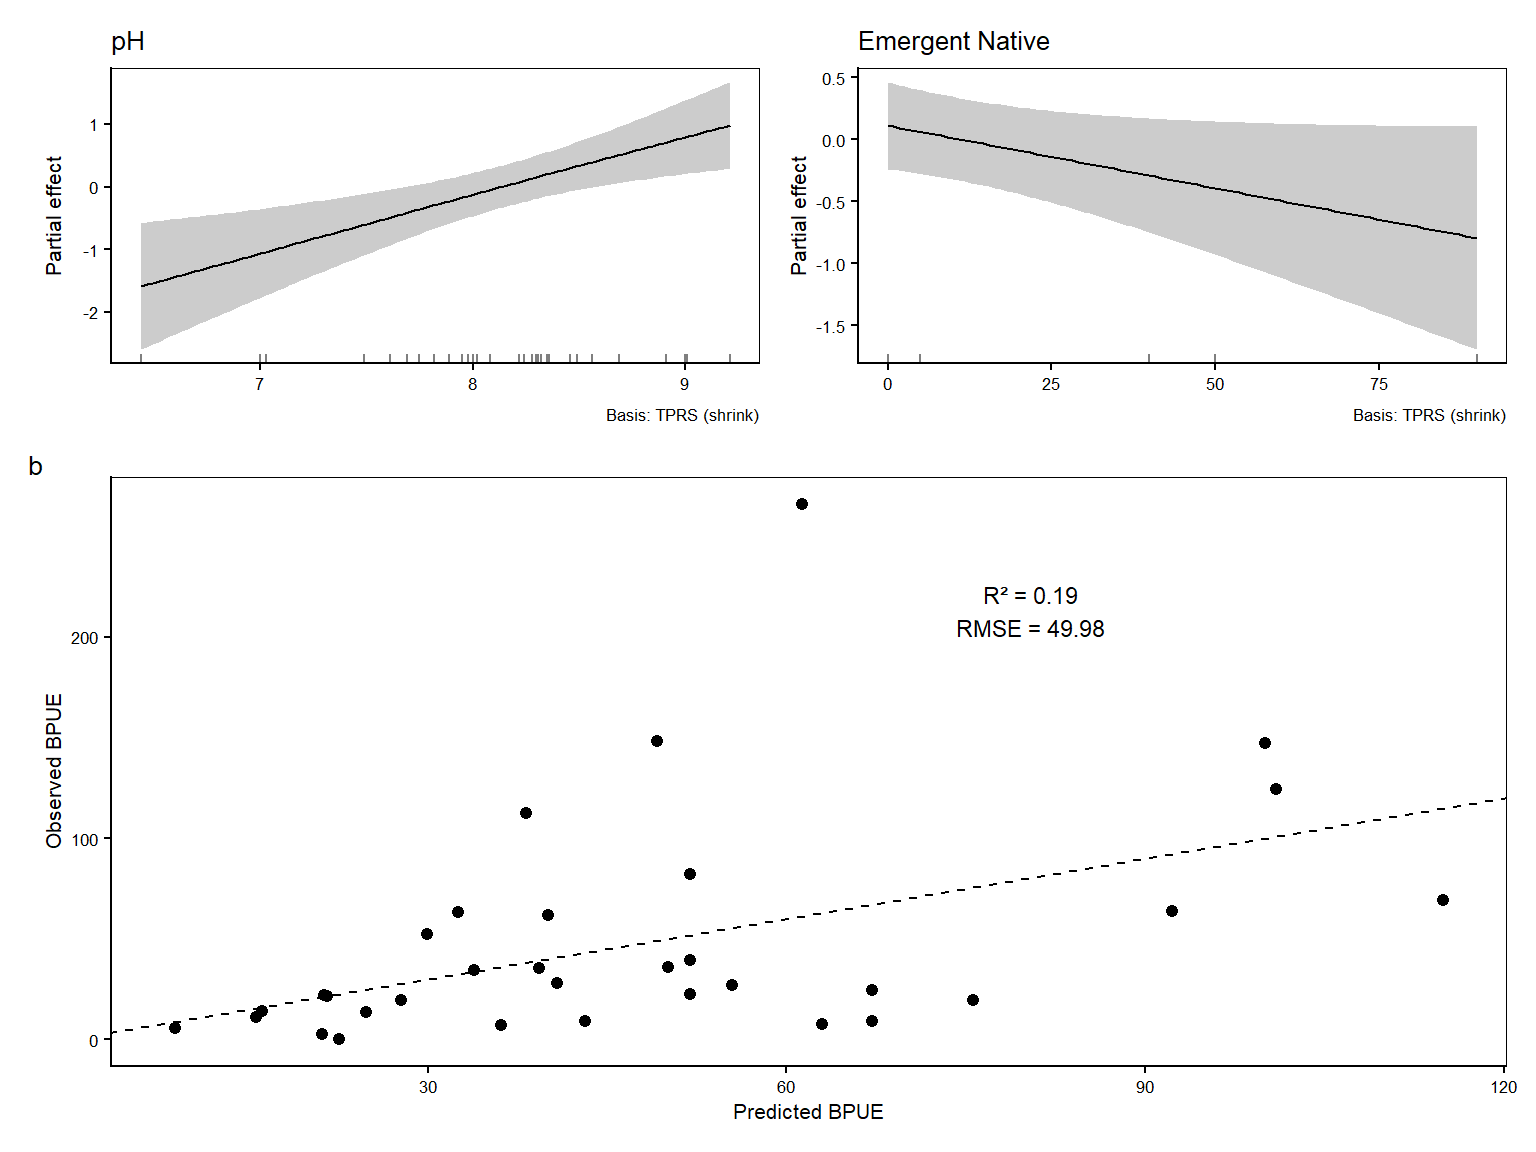

In [ ]:
#| label: fig-bpue-hurdle
#| inluce: true
#| fig-cap: "Kōura BPUE GAMM results and model performance. a) Estimated smooth terms for pH and emergent native vegetation, shown with partial effects and 95% confidence intervals. See Fig. S2 for raw data underlying modelled relationships. b) Predicted versus observed BPUE from the positive (Gamma) component of the hurdle model, with predictions excluding the random lake effect. The dashed 1:1 line indicates perfect agreement; annotated values report R² and RMSE to summarise model fit."

sm_bpue <- smooth_estimates(final_BPUE_pos)
bpue_smooth_names <- setdiff(unique(sm_bpue$.smooth), "s(LID)")
bpue_smooth_plots <- lapply(bpue_smooth_names, function(s) {
gratia::draw(final_BPUE_pos, select = s, scales = "fixed", se = FALSE) +
labs(title = clean_smooth_title(s), x = NULL, y = "Partial effect") +
base_theme_bw
})

p_BPUE_pos_smooths <- patchwork::wrap_plots(bpue_smooth_plots, ncol = length(bpue_smooth_plots)) +
patchwork::plot_annotation(tag_levels = "a")

pred_pos_b <- predict(final_BPUE_pos, type = "response")
obs_pos_b  <- final_BPUE_pos$y
R2_b   <- cor(pred_pos_b, obs_pos_b, use = "complete.obs")^2
RMSE_b <- sqrt(mean((pred_pos_b - obs_pos_b)^2, na.rm = TRUE))

df_scat_b <- data.frame(Predicted = pred_pos_b, Observed = obs_pos_b)

p_BPUE_pos_scatter <- ggplot(df_scat_b, aes(Predicted, Observed)) +
geom_point(size = 1.8, colour = "black") +
geom_abline(slope = 1, intercept = 0, linetype = "dashed", colour = "black", linewidth = 0.4) +
annotate(
"text",
x = max(df_scat_b$Predicted, na.rm = TRUE) * 0.7,
y = max(df_scat_b$Observed,  na.rm = TRUE) * 0.8,
label = paste0("R\u00B2 = ", round(R2_b, 2), "\nRMSE = ", round(RMSE_b, 2)),
size = 3
) +
labs(x = "Predicted BPUE", y = "Observed BPUE", tag = "b") +
base_theme_bw

BPUE_panel_positives <- (p_BPUE_pos_smooths / p_BPUE_pos_scatter) +
patchwork::plot_layout(heights = c(1, 2))

ggsave(filename = file.path(out_dir, "fig-bpue-hurdle.png"),plot = BPUE_panel_positives,width = 100, height = 120, units = "mm", dpi = 1200)

BPUE_panel_positives

## Raw data plots CPUE & BPUE

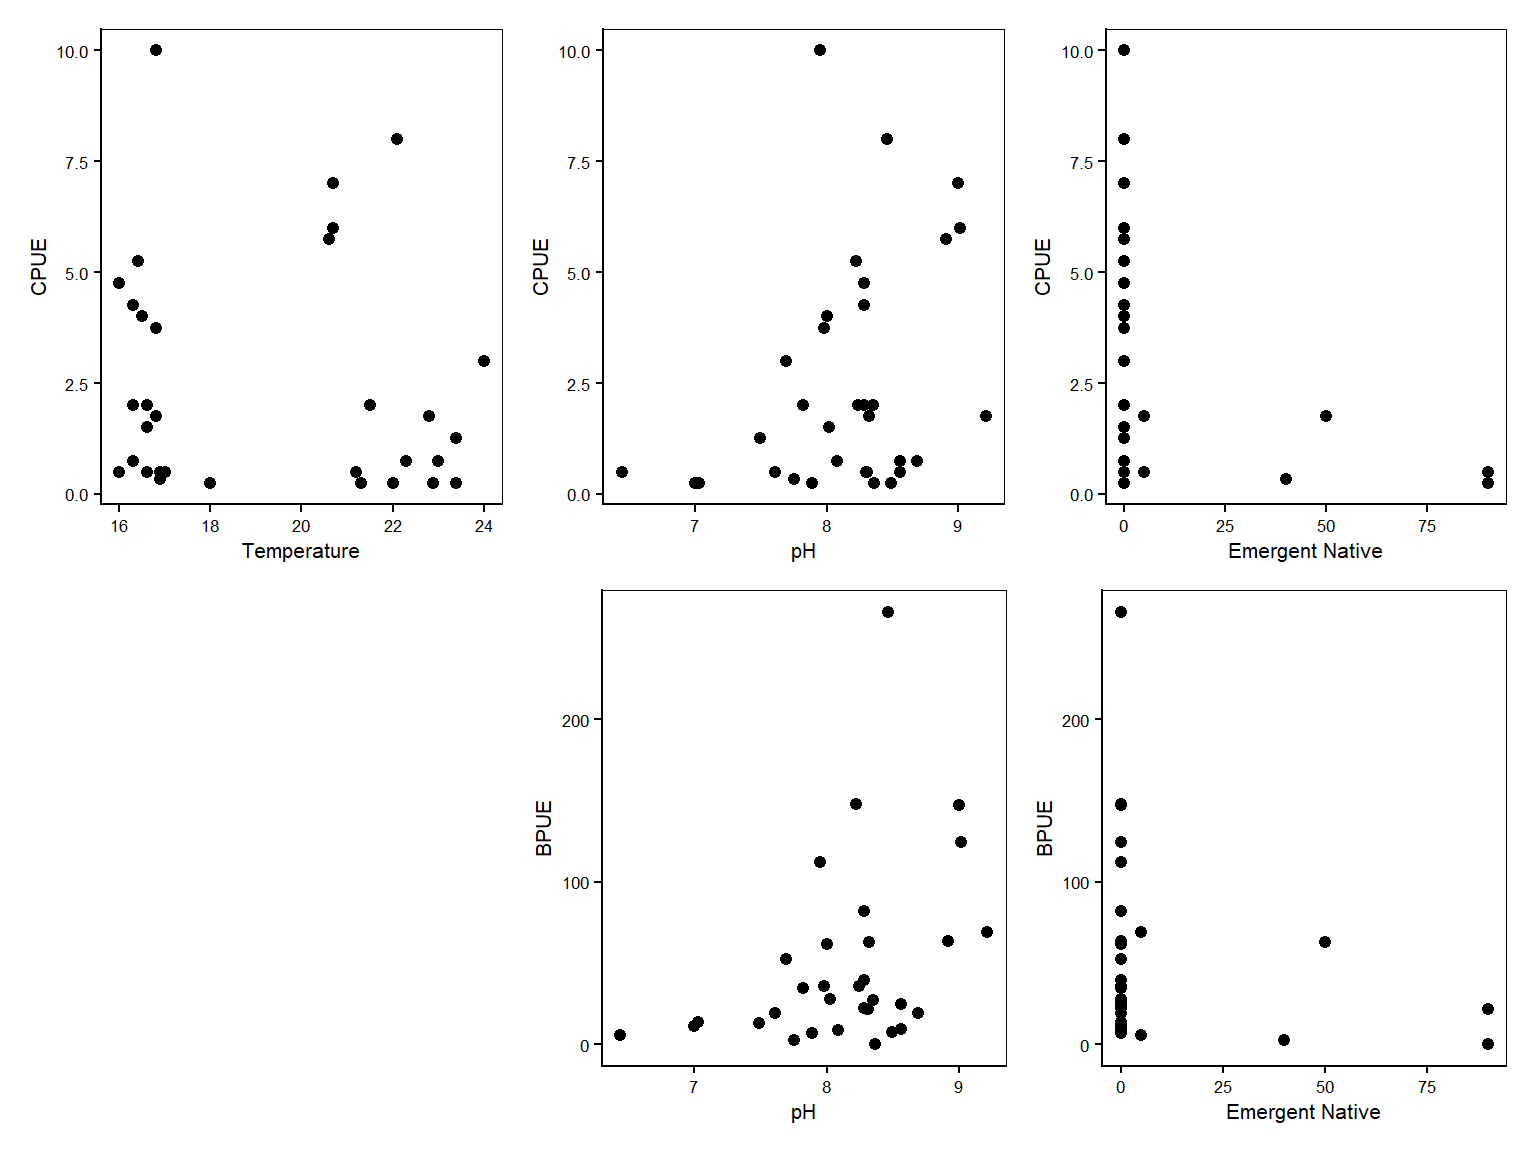

In [ ]:
#| label: fig-raw-data-plots
#| fig-cap: "Raw relationships between significant habitat predictors and kōura CPUE (upper panels) and BPUE (lower panels) at sites where kōura were present. Points represent observed values at individual sites. Temperature (°C), pH, and emergent native vegetation cover (%) are shown for CPUE; pH and emergent native vegetation cover (%) are shown for BPUE."

make_raw_plot <- function(data, x_var, y_var, y_label) {
  ggplot(data, aes(x = .data[[x_var]], y = .data[[y_var]])) +
    geom_point(size = 1.8, colour = "black") +
    labs(x = gsub("_", " ", x_var), y = y_label) +
    base_theme_bw
}

# CPUE raw plots
p_raw_temp_cpue  <- make_raw_plot(Cpos, "Temperature",     "Weighted_CPUE_Kōura", "CPUE")
p_raw_ph_cpue    <- make_raw_plot(Cpos, "pH",              "Weighted_CPUE_Kōura", "CPUE")
p_raw_emerg_cpue <- make_raw_plot(Cpos, "Emergent_Native", "Weighted_CPUE_Kōura", "CPUE")

# BPUE raw plots
p_raw_ph_bpue    <- make_raw_plot(Bpos, "pH",              "Weighted_BPUE_Kōura", "BPUE")
p_raw_emerg_bpue <- make_raw_plot(Bpos, "Emergent_Native", "Weighted_BPUE_Kōura", "BPUE")

raw_plots <- (p_raw_temp_cpue + p_raw_ph_cpue + p_raw_emerg_cpue) /
             (plot_spacer() + p_raw_ph_bpue + p_raw_emerg_bpue)

ggsave(file.path(out_dir, "fig-raw-data-plots.png"), raw_plots,
       width = 180, height = 120, units = "mm", dpi = 1200)

raw_plots

## Model tables (exports)

In [ ]:
#| label: tbl-model-tables
#| include: true

gam_results_table <- function(model, model_name = deparse(substitute(model)), digits = 3) {
sm <- summary(model)

ptab <- as.data.frame(sm$p.table)
ptab <- rownames_to_column(ptab, "term")
ptab <- as_tibble(ptab)

p_col <- names(ptab)[grepl("^Pr\\(>\\|", names(ptab))]
if (length(p_col) != 1) stop("Could not uniquely identify p-value column in p.table.")

stat_col <- names(ptab)[grepl("value$", names(ptab))]
if (length(stat_col) != 1) stop("Could not uniquely identify statistic column in p.table.")

param_tbl <- ptab |>
rename(
estimate  = Estimate,
std_error = `Std. Error`,
statistic = all_of(stat_col),
p_value   = all_of(p_col)
) |>
mutate(component = "parametric", model = model_name) |>
select(model, component, term, estimate, std_error, statistic, p_value) |>
mutate(across(where(is.numeric), ~ round(.x, digits)))

stab <- as.data.frame(sm$s.table)
stab <- rownames_to_column(stab, "term")
stab <- as_tibble(stab)

refdf_col <- names(stab)[grepl("^Ref\\.df$", names(stab))]
edf_col   <- names(stab)[grepl("^edf$", names(stab))]
pval_col  <- names(stab)[grepl("^p\\-value$", names(stab))]
stat_col2 <- names(stab)[grepl("^(F|Chi\\.sq)$", names(stab))]

if (length(edf_col) != 1) stop("Could not uniquely identify edf column in s.table.")
if (length(refdf_col) != 1) stop("Could not uniquely identify Ref.df column in s.table.")
if (length(pval_col) != 1) stop("Could not uniquely identify p-value column in s.table.")
if (length(stat_col2) != 1) stop("Could not uniquely identify test statistic column in s.table.")

smooth_tbl <- stab |>
rename(
edf = all_of(edf_col),
ref_df = all_of(refdf_col),
statistic = all_of(stat_col2),
p_value = all_of(pval_col)
) |>
mutate(component = "smooth", model = model_name) |>
select(model, component, term, edf, ref_df, statistic, p_value) |>
mutate(across(where(is.numeric), ~ round(.x, digits)))

combined_tbl <- bind_rows(
param_tbl |>
mutate(edf = NA_real_, ref_df = NA_real_) |>
select(model, component, term, estimate, std_error, edf, ref_df, statistic, p_value),
smooth_tbl |>
mutate(estimate = NA_real_, std_error = NA_real_) |>
select(model, component, term, estimate, std_error, edf, ref_df, statistic, p_value)
)

list(parametric = param_tbl, smooth = smooth_tbl, combined = combined_tbl)
}

occ_tabs  <- gam_results_table(final_occ,      "Occupancy", digits = 3)
cpue_tabs <- gam_results_table(final_cpue_pos, "CPUE (pos)", digits = 3)
bpue_tabs <- gam_results_table(final_BPUE_pos, "BPUE (pos)", digits = 3)

add_sig <- function(df) {
df |>
mutate(
sig = case_when(
is.na(p_value) ~ "",
p_value < 0.001 ~ "***",
p_value < 0.01  ~ "**",
p_value < 0.05  ~ "*",
p_value < 0.1   ~ ".",
TRUE ~ ""
)
)
}

occ_table  <- add_sig(occ_tabs$combined)
cpue_table <- add_sig(cpue_tabs$combined)
bpue_table <- add_sig(bpue_tabs$combined)

write.csv(occ_table,  file = file.path(out_dir, "table_gam_occupancy.csv"), row.names = FALSE)
write.csv(cpue_table, file = file.path(out_dir, "table_gam_cpue_pos.csv"),  row.names = FALSE)
write.csv(bpue_table, file = file.path(out_dir, "table_gam_bpue_pos.csv"),  row.names = FALSE)

all_models_table <- bind_rows(occ_table, cpue_table, bpue_table)
write.csv(all_models_table, file = file.path(out_dir, "table_gam_all_models.csv"), row.names = FALSE)

all_models_table |>
  mutate(
    term = gsub("s\\(|\\)", "", term),
    p_value = ifelse(!is.na(p_value), format.pval(p_value, digits = 3, eps = 0.001), NA)
  ) |>
  select(-model) |>
  kable(
    caption = "GAM model results for kōura occupancy, CPUE, and BPUE models. Significance codes: *** p < 0.001, ** p < 0.01, * p < 0.05, . p < 0.1",
    col.names = c("Component", "Term", "Estimate", "SE", "EDF", "Ref.df", "Statistic", "p-value", ""),
    align = c("l","l","r","r","r","r","r","r","l")
  ) |>
  kable_styling(
    bootstrap_options = c("striped", "hover", "condensed"),
    full_width = FALSE
  ) |>
  kableExtra::group_rows("Occupancy", 1, nrow(occ_table)) |>
  kableExtra::group_rows("CPUE (positive sites)", nrow(occ_table) + 1, nrow(occ_table) + nrow(cpue_table)) |>
  kableExtra::group_rows("BPUE (positive sites)", nrow(occ_table) + nrow(cpue_table) + 1, nrow(all_models_table))

+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| Component  | Term                  | Estimate  | SE        | EDF       | Ref.df    | Statistic | p-value   |           |
+============+=======================+===========+===========+===========+===========+===========+===========+===========+
| **Occupancy**                                                                                                          |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| parametric | (Intercept            | 2.098     | 0.886     | NA        | NA        | 2.368     | 0.018     | \*        |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| parametric | Presence_Goldfish     | -3.280    | 1.379     | NA        | NA        | -2.379    | 0.017     | \*        |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| parametric | Presence_Catfish      | 4.222     | 1.718     | NA        | NA        | 2.458     | 0.014     | \*        |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| smooth     | Riparian_vegetation   | NA        | NA        | 0.849     | 6         | 3.965     | 0.026     | \*        |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| smooth     | Substrate_index       | NA        | NA        | 0.980     | 9         | 9.163     | 0.001     | \*\*      |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| smooth     | Temperature           | NA        | NA        | 1.161     | 9         | 13.049    | \<0.001   | \*\*\*    |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| smooth     | Specific_conductivity | NA        | NA        | 0.937     | 9         | 8.248     | 0.002     | \*\*      |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| smooth     | LID                   | NA        | NA        | 0.000     | 4         | 0.000     | 0.622     |           |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| **CPUE (positive sites)**                                                                                              |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| parametric | (Intercept            | 0.928     | 0.194     | NA        | NA        | 4.790     | \<0.001   | \*\*\*    |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| parametric | Presence_Common_smelt | -0.609    | 0.284     | NA        | NA        | -2.145    | 0.041     | \*        |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| smooth     | Temperature           | NA        | NA        | 0.823     | 9         | 0.561     | 0.019     | \*        |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| smooth     | pH                    | NA        | NA        | 1.020     | 9         | 2.085     | \<0.001   | \*\*\*    |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| smooth     | Emergent_Native       | NA        | NA        | 0.980     | 3         | 7.160     | \<0.001   | \*\*\*    |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| smooth     | LID                   | NA        | NA        | 0.000     | 4         | 0.000     | 0.482     |           |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| **BPUE (positive sites)**                                                                                              |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| parametric | (Intercept            | 3.702     | 0.169     | NA        | NA        | 21.943    | \<0.001   | \*\*\*    |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| smooth     | pH                    | NA        | NA        | 0.967     | 9         | 1.238     | 0.002     | \*\*      |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| smooth     | Emergent_Native       | NA        | NA        | 0.761     | 3         | 1.154     | 0.041     | \*        |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+
| smooth     | LID                   | NA        | NA        | 0.000     | 4         | 0.000     | 0.607     |           |
+------------+-----------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+


# PCA (habitat complexity)

Importance of components:
                          PC1    PC2    PC3     PC4     PC5     PC6     PC7
Standard deviation     1.4421 1.2825 1.1245 0.80595 0.76777 0.64184 0.60000
Proportion of Variance 0.2971 0.2350 0.1807 0.09279 0.08421 0.05885 0.05143
Cumulative Proportion  0.2971 0.5321 0.7127 0.80551 0.88972 0.94857 1.00000

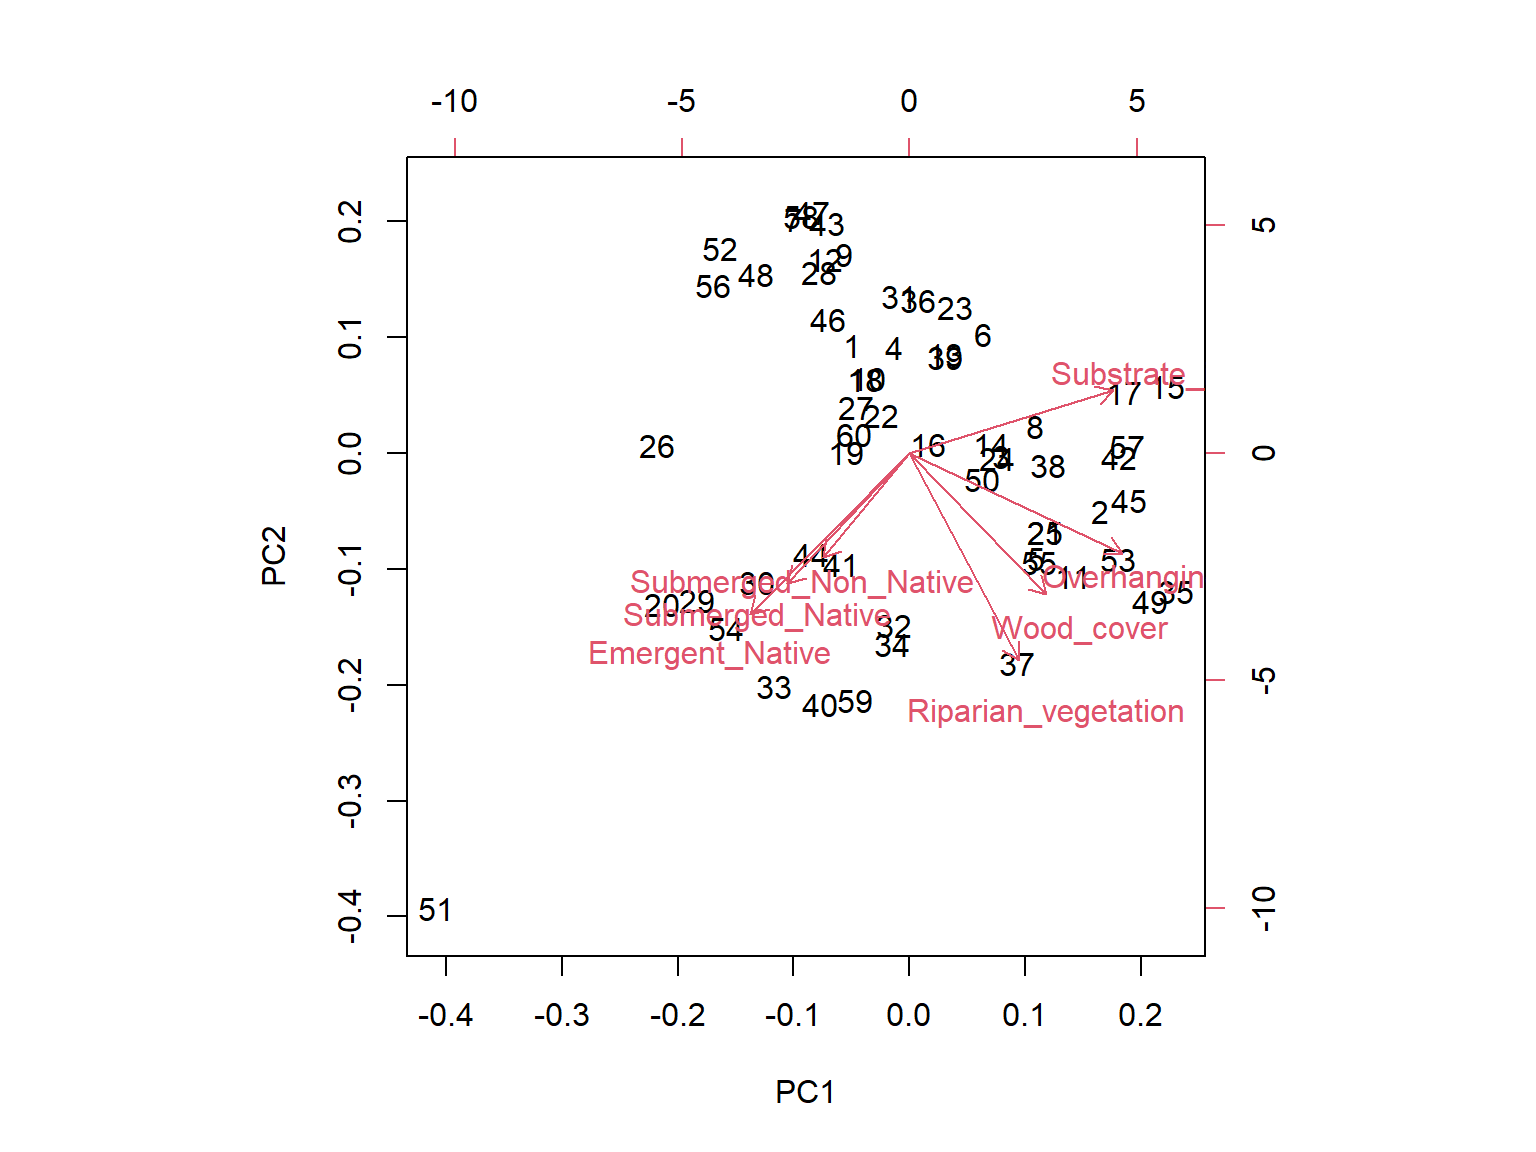

                            PC1        PC2        PC3         PC4        PC5
Riparian_vegetation   0.2691729 -0.5734874 -0.1219808 -0.46678738  0.1080919
Substrate_index       0.5006488  0.1730728 -0.3222116 -0.43522295 -0.2999105
Wood_cover            0.3362884 -0.3905629  0.3965271  0.53597482 -0.3013394
Overhanging_trees     0.5243168 -0.2768683 -0.1062900  0.21679548  0.3197312
Emergent_Native      -0.3921398 -0.4450793 -0.2763342  0.03053358  0.4729932
Submerged_Native     -0.3000816 -0.3609182 -0.4787215  0.13983049 -0.6683603
Submerged_Non_Native -0.2123113 -0.2891455  0.6381490 -0.48778723 -0.1868376
                             PC6         PC7
Riparian_vegetation  -0.51145371  0.30433475
Substrate_index       0.14622472 -0.56109649
Wood_cover           -0.25170700 -0.36838314
Overhanging_trees     0.64334259  0.27206657
Emergent_Native       0.08366168 -0.58319468
Submerged_Native      0.21080368  0.19954596
Submerged_Non_Native  0.43399293 -0.05375961

In [ ]:
#| label: pca
#| include: false

# Comment Frank about the modeling:
  # If you centered (on the mean) and standardized (scaled to unit variance) the predictors you could use the parameter estimates as an effect size to say something about the importance of the predictors (i.e. weak vs strong effects).


habitat_vars <- M_C_data %>%
dplyr::select(
Riparian_vegetation,
Substrate_index,
Wood_cover,
Overhanging_trees,
Emergent_Native,
Submerged_Native,
Submerged_Non_Native
) %>%
dplyr::filter(complete.cases(.))

habitat_pca <- prcomp(habitat_vars, center = TRUE, scale. = TRUE)

summary(habitat_pca)

# Koura catfish interaction

In [ ]:
#| label: koura-catfish-interaction
#| include: false

# 1. Catfish distribution across habitat types
M_C_data %>%
  group_by(Habitat_Type) %>%
  summarise(n_sites = n(),
            catfish_present = sum(Presence_Catfish, na.rm = TRUE),
            koura_present = sum(Presence_Kōura, na.rm = TRUE),
            mean_CPUE_koura = mean(Weighted_CPUE_Kōura, na.rm = TRUE))

# A tibble: 4 × 5
  Habitat_Type        n_sites catfish_present koura_present mean_CPUE_koura
  <chr>                 <int>           <dbl>         <dbl>           <dbl>
1 Emergent Macrophyte       9               1             5           0.370
2 Muddy                     7               1             1           0.25 
3 Rocky                    14               1            13           3.18 
4 Sandy                    30               3            14           1.09 

# A tibble: 2 × 5
  Presence_Catfish     n koura_presence_rate mean_CPUE_koura mean_BPUE_koura
             <dbl> <int>               <dbl>           <dbl>           <dbl>
1                0    54               0.556           1.48            28.7 
2                1     6               0.5             0.417            7.88

# A tibble: 2 × 5
  catfish_lake    n_sites koura_presence_rate mean_CPUE_koura mean_BPUE_koura
  <chr>             <int>               <dbl>           <dbl>           <dbl>
1 Catfish absent       36               0.667           1.75             35.4
2 Catfish present      24               0.375           0.812            13.5

```` markdown
---
title: "Analysis Notebook"
format:
  html:
    fig-path: "analysis_files/figure-html/"
    theme:
      light: flatly
      dark: darkly
    code-fold: true
    code-tools: true
    code-summary: "View Code"
    toc: true
    toc-depth: 3
    number-sections: true
fig-width: 8
fig-height: 6

execute:
  freeze: false
  cache: false

---

# Setup
quarto-executable-code-5450563D

```r
#| label: setup
#| include: false


knitr::opts_knit$set(root.dir = normalizePath(".."))
options(warn = -1)
packages <- c(
  "here","kableExtra","emmeans","rstatix","multcompView","brglm2","patchwork","gratia","pROC","caret",
  "mgcv","tidyr","purrr","corrplot","glmmTMB","performance","tibble","tidyverse",
  "dplyr","writexl","readxl","lubridate")

quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(pkg, dependencies = TRUE)))
  }
  suppressPackageStartupMessages(require(pkg, character.only = TRUE, quietly = TRUE))
  invisible(TRUE)
}

invisible(lapply(packages, quiet_load))


exc_file_dir <- "data/raw/Natural_habitat.xlsx"
der_data_dir <- "data/derived"
out_dir      <- "outputs"

dir.create(exc_file_dir, showWarnings = FALSE, recursive = TRUE)
dir.create(der_data_dir, showWarnings = FALSE, recursive = TRUE)
dir.create(out_dir,      showWarnings = FALSE, recursive = TRUE)

Site_info          <- read_excel(exc_file_dir, sheet = "Site_info")
Monitoring_data    <- read_excel(exc_file_dir, sheet = "Monitoring_data")
Weed_data          <- read_excel(exc_file_dir, sheet = "Weed_data")  %>% dplyr::select(-starts_with("..."))
Fish_data          <- read_excel(exc_file_dir, sheet = "Fish_data")  %>% dplyr::select(-starts_with("..."))
Macroinvertebrates <- read_excel(exc_file_dir, sheet = "Macroinvertebrates")

Site_info          <- Site_info          |> dplyr::filter(!stringr::str_ends(Monitoring_ID, "_1"))
Monitoring_data    <- Monitoring_data    |> dplyr::filter(!stringr::str_ends(Monitoring_ID, "_1"))
Weed_data          <- Weed_data          |> dplyr::filter(!stringr::str_ends(Monitoring_ID, "_1"))
Fish_data          <- Fish_data          |> dplyr::filter(!stringr::str_ends(Monitoring_ID, "_1"))
Macroinvertebrates <- Macroinvertebrates |> dplyr::filter(!stringr::str_ends(Monitoring_ID, "_1"))

# Save as csv to derived
write.csv(Site_info,          file.path(der_data_dir, "Site_info.csv"),          row.names = FALSE)
write.csv(Monitoring_data,    file.path(der_data_dir, "Monitoring_data.csv"),    row.names = FALSE)
write.csv(Weed_data,          file.path(der_data_dir, "Weed_data.csv"),          row.names = FALSE)
write.csv(Fish_data,          file.path(der_data_dir, "Fish_data.csv"),          row.names = FALSE)
write.csv(Macroinvertebrates, file.path(der_data_dir, "Macroinvertebrates.csv"), row.names = FALSE)

# Reproducibility note 
# The sections above require data/raw/Natural_habitat.xlsx (not tracked).
# To reproduce analyses and figures without the raw Excel file,
# run from here using the derived CSVs in data/derived/:

Site_info          <- read.csv(file.path(der_data_dir, "Site_info.csv"))
Monitoring_data    <- read.csv(file.path(der_data_dir, "Monitoring_data.csv"))
Weed_data          <- read.csv(file.path(der_data_dir, "Weed_data.csv"))
Fish_data          <- read.csv(file.path(der_data_dir, "Fish_data.csv"))
Macroinvertebrates <- read.csv(file.path(der_data_dir, "Macroinvertebrates.csv"))

# Set plot theme
base_theme_bw <- theme_classic() +
  theme(
    text = element_text(family = "Arial", size = 8),
    axis.title = element_text(face = "plain"),
    axis.text = element_text(face = "plain"),
    plot.title = element_text(face = "plain"),
    strip.text = element_text(face = "plain"),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.3)
  )

theme_set(base_theme_bw)

clean_smooth_title <- function(x) {
  x <- gsub("^s\\((.*)\\)$", "\\1", x)
  x <- gsub("_", " ", x)
  x
}

```


# CPUE and BPUE derivation
## Length–weight model and predicted weights
quarto-executable-code-5450563D

```r
#| label: fig-length-weight
#| include: true
#| fig-cap: "Length–weight relationship used to estimate missing kōura weights. Observed (measured) and model-predicted body weights are shown in relation to orbital carapace length (OCL). The log₁₀–log₁₀ regression was fitted to individuals with both length and weight measurements (n = 240) and used to estimate missing weights (n = 81). Predicted values were back-transformed using a lognormal bias correction factor. The fitted regression equation is shown on the plot."

lw_model <- lm(
log10(Weight_g) ~ log10(Length_mm),
data = Fish_data,
subset = Species_name == "Freshwater_crayfish" | Maori_name == "Kōura",
na.action = na.exclude
)

sigma_log10 <- sigma(lw_model)
c <- 10^(0.5 * sigma_log10^2)

Fish_data <- Fish_data |>
mutate(
is_koura = Species_name == "Freshwater_crayfish" | Maori_name == "Kōura",
Predicted_weight = case_when(
!is.na(Weight_g) ~ Weight_g,
is_koura ~ {
pred_log <- predict(lw_model, newdata = pick(everything()))
10^(pred_log) * c
},
TRUE ~ NA_real_
),
Weight_source = case_when(
is_koura & !is.na(Weight_g) ~ "measured",
is_koura & is.na(Weight_g) ~ "predicted",
TRUE ~ NA_character_
)
)

a <- coef(lw_model)[1]
b <- coef(lw_model)[2]
formula_text <- paste0(
"log10(Weight[g]) = ", round(a, 3), " + ", round(b, 3),
" * log10(OCL Length[mm])"
)

length_weight_plot <- ggplot(
Fish_data |> dplyr::filter(is_koura),
aes(x = Length_mm, y = Predicted_weight, shape = Weight_source)) +
geom_point(size = 2.2, colour = "black", stroke = 0.6) +
scale_shape_manual(values = c("measured" = 16, "predicted" = 1)) +
labs(x = "OCL length (mm)", y = "Weight (g)", shape = "Weight source") +
annotate("text", x = Inf, y = Inf, label = formula_text, hjust = 1.1, vjust = 1.3, size = 3) 

ggsave(filename = file.path(out_dir, "fig-length-weight.png"), plot = length_weight_plot, width = 170, height = 120, units = "mm", dpi = 1200, create.dir = TRUE)

length_weight_plot
```

## CPUE and BPUE calculations
quarto-executable-code-5450563D

```r
#| label: cpue-bpue-calculations
#| include: false

CPUE_BPUE_legacy <- Fish_data %>%
filter(!is.na(Species)) %>%
group_by(Monitoring_ID, Species, Net_type) %>%
dplyr::reframe(
Total_Individuals = sum(Amount, na.rm = TRUE),
Total_Weight      = sum(Predicted_weight, na.rm = TRUE),
Total_Effort      = dplyr::first(Amount_nets),
CPUE              = Total_Individuals / Total_Effort,
BPUE              = Total_Weight / Total_Effort,
Mean_Length       = mean(Length_mm, na.rm = TRUE),
Min_Length        = ifelse(all(is.na(Length_mm)), NA, min(Length_mm, na.rm = TRUE)),
Max_Length        = ifelse(all(is.na(Length_mm)), NA, max(Length_mm, na.rm = TRUE)),
Mean_Weight       = mean(Predicted_weight, na.rm = TRUE),
Min_Weight        = ifelse(all(is.na(Predicted_weight)), NA, min(Predicted_weight, na.rm = TRUE)),
Max_Weight        = ifelse(all(is.na(Predicted_weight)), NA, max(Predicted_weight, na.rm = TRUE))
)

CPUE_BPUE_weighted <- CPUE_BPUE_legacy %>%
group_by(Monitoring_ID, Species) %>%
summarise(
Total_Individuals       = sum(Total_Individuals, na.rm = TRUE),
Total_Weight            = sum(Total_Weight,      na.rm = TRUE),
Weighted_CPUE_numerator = sum(CPUE * Total_Effort,  na.rm = TRUE),
Weighted_BPUE_numerator = sum(BPUE * Total_Effort,  na.rm = TRUE),
Total_Effort_sum        = sum(Total_Effort,         na.rm = TRUE),
Mean_Length             = mean(Mean_Length, na.rm = TRUE),
Min_Length              = ifelse(all(is.na(Min_Length)), NA, min(Min_Length, na.rm = TRUE)),
Max_Length              = ifelse(all(is.na(Max_Length)), NA, max(Max_Length, na.rm = TRUE)),
Mean_Weight             = mean(Mean_Weight, na.rm = TRUE),
Min_Weight              = ifelse(all(is.na(Min_Weight)), NA, min(Min_Weight, na.rm = TRUE)),
Max_Weight              = ifelse(all(is.na(Max_Weight)), NA, max(Max_Weight, na.rm = TRUE)),
.groups = "drop"
) %>%
mutate(
Total_Effort_sum = ifelse(Monitoring_ID %in% c("96_0", "101_0", "117_1", "119_1"), 3, 4),
Weighted_CPUE    = Weighted_CPUE_numerator / Total_Effort_sum,
Weighted_BPUE    = Weighted_BPUE_numerator / Total_Effort_sum
)

species_presence_absence <- Fish_data %>%
filter(!is.na(Species)) %>%
distinct(Monitoring_ID, Species) %>%
mutate(Presence = 1) %>%
pivot_wider(
names_from  = Species,
values_from = Presence,
values_fill = list(Presence = 0),
names_prefix = "Presence_"
) %>%
mutate(Predator_Fish_Presence = pmax(Presence_Trout, Presence_Eel, Presence_Catfish))

CPUE_BPUE_weighted_summary <- CPUE_BPUE_weighted %>%
pivot_wider(
names_from  = Species,
values_from = c(
Total_Individuals, Weighted_CPUE, Weighted_BPUE, Total_Weight,
Mean_Length, Mean_Weight, Weighted_CPUE_numerator, Weighted_BPUE_numerator,
Total_Effort_sum, Min_Length, Max_Length, Min_Weight, Max_Weight
),
names_sep   = "_",
values_fill = list(Total_Individuals = 0, Weighted_CPUE = 0, Weighted_BPUE = 0)
) %>%
mutate(
Richness  = rowSums(dplyr::select(., starts_with("Total_Individuals_")) > 0),
Abundance = rowSums(dplyr::select(., starts_with("Total_Individuals_") & !ends_with(c("_Bullies", "_Common_smelt"))))
)

```

# Combined dataset and habitat classification
quarto-executable-code-5450563D

```r
#| label: combine-dataframes
#| include: false

unit_metadata <- Monitoring_data %>%
dplyr::select(Parameter, Unit) %>%
distinct()

Monitoring_summary <- Monitoring_data %>%
dplyr::select(-Group, -Notes, -Unit) %>%
pivot_wider(
names_from  = c(Parameter),
values_from = Value,
values_fill = list(Value = NA)
) %>%
mutate(across(
c(
Bottom_visible, Water_clarity, Depth_10m, Slope, Riparian_vegetation, Vegetation_nearby,
Overhanging_trees, Erosion, Structure, Bedrock, Boulders, Cobble, Gravel,
Sand, Mud, Organic_matter, Rock_size, Temperature, DO_mgl, DO_percent,
Conductivity, Specific_conductivity, pH, Wood_cover
),
~ as.numeric(.)
))

Weed_summary <- Weed_data %>%
group_by(Monitoring_ID, Weed_Type, Native_Status) %>%
summarise(Total_Cover = sum(Percentage_Cover, na.rm = TRUE), .groups = "drop") %>%
pivot_wider(
names_from  = c(Weed_Type, Native_Status),
values_from = Total_Cover,
values_fill = 0
)

Macroinvertebrates_sum <- Macroinvertebrates %>%
group_by(Monitoring_ID, Species) %>%
summarise(Total_amount = sum(Amount, na.rm = TRUE), .groups = "drop") %>%
pivot_wider(names_from = c(Species), values_from = Total_amount, values_fill = 0) %>%
mutate(
Invertebrates_Richness  = rowSums(dplyr::select(., -Monitoring_ID) > 0),
Invertebrates_Abundance = rowSums(dplyr::select(., -Monitoring_ID))
)

Monitoring_CPUE_data <- Site_info %>%
left_join(Monitoring_summary, by = "Monitoring_ID") %>%
left_join(
Weed_summary %>% dplyr::select(
Monitoring_ID,
Emergent_Native, Emergent_Non_Native,
Submerged_Native, Submerged_Non_Native, Turf_Native
),
by = "Monitoring_ID"
) %>%
left_join(CPUE_BPUE_weighted_summary, by = "Monitoring_ID") %>%
left_join(species_presence_absence, by = "Monitoring_ID") %>%
left_join(Macroinvertebrates_sum, by = "Monitoring_ID")

Monitoring_CPUE_data <- Monitoring_CPUE_data %>%
  mutate(
    Presence_rocks = if_else(Cobble > 1 | Boulders > 1, 1, 0),
    Slope_5m       = 5 / Distance_5m,
    Site_ID_       = Site_ID.x - 60,
    Monitoring_ID_ = paste0(
      as.numeric(sub("_.*", "", Monitoring_ID)) - 60,
      sub("^[^_]*", "", Monitoring_ID)
    ),
    Monitoring     = sub(".*?_", "", Monitoring_ID),
    Date           = as.Date(Date_Time),
    Time           = format(as.POSIXct(Date_Time), "%H:%M:%S"),
    Year           = lubridate::year(Date_Time),
    Month          = lubridate::month(Date_Time, label = TRUE),
    Day            = lubridate::day(Date_Time),
    Season         = case_when(
      Month %in% c("Dec", "Jan", "Feb") ~ "Summer",
      Month %in% c("Mar", "Apr", "May") ~ "Autumn",
      Month %in% c("Jun", "Jul", "Aug") ~ "Winter",
      Month %in% c("Sep", "Oct", "Nov") ~ "Spring",
      TRUE ~ NA_character_
    ),
    Date_Time_Numeric = as.numeric(Date_Time)
  )

habitat_classification <- Monitoring_CPUE_data %>%
dplyr::select(
Monitoring_ID, DHT, Lake,
Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter,
Emergent_Native, Emergent_Non_Native,
Submerged_Native, Submerged_Non_Native, Wood_cover
) %>%
pivot_longer(
cols = c(
Bedrock, Boulders, Cobble, Gravel, Sand, Mud, Organic_matter,
Emergent_Native, Emergent_Non_Native,
Submerged_Native, Submerged_Non_Native, Wood_cover
),
names_to = "Type",
values_to = "Percentage"
) %>%
group_by(Monitoring_ID) %>%
summarise(
Rocky_Percentage = sum(Percentage[Type %in% c("Bedrock", "Boulders", "Cobble")], na.rm = TRUE),
Sand_Percentage  = sum(Percentage[Type == "Sand"], na.rm = TRUE),
Mud_Percentage   = sum(Percentage[Type %in% c("Mud", "Organic_matter")], na.rm = TRUE),
Emergent_Percentage = sum(Percentage[Type == "Emergent_Native"], na.rm = TRUE),
Substrate_index = sum(
0.08 * Percentage[Type == "Bedrock"] +
0.07 * Percentage[Type == "Boulders"] +
0.06 * Percentage[Type == "Cobble"] +
0.04 * Percentage[Type == "Gravel"] +
0.03 * Percentage[Type == "Sand"] +
0.02 * Percentage[Type == "Organic_matter"] +
0.01 * Percentage[Type == "Mud"],
na.rm = TRUE
),
Substrate_CV = {
substrate_vals <- Percentage[Type %in% c("Bedrock", "Boulders", "Cobble", "Gravel", "Sand", "Mud", "Organic_matter")]
substrate_vals <- substrate_vals[!is.na(substrate_vals)]
if (length(substrate_vals) > 1 && mean(substrate_vals) > 0) {
sd(substrate_vals) / mean(substrate_vals)
} else {
NA_real_
}
},
.groups = "drop"
) %>%
mutate(
Habitat_Type = case_when(
Rocky_Percentage > 25 ~ "Rocky",
Emergent_Percentage > 25 ~ "Emergent Macrophyte",
Sand_Percentage >= Mud_Percentage ~ "Sandy",
TRUE ~ "Muddy"
)
) %>%
dplyr::select(Monitoring_ID, Habitat_Type, Substrate_index, Substrate_CV)

Monitoring_CPUE_data <- Monitoring_CPUE_data %>%
left_join(habitat_classification, by = "Monitoring_ID")

#writexl::write_xlsx(Monitoring_CPUE_data, file.path(der_data_dir, "Monitoring_CPUE_data.xlsx"))
#write.csv(Monitoring_CPUE_data, file.path(der_data_dir, "Monitoring_CPUE_data.csv"), row.names = FALSE)
#write.csv(habitat_classification, file.path(der_data_dir, "habitat_classification.csv"), row.names = FALSE)

#head(Monitoring_CPUE_data)

```

## habitat-correlation
quarto-executable-code-5450563D

```r
#| label: habitat-correlation
#| include: true

cor(habitat_classification$Substrate_index,
habitat_classification$Substrate_CV,
use = "complete.obs")
```

# Lake overview table
quarto-executable-code-5450563D

```r
#| label: tbl-lake-overview
#| echo: FALSE
#| tbl-cap: "Physical, morphometric, and trophic characteristics of the five Rotorua Te Arawa lakes surveyed, including sampling dates and number of littoral sites sampled per lake. Lake surface area, perimeter length, catchment area, depth, elevation, mixing regime, and trophic state for 2024, values are derived from the Land, Air, Water Aotearoa (LAWA) database (@LAWA2025)."


lake_data <- data.frame(
  `Lake name` = c("Rotorua", "Rotoiti", "Rotoehu", "Rotomā", "Ōkāreka"),
  `Sampling date (number of sites)` = c("20/02/2025 (12)", "15/01/2025 (12)", "10/12/2024 (12)", "6/11/2024 (12)", "31/10/2024 (10), 22/01/2025 (2)"),
  `Surface area (km²)` = c(81, 34, 8, 11, 3),
  `Perimeter length (km)` = c(45, 61, 40, 24, 11),
  `Catchment area size (km²)` = c(508, 123.7, 49.2, 27.8, 19.6),
  `Mean depth (m)` = c(11, 31.5, 8, 36.9, 20),
  `Maximum depth (m)` = c(45, 124, 13.5, 83, 33.5),
  `Elevation (m)` = c(280, 279, 295, 316, 355),
  `Mixing regime` = c("Polymictic", "Stratified", "Polymictic", "Stratified", "Stratified"),
  `Trophic state` = c("Eutrophic", "Mesotrophic", "Eutrophic", "Oligotrophic", "Mesotrophic")
)

kable(lake_data, caption = "Table 1: Physical, morphometric, and trophic characteristics of the five Rotorua Te Arawa lakes surveyed.")

```


# Overview of environmental and biotic variables 
quarto-executable-code-5450563D

```r
#| label: tbl-environmental-biotic-overview
#| echo: FALSE
#| tbl-cap: "Overview of environmental and biotic variables measured at littoral sampling sites, including variable descriptions, units, and hypothesised relevance for kōura (Paranephrops planifrons). Variables were selected a priori based on known habitat requirements, physiological constraints, and potential biotic interactions influencing kōura occurrence, abundance, and biomass in lake littoral zones."


biotic_vars <- data.frame(
  Variable = c(
    "Lake identity (LID)",
    "Substrate index",
    "Slope",
    "Riparian vegetation",
    "Overhanging trees",
    "Wood cover",
    "Emergent and submerged vegetation",
    "Temperature",
    "Dissolved oxygen",
    "Specific conductivity",
    "pH",
    "Fish presence"
  ),
  `Description / Unit` = c(
    "Categorical variable identifying lake",
    "Index based on % cover of bedrock, boulders, cobble, gravel, sand, mud, and organic matter",
    "Slope from shoreline to the 5 m depth contour",
    "Percentage cover of vegetation growing in the riparian zone",
    "Percentage cover of trees hanging over the shoreline",
    "Cover of wooden logs and tree branches in the sample site",
    "Percentage cover of vegetation divided over emergent/submerged and native/non-native species",
    "Temperature of surface water in °C",
    "Dissolved oxygen concentration in mg L⁻¹",
    "Electrical conductivity of the water in µS cm⁻¹",
    "Acidity or alkalinity of the water",
    "Presence/absence of selected native and non-native fish species"
  ),
  `Hypothesised importance for kōura` = c(
    "Captures unmeasured lake specific differences in water chemistry, productivity, and catchment characteristics.",
    "Important for burrowing and shelter availability. Coarser substrates increase shelter availability through more crevices.",
    "Steeper slopes facilitate access to deeper water during daylight refuging and associate with coarser substrates.",
    "Contributes detrital inputs, bank stability, and shading at the water’s edge.",
    "Provides direct shading and structural inputs into littoral habitats.",
    "Provides physical structure creating refuge spaces and supports macroinvertebrate prey availability.",
    "Native vegetation provides cover and food source; non-native may alter movement and habitat conditions.",
    "Influences metabolic rate, activity, physiological stress, and habitat suitability.",
    "Essential for respiration; reduced oxygen may constrain activity and habitat use.",
    "Reflects overall lake productivity, supporting food availability.",
    "Influences moulting success and exoskeleton strength, affected by acidity or calcium levels.",
    "Fish act as predators, competitors, or indirectly modify habitat structure."
  ),
  References = c(
    "Zuur et al., (2009)",
    "Usio & Townsend, (2000); Kusabs et al., (2015b)",
    "Devcich, (1979); Kusabs et al., (2015b)",
    "Parkyn et al., (2002)",
    "Smith et al., (1996); Vedia et al., (2017)",
    "Parkyn et al., (2009)",
    "Coffey & Clayton, (1988); Kusabs & Quinn, (2009)",
    "Devcich, (1979); Hammond et al., (2006); Parkyn et al., (2002); Parkyn & Collier, (2002); Angilletta et al., (2004)",
    "Hammond et al., (2006); Broughton et al., (2017)",
    "Devcich, (1979)",
    "Olsson et al., (2006)",
    "Shave et al., (1994); Barnes, (1996); Usio & Townsend, (2000); Barnes & Hicks, (2003)"
  )
)

kable(biotic_vars, caption = "Table 2: Overview of environmental and biotic variables measured at littoral sampling sites.")

```


# Environmental and fish summaries (tables)
quarto-executable-code-5450563D

```r
#| label: tbl-env-fish-summary
#| include: true
#| tbl-cap: "Distribution of environmental and biotic variables measured at littoral sampling sites across five Te Arawa lakes in the Rotorua region of Aotearoa New Zealand."


M_C_data <- Monitoring_CPUE_data
lake_order <- c("Rotorua", "Rotoiti", "Rotoehu", "Rotomā", "Ōkāreka")
M_C_data$Lake <- factor(M_C_data$Lake, levels = lake_order)

ci95 <- function(x) {
  x <- x[!is.na(x)]
  n <- length(x)
  if (n < 2) return(c(NA_real_, NA_real_))
  se <- sd(x) / sqrt(n)
  tcrit <- qt(0.975, df = n - 1)
  m <- mean(x)
  c(m - tcrit * se, m + tcrit * se)
}

unit_lookup <- Monitoring_data %>%
  dplyr::select(Parameter, Unit) %>%
  dplyr::distinct() %>%
  dplyr::mutate(
    Variable = dplyr::case_when(
      Parameter == "Riparian_vegetation"       ~ "Riparian_vegetation",
      Parameter == "Overhanging_trees"         ~ "Overhanging_trees",
      Parameter == "Wood_cover"                ~ "Wood_cover",
      Parameter == "Temperature"               ~ "Temperature",
      Parameter == "DO_mgl"                    ~ "DO_mgl",
      Parameter == "pH"                        ~ "pH",
      Parameter == "Specific_conductivity"     ~ "Specific_conductivity",
      Parameter == "Substrate_index"           ~ "Substrate_index",
      Parameter == "Slope_5m"                  ~ "Slope_5m",
      TRUE ~ NA_character_
    )
  ) %>%
  dplyr::filter(!is.na(Variable)) %>%
  dplyr::select(Variable, Unit) %>%
  dplyr::distinct()

# Add units for derived variables (not in Monitoring_data)
derived_units <- tibble::tibble(
  Variable = c("Emergent_vegetation", "Submerged_vegetation"),
  Unit     = c("%", "%")
)

# Fish presence units (binary)
fish_units <- tibble::tibble(
  Variable = c(
    "Presence_Eel","Presence_Common_smelt","Presence_Catfish",
    "Presence_Goldfish","Presence_Kōaro","Presence_Trout"
  ),
  Unit = ""
)

unit_lookup_all <- dplyr::bind_rows(unit_lookup, derived_units, fish_units) %>%
  dplyr::distinct(Variable, .keep_all = TRUE)

# ---- Environmental summary ----
Env_data <- M_C_data %>%
  dplyr::mutate(
    Emergent_vegetation  = Emergent_Native + Emergent_Non_Native,
    Submerged_vegetation = Submerged_Native + Submerged_Non_Native
  ) %>%
  dplyr::select(
    Lake, Substrate_index, Slope_5m, Riparian_vegetation, Overhanging_trees, Wood_cover,
    Temperature, DO_mgl, pH, Specific_conductivity, Emergent_vegetation, Submerged_vegetation
  ) %>%
  tidyr::pivot_longer(-Lake, names_to = "Variable", values_to = "Value")

Env_summary_table <- Env_data %>%
  dplyr::group_by(Lake, Variable) %>%
  dplyr::summarise(
    n       = sum(!is.na(Value)),
    Mean    = mean(Value, na.rm = TRUE),
    Median  = median(Value, na.rm = TRUE),
    Min     = min(Value, na.rm = TRUE),
    Max     = max(Value, na.rm = TRUE),
    CI_low  = ci95(Value)[1],
    CI_high = ci95(Value)[2],
    .groups = "drop"
  )

Env_summary_all <- Env_data %>%
  dplyr::group_by(Variable) %>%
  dplyr::summarise(
    Lake    = "All lakes",
    n       = sum(!is.na(Value)),
    Mean    = mean(Value, na.rm = TRUE),
    Median  = median(Value, na.rm = TRUE),
    Min     = min(Value, na.rm = TRUE),
    Max     = max(Value, na.rm = TRUE),
    CI_low  = ci95(Value)[1],
    CI_high = ci95(Value)[2],
    .groups = "drop"
  ) %>%
  dplyr::select(Lake, dplyr::everything())

Env_summary_table <- dplyr::bind_rows(Env_summary_table, Env_summary_all)

# ---- Fish presence summary ----
Fish_data_long <- M_C_data %>%
  dplyr::select(
    Lake, Presence_Eel, Presence_Common_smelt, Presence_Catfish,
    Presence_Goldfish, Presence_Kōaro, Presence_Trout
  ) %>%
  tidyr::pivot_longer(-Lake, names_to = "Variable", values_to = "Presence")

Fish_summary_lake <- Fish_data_long %>%
  dplyr::group_by(Lake, Variable) %>%
  dplyr::summarise(
    n       = sum(!is.na(Presence)),
    Mean    = mean(Presence, na.rm = TRUE),
    Median  = median(Presence, na.rm = TRUE),
    Min     = min(Presence, na.rm = TRUE),
    Max     = max(Presence, na.rm = TRUE),
    CI_low  = ci95(Presence)[1],
    CI_high = ci95(Presence)[2],
    .groups = "drop"
  )

Fish_summary_all <- Fish_data_long %>%
  dplyr::group_by(Variable) %>%
  dplyr::summarise(
    Lake    = "All lakes",
    n       = sum(!is.na(Presence)),
    Mean    = mean(Presence, na.rm = TRUE),
    Median  = median(Presence, na.rm = TRUE),
    Min     = min(Presence, na.rm = TRUE),
    Max     = max(Presence, na.rm = TRUE),
    CI_low  = ci95(Presence)[1],
    CI_high = ci95(Presence)[2],
    .groups = "drop"
  ) %>%
  dplyr::select(Lake, dplyr::everything())

Fish_summary_table <- dplyr::bind_rows(Fish_summary_lake, Fish_summary_all)

# ---- Combine + attach units + make Variable labels pretty ----
EnvBio_summary_table <- dplyr::bind_rows(Env_summary_table, Fish_summary_table) %>%
  dplyr::left_join(unit_lookup_all, by = "Variable") %>%
  dplyr::mutate(
    Variable = dplyr::recode(
      Variable,
      Substrate_index       = "Substrate index",
      Slope_5m              = "Slope 5m",
      Riparian_vegetation   = "Riparian vegetation",
      Overhanging_trees     = "Overhanging trees",
      Wood_cover            = "Wood cover",
      Emergent_vegetation   = "Emergent vegetation",
      Submerged_vegetation  = "Submerged vegetation",
      Temperature           = "Temperature",
      DO_mgl                = "Dissolved oxygen",
      Specific_conductivity = "Specific conductivity",
      pH                    = "pH",
      Presence_Catfish      = "Presence Catfish",
      Presence_Eel          = "Presence Eel",
      Presence_Goldfish     = "Presence Goldfish",
      Presence_Common_smelt = "Presence Common smelt",
      Presence_Kōaro        = "Presence Kōaro",
      Presence_Trout        = "Presence Trout"
    ),
    Unit = dplyr::coalesce(Unit, "")
  )

lake_order_exact <- c("Rotorua", "Rotoiti", "Rotoehu", "Rotomā", "Ōkāreka", "All lakes")

var_order_exact <- c("Substrate index","Slope 5m","Riparian vegetation","Overhanging trees","Wood cover","Emergent vegetation", "Submerged vegetation", "Temperature", "Dissolved oxygen", "Specific conductivity","pH", "Presence Catfish", "Presence Eel", "Presence Goldfish", "Presence Common smelt", "Presence Kōaro", "Presence Trout")

EnvBio_summary_table <- EnvBio_summary_table %>%
  dplyr::mutate(
    Lake     = factor(as.character(Lake), levels = lake_order_exact),
    Variable = factor(as.character(Variable), levels = var_order_exact)
  ) %>%
  dplyr::select(Lake, Variable, Unit, n, Mean, Median, Min, Max, CI_low, CI_high) %>%
  dplyr::arrange(Variable, Lake) %>%
  dplyr::mutate(
    Lake     = as.character(Lake),
    Variable = as.character(Variable)
  )

# Save if you still want the CSV
write.csv(
  EnvBio_summary_table,
  file = file.path(out_dir, "EnvBio_summary_table.csv"),
  row.names = FALSE
)

knitr::kable(EnvBio_summary_table, digits = 2, align = c("l","l","l","r","r","r","r","r","r","r"))
```

# Kōura presence, CPUE, and BPUE across lakes
quarto-executable-code-5450563D

```r
#| label: fig-koura-by-lake
#| include: true
#| fig-cap: "Fig. 2 Kōura presence, CPUE, and BPUE across lakes. The upper panel shows the proportion of sampled sites with kōura present in each lake, with error bars indicating 95% binomial confidence intervals. The middle and lower panels show the distribution of kōura CPUE and BPUE, respectively, across lakes using boxplots (median, interquartile range, and range)."

plot_koura_stats <- function(data, y_var, y_label,
type = c("continuous", "presence"),
show_x_title = FALSE) {

type <- match.arg(type)
lakes <- levels(data$Lake)
xlab_text <- if (show_x_title) "Lake" else NULL

base_theme <- theme_classic() +
theme(
text = element_text(family = "Arial", size = 8),
axis.title = element_text(face = "plain"),
axis.text = element_text(face = "plain"),
panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.3)
)

if (type == "continuous") {


ggplot(data, aes(Lake, .data[[y_var]])) +
  geom_boxplot(fill = NA, colour = "black", linewidth = 0.3, outlier.size = 1.5) +
  labs(y = y_label, x = xlab_text) +
  base_theme
} else {
presence_summary <- data %>%
  group_by(Lake) %>%
  summarise(
    n = sum(!is.na(.data[[y_var]])),
    k = sum(.data[[y_var]] == 1, na.rm = TRUE),
    Presence_Rate = ifelse(n > 0, k / n, NA_real_),
    .groups = "drop"
  ) %>%
  rowwise() %>%
  mutate(
    CI_low  = ifelse(n > 0, binom.test(k, n)$conf.int[1], NA_real_),
    CI_high = ifelse(n > 0, binom.test(k, n)$conf.int[2], NA_real_)
  ) %>%
  ungroup() %>%
  mutate(Lake = factor(Lake, levels = lakes))

ggplot(presence_summary, aes(x = Lake, y = Presence_Rate)) +
  geom_col(fill = NA, colour = "black", linewidth = 0.3) +
  geom_errorbar(aes(ymin = CI_low, ymax = CI_high), width = 0.15, linewidth = 0.3) +
  scale_y_continuous(limits = c(0, 1)) +
  labs(x = xlab_text, y = y_label) 
}
}

KPRES_plot <- plot_koura_stats(M_C_data, "Presence_Kōura", "Kōura presence", type = "presence", show_x_title = FALSE)
KCPUE_plot <- plot_koura_stats(M_C_data, "Weighted_CPUE_Kōura", "Kōura CPUE", type = "continuous", show_x_title = FALSE)
KBPUE_plot <- plot_koura_stats(M_C_data, "Weighted_BPUE_Kōura", "Kōura BPUE", type = "continuous", show_x_title = TRUE)

Koura_plots <- KPRES_plot / KCPUE_plot / KBPUE_plot

ggsave(file.path(out_dir, "fig-koura-by-lake.png"), Koura_plots, 
       width = 80, height = 120, units = "mm", dpi = 1200)

Koura_plots
```

# Lake differences glmm
quarto-executable-code-5450563D

```r
#| label: tbl-lake-glmm
#| include: true
#| tbl-cap: ""


fit_presence_glmm <- function(data, response, lake_var = "Lake", random_effect = "Habitat_Type") {
  form <- as.formula(paste0(response, " ~ ", lake_var, " + (1|", random_effect, ")"))
  glmmTMB::glmmTMB(form, data = data, family = binomial(link = "logit"))
}

fit_tweedie_glmm <- function(data, response, lake_var = "Lake", random_effect = "Habitat_Type") {
  form <- as.formula(paste0(response, " ~ ", lake_var, " + (1|", random_effect, ")"))
  glmmTMB::glmmTMB(form, data = data, family = glmmTMB::tweedie(link = "log"))
}

m_koura_pres <- fit_presence_glmm(M_C_data, response = "Presence_Kōura",       lake_var = "Lake", random_effect = "Habitat_Type")
m_koura_cpue <- fit_tweedie_glmm( M_C_data, response = "Weighted_CPUE_Kōura",  lake_var = "Lake", random_effect = "Habitat_Type")
m_koura_bpue <- fit_tweedie_glmm( M_C_data, response = "Weighted_BPUE_Kōura",  lake_var = "Lake", random_effect = "Habitat_Type")

# Overall lake effect (LRT via drop1)
pres_lrt <- drop1(m_koura_pres, test = "Chisq")
cpue_lrt <- drop1(m_koura_cpue, test = "Chisq")
bpue_lrt <- drop1(m_koura_bpue, test = "Chisq")

# Pairwise lake comparisons (BH-adjusted)
pres_pairs <- pairs(emmeans(m_koura_pres, ~ Lake, type = "response"), adjust = "BH")
cpue_pairs <- pairs(emmeans(m_koura_cpue, ~ Lake, type = "response"), adjust = "BH")
bpue_pairs <- pairs(emmeans(m_koura_bpue, ~ Lake, type = "response"), adjust = "BH")

pres_lrt
cpue_lrt
bpue_lrt

```

# GAM modelling
## Helpers
quarto-executable-code-5450563D

```r
#| label: GAM-helpers
#| include: false

Modeling_data <- Monitoring_CPUE_data

alpha_sig    <- 0.1
p_cutoff_ml  <- 0.05
vif_thresh   <- 5
INCLUDE_RE   <- TRUE

custom_k <- list(
Slope_5m             = 10,
Riparian_vegetation  = 7,
Overhanging_trees    = 5,
Wood_cover           = 10,
Substrate_index      = 10,
Temperature          = 10,
pH                   = 10,
DO_mgl               = 10,
Emergent_Native      = 9,
Submerged_Non_Native = 9,
Turf_Native          = 6,
Submerged_Native     = 6
)

fish_vars <- c(
"Presence_Goldfish",
"Presence_Eel",
"Presence_Catfish",
"Presence_Common_smelt",
"Presence_Kōaro"
)

vars_common <- c(
"LID",
"Slope_5m","Riparian_vegetation","Overhanging_trees","Wood_cover","Substrate_index",
"Temperature","pH","DO_mgl","DO_percent","Specific_conductivity",
"Emergent_Native","Submerged_Non_Native","Turf_Native","Submerged_Native","Emergent_Non_Native",
fish_vars
)

is_cont <- function(x) is.numeric(x) && dplyr::n_distinct(x, na.rm = TRUE) >= 5

build_smooth_gam <- function(var, data, custom_k = list(), include_re_for_LID = FALSE) {
if (identical(var, "LID") && include_re_for_LID) return("s(LID, bs='re')")
x <- data[[var]]
if (is.numeric(x)) {
nuniq <- dplyr::n_distinct(x, na.rm = TRUE)
if (nuniq < 5) return(var)
k_req <- if (!is.null(custom_k[[var]])) custom_k[[var]] else 10
k_cap <- max(3, min(k_req, nuniq - 1))
return(paste0("s(", var, ", bs='ts', k=", k_cap, ")"))
}
var
}

exclude_if_RE <- function(mod){
if (!length(mod$smooth)) return(NULL)
has_re <- vapply(mod$smooth, function(s) "LID" %in% s$term, logical(1))
if (any(has_re)) "s(LID)" else NULL
}

remove_high_vif_glmBI <- function(
data,
response,
predictors,
threshold    = vif_thresh,
protect_vars = character(0),
verbose      = FALSE
) {
nzv <- caret::nearZeroVar(data[, predictors, drop = FALSE])
if (length(nzv)) predictors <- predictors[-nzv]

rpt <- list(removed = character(), start = predictors)
last_vif <- NULL

repeat {
if (!length(predictors)) stop("All predictors removed during VIF pruning.")


fml <- as.formula(paste(response, "~", paste(predictors, collapse = " + ")))
model <- try(lm(fml, data = data), silent = TRUE)
if (inherits(model, "try-error")) break

vif_data <- performance::check_collinearity(model)
vif_data <- vif_data[!grepl("\\|", vif_data$Term), , drop = FALSE]
last_vif <- vif_data

if (!nrow(vif_data) || all(vif_data$VIF < threshold)) break

ord <- order(vif_data$VIF, decreasing = TRUE)
to_remove <- NA_character_
for (i in ord) {
  cand <- vif_data$Term[i]
  if (!(cand %in% protect_vars)) { to_remove <- cand; break }
}
if (is.na(to_remove)) break

predictors  <- setdiff(predictors, to_remove)
rpt$removed <- c(rpt$removed, to_remove)
}

rpt$final_vif <- last_vif
list(predictors = predictors, report = rpt)
}

remove_high_vif_glmmTMB <- function(
data,
response,
predictors,
threshold    = vif_thresh,
protect_vars = character(0),
verbose      = FALSE
) {
nzv <- caret::nearZeroVar(data[, predictors, drop = FALSE])
if (length(nzv)) predictors <- predictors[-nzv]

rpt <- list(removed = character(), start = predictors)
last_vif <- NULL

repeat {
if (!length(predictors)) stop("All predictors removed during VIF pruning.")


fml <- as.formula(paste(response, "~", paste(predictors, collapse = " + ")))
model <- try(lm(fml, data = data), silent = TRUE)
if (inherits(model, "try-error")) break

vif_data <- performance::check_collinearity(model)
vif_data <- vif_data[!grepl("\\|", vif_data$Term), , drop = FALSE]
last_vif <- vif_data

if (!nrow(vif_data) || all(vif_data$VIF < threshold)) break

ord <- order(vif_data$VIF, decreasing = TRUE)
to_remove <- NA_character_
for (i in ord) {
  cand <- vif_data$Term[i]
  if (!(cand %in% protect_vars)) { to_remove <- cand; break }
}
if (is.na(to_remove)) break

predictors  <- setdiff(predictors, to_remove)
rpt$removed <- c(rpt$removed, to_remove)

}

rpt$final_vif <- last_vif
list(predictors = predictors, report = rpt)
}

as_plot <- function(p) if (inherits(p, c("gg","ggplot","patchwork"))) p else patchwork::plot_spacer()

prepare_block <- function(Modeling_data, response, vars_common, id = "LID"){
vars <- c(response, vars_common)
Modeling_data %>%
dplyr::select(dplyr::all_of(vars)) %>%
dplyr::mutate(
"{id}" := factor(.data[[id]]),
dplyr::across(dplyr::any_of(fish_vars), ~ as.numeric(.x))
)
}

ref_row <- function(data){
dplyr::summarise(
data,
dplyr::across(
dplyr::everything(),
\(x){
if (is.numeric(x)) stats::median(x, na.rm = TRUE)
else if (is.factor(x)) levels(x)[1L]
else if (is.logical(x)) FALSE
else if (is.character(x)) unique(stats::na.omit(x))[1L]
else x[1L]
}
)
)
}

is_binary_numeric <- function(x) is.numeric(x) && dplyr::n_distinct(x, na.rm = TRUE) == 2

get_term_p <- function(m, var, kind = c("any","param","smooth")){
kind <- match.arg(kind)
sm <- summary(m)

if (kind %in% c("any","param")) {
if (!is.null(sm$p.table) && nrow(sm$p.table) > 0) {
pcol <- intersect(colnames(sm$p.table), c("Pr(>|t|)","Pr(>|z|)"))[1]
if (!is.na(pcol) && var %in% rownames(sm$p.table)) {
return(as.numeric(sm$p.table[var, pcol]))
}
}
}

if (kind %in% c("any","smooth")) {
if (!is.null(sm$s.table) && nrow(sm$s.table) > 0) {
sname <- paste0("s(", var, ")")
if (sname %in% rownames(sm$s.table)) {
return(as.numeric(sm$s.table[sname, "p-value"]))
}
}
}

NA_real_
}

plot_binary_single_component <- function(model, var, data,
family = c("binomial","gamma"),
S = 2000, alpha = 0.05,
exclude_RE = TRUE,
hold_binaries = c("mean","zero","one"),
id = "LID",
fish_covars = c("Presence_Goldfish","Presence_Eel","Presence_Catfish","Presence_Common_smelt"),
seed = 1) {
family <- match.arg(family)
hold_binaries <- match.arg(hold_binaries)

tl <- attr(terms(model), "term.labels")
has_term <- any(tl == var) || any(grepl(paste0("^s\\(", var, "(,|\\))"), tl))
if (!has_term) return(ggplot() + theme_void())

num_means <- data %>%
dplyr::summarise(across(where(is.numeric), ~ mean(.x, na.rm = TRUE)))
base <- as.list(num_means)
if (id %in% names(data) && is.factor(data[[id]]))
base[[id]] <- factor(levels(data[[id]])[1], levels = levels(data[[id]]))

others <- setdiff(intersect(fish_covars, names(data)), var)
set_bin <- function(x){
if (hold_binaries == "mean") round(mean(data[[x]], na.rm = TRUE))
else if (hold_binaries == "zero") 0L else 1L
}
for (x in others) base[[x]] <- set_bin(x)

mk_nd <- function(level){
nd <- as.data.frame(base, stringsAsFactors = FALSE)
nd[[var]] <- as.integer(level)
if (id %in% names(data) && is.factor(data[[id]])) {
nd <- do.call(
rbind,
lapply(levels(data[[id]]), function(lv){
r <- nd
r[[id]] <- factor(lv, levels = levels(data[[id]]))
r
})
)
}
if (!is.null(model$model)) {
common <- intersect(names(nd), names(model$model))
for (nm in common) if (is.factor(model$model[[nm]]))
nd[[nm]] <- factor(nd[[nm]], levels = levels(model$model[[nm]]))
}
nd
}
nd0 <- mk_nd(0L)
nd1 <- mk_nd(1L)
nd  <- dplyr::bind_rows(
dplyr::mutate(nd0, .level = 0L),
dplyr::mutate(nd1, .level = 1L)
)

excl <- if (exclude_RE) exclude_if_RE(model) else NULL
lp <- predict(model, newdata = nd, type = "link", se.fit = TRUE, exclude = excl)

set.seed(seed)
n <- nrow(nd)
Z <- matrix(
rnorm(n * S, lp$fit, pmax(lp$se.fit, .Machine$double.eps)),
nrow = n, ncol = S
)

if (family == "binomial") {
Y <- plogis(Z); ylab <- "Presence probability"
} else {
Y <- exp(Z);    ylab <- "Mean given presence (μ)"
}

sim_by_level <- function(level_flag){
sims <- Y[nd$.level == level_flag, , drop = FALSE]
colMeans(sims)
}
sim0 <- sim_by_level(0L)
sim1 <- sim_by_level(1L)

qlo <- alpha/2
qhi <- 1 - alpha/2
df <- data.frame(
level = factor(c(0,1), levels = c(0,1), labels = c("Absent","Present")),
mean  = c(mean(sim0), mean(sim1)),
lwr   = c(quantile(sim0, qlo), quantile(sim1, qlo)),
upr   = c(quantile(sim0, qhi), quantile(sim1, qhi))
)

ggplot(df, aes(x = level, y = mean)) +
geom_col(width = 0.6) +
geom_errorbar(aes(ymin = lwr, ymax = upr), width = 0.2) +
labs(x = var, y = ylab)
}

plot_linear_single_component <- function(model, var, data,
family = c("binomial","gamma"),
n = 100, alpha = 0.05,
exclude_RE = TRUE) {
family <- match.arg(family)

num_means <- data %>%
dplyr::summarise(across(where(is.numeric), ~ mean(.x, na.rm = TRUE)))
base <- as.list(num_means)

if (!is.null(model$model)) {
for (nm in names(model$model)) {
if (is.factor(model$model[[nm]])) {
base[[nm]] <- factor(
levels(model$model[[nm]])[1],
levels = levels(model$model[[nm]])
)
}
}
}

x  <- data[[var]]
xr <- range(x, na.rm = TRUE)
grid <- seq(xr[1], xr[2], length.out = n)

nd <- as.data.frame(base)
nd <- nd[rep(1, n), , drop = FALSE]
nd[[var]] <- grid

excl <- if (exclude_RE) exclude_if_RE(model) else NULL
pr <- predict(model, newdata = nd, type = "link", se.fit = TRUE, exclude = excl)

if (family == "binomial") {
fit <- plogis(pr$fit)
lwr <- plogis(pr$fit - qnorm(1 - alpha/2) * pr$se.fit)
upr <- plogis(pr$fit + qnorm(1 - alpha/2) * pr$se.fit)
ylab <- "Response (probability)"
} else {
fit <- exp(pr$fit)
lwr <- exp(pr$fit - qnorm(1 - alpha/2) * pr$se.fit)
upr <- exp(pr$fit + qnorm(1 - alpha/2) * pr$se.fit)
ylab <- "Response (μ)"
}

df <- data.frame(x = grid, fit = fit, lwr = lwr, upr = upr)
ggplot(df, aes(x, fit)) +
geom_ribbon(aes(ymin = lwr, ymax = upr), alpha = 0.2) +
geom_line() +
labs(x = var, y = ylab)
}

parametric_panel <- function(model, data, alpha = 0.1, exclude = character(0),
family = c("binomial","gamma"),
fish_covars = c("Presence_Goldfish","Presence_Eel","Presence_Catfish","Presence_Common_smelt"),
hold_binaries = "mean") {
family <- match.arg(family)

sm <- summary(model)
if (is.null(sm$p.table) || nrow(sm$p.table) == 0) return(ggplot() + theme_void())

pcol <- intersect(colnames(sm$p.table), c("Pr(>|t|)","Pr(>|z|)"))[1]
if (is.na(pcol)) return(ggplot() + theme_void())

par_names <- setdiff(rownames(sm$p.table), "(Intercept)")

smooth_rows <- if (!is.null(sm$s.table)) rownames(sm$s.table) else character(0)
smooth_vars <- sub("^s\\(([^,\\)]+).*$", "\\1", smooth_rows)
par_names <- setdiff(par_names, union(exclude, smooth_vars))

par_sig <- par_names[sm$p.table[par_names, pcol, drop = TRUE] <= alpha]
if (!length(par_sig)) return(ggplot() + theme_void())

plots <- lapply(par_sig, function(v) {
x <- data[[v]]
if (is.null(x)) return(ggplot() + theme_void())

is_bin_num <- is.numeric(x) && dplyr::n_distinct(x, na.rm = TRUE) <= 2
is_bin_fac <- is.factor(x)  && nlevels(x) == 2

if (is_bin_num || is_bin_fac) {
plot_binary_single_component(
model, v, data,
family        = family,
hold_binaries = hold_binaries,
fish_covars   = fish_covars
)
} else {
plot_linear_single_component(model, v, data, family = family)
}
})

if (!length(plots)) return(ggplot() + theme_void())
patchwork::wrap_plots(plots, ncol = 1)
}

```

## Occupancy model (presence/absence)
### model run
quarto-executable-code-5450563D

```r
#| label: occupancy-model
#| include: true

PData <- prepare_block(Modeling_data, "Presence_Kōura", vars_common)

id <- "LID"
pred_fixed_occ <- setdiff(names(PData), c("Presence_Kōura", id))

vif_occ <- remove_high_vif_glmBI(
PData,
"Presence_Kōura",
pred_fixed_occ,
threshold    = vif_thresh,
protect_vars = character(0)
)
kept_fixed_occ <- vif_occ$predictors

vars_step_occ <- c(kept_fixed_occ, if (INCLUDE_RE) id)
rhs_full_occ <- paste(
vapply(
vars_step_occ,
function(v) build_smooth_gam(v, PData, custom_k, include_re_for_LID = INCLUDE_RE),
character(1)
),
collapse = " + "
)
form_full_occ <- as.formula(paste("Presence_Kōura ~", rhs_full_occ))

full_ml_occ <- mgcv::gam(
form_full_occ,
data   = PData,
family = binomial(link = "logit"),
method = "ML",
select = TRUE
)

remaining_occ <- vars_step_occ
protected_step_vars <- if (INCLUDE_RE) id else character(0)

repeat {
rhs_now <- paste(
vapply(
remaining_occ,
function(v) build_smooth_gam(v, PData, custom_k, include_re_for_LID = INCLUDE_RE),
character(1)
),
collapse = " + "
)
m_now <- mgcv::gam(
as.formula(paste("Presence_Kōura ~", rhs_now)),
data   = PData,
family = binomial(link = "logit"),
method = "ML",
select = TRUE
)
sm <- summary(m_now)

ps <- c()
if (!is.null(sm$p.table) && nrow(sm$p.table) > 0) {
pcol <- intersect(colnames(sm$p.table), c("Pr(>|t|)","Pr(>|z|)"))[1]
pvec <- sm$p.table[, pcol]
ps <- c(ps, pvec[names(pvec) != "(Intercept)"])
}
if (!is.null(sm$s.table) && nrow(sm$s.table) > 0) {
pvec <- sm$s.table[, "p-value"]
names(pvec) <- rownames(sm$s.table)
ps <- c(ps, pvec)
}
drop_candidates <- ps[ps > p_cutoff_ml]
if (!length(drop_candidates)) { red_ml_occ <- m_now; break }

ordered <- names(sort(drop_candidates, decreasing = TRUE))
ordered_vars <- vapply(
ordered,
function(x) if (grepl("^s\\(", x)) sub("^s\\(([^,]+).*\\)$", "\\1", x) else x,
character(1)
)

ordered_vars <- setdiff(ordered_vars, protected_step_vars)
if (!length(ordered_vars)) { red_ml_occ <- m_now; break }

remove_v <- ordered_vars[1]
remaining_occ <- setdiff(remaining_occ, remove_v)
if (!length(remaining_occ)) { red_ml_occ <- m_now; break }
}

final_occ <- mgcv::gam(
formula(red_ml_occ),
data   = PData,
family = binomial(link = "logit"),
method = "REML",
select = TRUE
)

gam.check(final_occ)
concurvity(final_occ, full = FALSE)
```

### occupancy model figure
quarto-executable-code-5450563D

```r
#| label: fig-occupancy-model
#| include: true
#| fig-cap: "Kōura occupancy GAMM results and model performance. a) Estimated smooth terms for riparian vegetation, substrate index, surface water temperature, and specific conductivity, shown as partial effects with 95% confidence intervals. b) Receiver operating characteristic (ROC) curve illustrating model discrimination, with the area under the curve (AUC) reported. c) Calibration plot based on five equal-frequency bins, comparing mean predicted occupancy probabilities with observed proportions of occupied sites; the dashed 1:1 line indicates perfect calibration."

# Smooth plots: keep draw() outputs as-is (they may be ggplot OR patchwork)
sm <- gratia::smooth_estimates(final_occ)
smooth_names <- unique(sm$.smooth)
smooth_4_names <- smooth_names[1:min(4, length(smooth_names))]

plots_4 <- lapply(smooth_4_names, function(s) {
  p <- gratia::draw(final_occ, select = s, scales = "fixed", se = FALSE) +
    labs(title = clean_smooth_title(s), x = NULL, y = "Partial effect") +
    base_theme_bw
  p
})

# Combine without forcing wrap_dims assumptions about panel counts
final_p_occ_smooths <- patchwork::wrap_plots(plots_4, ncol = length(plots_4))

# Parametric panel (unchanged call)
p_occ_param <- parametric_panel(
  final_occ,
  PData,
  alpha       = 0.1,
  exclude     = c("LID"),
  family      = "binomial",
  fish_covars = fish_vars
) + base_theme_bw

# ROC on fitted model predictions
pred_pres <- predict(final_occ, type = "response", exclude = exclude_if_RE(final_occ))
obs_pres  <- PData$Presence_Kōura == 1
roc_obj   <- pROC::roc(obs_pres, pred_pres)
auc_val   <- as.numeric(pROC::auc(roc_obj))

roc_df <- data.frame(
  tpr = roc_obj$sensitivities,
  fpr = 1 - roc_obj$specificities
)

p_pres_roc <- ggplot(roc_df, aes(fpr, tpr)) +
  geom_path(colour = "black", linewidth = 0.5) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", colour = "black", linewidth = 0.4) +
  annotate("text", x = 0.65, y = 0.1, label = paste0("AUC = ", round(auc_val, 3)), size = 3) +
  labs(x = "False positive rate", y = "True positive rate") +
  base_theme_bw

# ---- CV by LID (fix unseen LID warnings by forcing LID in test to a known training level) ----
set.seed(1)
k_occ      <- min(5, nlevels(PData$LID))
lid_levels <- levels(PData$LID)
lid_folds  <- sample(rep(1:k_occ, length.out = length(lid_levels)))
lid2fold   <- setNames(lid_folds, lid_levels)
fold_vec   <- unname(lid2fold[as.character(PData$LID)])
pred_cv_occ <- rep(NA_real_, nrow(PData))

final_terms <- {
  tl <- attr(terms(final_occ), "term.labels")
  sub("^s\\(([^,\\)]+).*$", "\\1", tl)
}

for (fold in 1:k_occ) {
  idx   <- which(fold_vec == fold)
  train <- PData[-idx, , drop = FALSE]
  test  <- PData[idx,  , drop = FALSE]

  rhs_now <- paste(
    vapply(
      final_terms,
      function(v) build_smooth_gam(v, train, custom_k, include_re_for_LID = INCLUDE_RE),
      character(1)
    ),
    collapse = " + "
  )
  fml_now <- as.formula(paste("Presence_Kōura ~", rhs_now))

  m <- mgcv::gam(
    fml_now,
    data   = train,
    family = binomial(link = "logit"),
    method = "REML",
    select = TRUE
  )

  # Align factor levels; then neutralise LID for prediction if RE is excluded
  for (nm in names(test)) {
    if (is.factor(train[[nm]])) {
      test[[nm]] <- factor(test[[nm]], levels = levels(train[[nm]]))
    }
  }

  if ("LID" %in% names(test) && is.factor(test$LID)) {
    test$LID <- factor(levels(train$LID)[1L], levels = levels(train$LID))
  }

  pred_cv_occ[idx] <- predict(m, newdata = test, type = "response", exclude = exclude_if_RE(m))
}

calib_data_occ <- tibble::tibble(pred = pred_cv_occ, obs = PData$Presence_Kōura) %>%
  dplyr::mutate(bin = dplyr::ntile(pred, 5)) %>%
  dplyr::group_by(bin) %>%
  dplyr::summarise(
    mean_pred = mean(pred, na.rm = TRUE),
    obs_rate  = mean(obs,  na.rm = TRUE),
    n         = dplyr::n(),
    .groups   = "drop"
  )


Calibration_plot_occ <- ggplot(calib_data_occ, aes(mean_pred, obs_rate)) +
  geom_point(size = 2.2, colour = "black") +
  geom_line(colour = "black", linewidth = 0.5) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", colour = "black", linewidth = 0.4) +
  labs(x = "Mean predicted probability", y = "Observed proportion") +
  base_theme_bw

# Layout (avoid forcing a layout that conflicts with nested patchworks)
top_row    <- final_p_occ_smooths
bottom_row <- (p_pres_roc + Calibration_plot_occ) + patchwork::plot_layout(ncol = 2)

final_plot_occupancy <- (top_row / bottom_row)+
  patchwork::plot_layout(heights = c(1, 2))

ggsave(filename = file.path(out_dir, "fig-occupancy-model.png"), plot = final_plot_occupancy,  width = 180, height = 120, units = "mm", dpi = 1200)

final_plot_occupancy

```

## CPUE hurdle model
### model run
quarto-executable-code-5450563D

```r
#| label: cpue-hurdle
#| include: true


CData <- prepare_block(Modeling_data, "Weighted_CPUE_Kōura", vars_common) %>%
dplyr::mutate(CPUE_pos = as.integer(Weighted_CPUE_Kōura > 0))

id <- "LID"

pred_fixed_cpue_pres <- setdiff(
names(CData),
c("CPUE_pos", id, "Weighted_CPUE_Kōura", "Weighted_CPUE_Koura", "CPUE")
)



Cpos <- dplyr::filter(CData, CPUE_pos == 1L)

pred_fixed_cpue_pos <- setdiff(names(Cpos), c("Weighted_CPUE_Kōura", id))

vif_cpue_pos <- remove_high_vif_glmmTMB(
Cpos,
"Weighted_CPUE_Kōura",
pred_fixed_cpue_pos,
threshold    = vif_thresh,
protect_vars = character(0)
)
kept_fixed_cpue_pos <- vif_cpue_pos$predictors

vars_step_cpue_pos <- c(kept_fixed_cpue_pos, if (INCLUDE_RE) id)

rhs_cpue_pos <- paste(
vapply(
vars_step_cpue_pos,
function(v) build_smooth_gam(v, Cpos, custom_k, include_re_for_LID = INCLUDE_RE),
character(1)
),
collapse = " + "
)

full_ml_cpue_pos <- mgcv::gam(
as.formula(paste("Weighted_CPUE_Kōura ~", rhs_cpue_pos)),
data   = Cpos,
family = Gamma(link = "log"),
method = "ML",
select = TRUE
)

remaining_cpue_pos <- vars_step_cpue_pos
protected_step_vars_pos <- if (INCLUDE_RE) id else character(0)

repeat {
rhs_now <- paste(
vapply(
remaining_cpue_pos,
function(v) build_smooth_gam(v, Cpos, custom_k, include_re_for_LID = INCLUDE_RE),
character(1)
),
collapse = " + "
)
m_now <- mgcv::gam(
as.formula(paste("Weighted_CPUE_Kōura ~", rhs_now)),
data   = Cpos,
family = Gamma(link = "log"),
method = "ML",
select = TRUE
)
sm <- summary(m_now)

ps <- c()
if (!is.null(sm$p.table) && nrow(sm$p.table) > 0) {
pcol <- intersect(colnames(sm$p.table), c("Pr(>|t|)", "Pr(>|z|)"))[1]
pvec <- sm$p.table[, pcol]
ps   <- c(ps, pvec[names(pvec) != "(Intercept)"])
}
if (!is.null(sm$s.table) && nrow(sm$s.table) > 0) {
pvec <- sm$s.table[, "p-value"]
names(pvec) <- rownames(sm$s.table)
ps   <- c(ps, pvec)
}
drop_candidates <- ps[ps > p_cutoff_ml]
if (!length(drop_candidates)) { red_ml_cpue_pos <- m_now; break }

ordered <- names(sort(drop_candidates, decreasing = TRUE))
ordered_vars <- vapply(
ordered,
function(x) if (grepl("^s\\(", x)) sub("^s\\(([^,]+).*\\)$", "\\1", x) else x,
character(1)
)

ordered_vars <- setdiff(ordered_vars, protected_step_vars_pos)
if (!length(ordered_vars)) { red_ml_cpue_pos <- m_now; break }

remove_v <- ordered_vars[1]
remaining_cpue_pos <- setdiff(remaining_cpue_pos, remove_v)
if (!length(remaining_cpue_pos)) { red_ml_cpue_pos <- m_now; break }
}

final_cpue_pos <- mgcv::gam(
formula(red_ml_cpue_pos),
data   = Cpos,
family = Gamma(link = "log"),
method = "REML",
select = TRUE
)


gam.check(final_cpue_pos) 
concurvity(final_cpue_pos, full = FALSE)

```

### fig-cpue-hurdle
quarto-executable-code-5450563D

```r
#| label: fig-cpue-hurdle
#| include: true
#| fig-cap: "Kōura CPUE GAMM results and model performance. a) Estimated smooth terms for surface water temperature, pH, and emergent native vegetation, shown with partial effects and 95% confidence intervals. See Fig. S2 for raw data underlying modelled relationships. b) Predicted versus observed CPUE from the positive (Gamma) component of the hurdle model, with predictions excluding the random lake effect. The dashed 1:1 line indicates perfect agreement; annotated values report R² and RMSE to summarise model fit."

# make plot
sm_cpue <- smooth_estimates(final_cpue_pos)
cpue_smooth_names <- setdiff(unique(sm_cpue$.smooth), "s(LID)")
cpue_smooth_plots <- lapply(cpue_smooth_names, function(s) {
gratia::draw(final_cpue_pos, select = s, scales = "fixed", se = FALSE) +
labs(title = clean_smooth_title(s), x = NULL, y = "Partial effect") +
base_theme_bw
})

p_cpue_pos_smooths <- patchwork::wrap_plots(cpue_smooth_plots, ncol = length(cpue_smooth_plots)) +
patchwork::plot_annotation(tag_levels = "a")

pred_pos <- predict(final_cpue_pos, type = "response")
obs_pos  <- final_cpue_pos$y
R2   <- cor(pred_pos, obs_pos, use = "complete.obs")^2
RMSE <- sqrt(mean((pred_pos - obs_pos)^2, na.rm = TRUE))

df_scat <- data.frame(Predicted = pred_pos, Observed = obs_pos)

p_cpue_pos_scatter <- ggplot(df_scat, aes(Predicted, Observed)) +
geom_point(size = 1.8, colour = "black") +
geom_abline(slope = 1, intercept = 0, linetype = "dashed", colour = "black", linewidth = 0.4) +
annotate(
"text",
x = max(df_scat$Predicted, na.rm = TRUE) * 0.7,
y = max(df_scat$Observed,  na.rm = TRUE) * 0.8,
label = paste0("R\u00B2 = ", round(R2, 2), "\nRMSE = ", round(RMSE, 2)),
size = 3
) +
labs(x = "Predicted CPUE", y = "Observed CPUE", tag = "b") +
base_theme_bw

CPUE_panel_positives <- (p_cpue_pos_smooths / p_cpue_pos_scatter) +
patchwork::plot_layout(heights = c(1, 2))

ggsave(filename = file.path(out_dir, "fig-cpue-hurdle.png"),plot = CPUE_panel_positives,width = 130, height = 120, units = "mm", dpi = 1200)

CPUE_panel_positives


```


## BPUE hurdle model
### model run
quarto-executable-code-5450563D

```r
#| label: bpue-hurdle
#| inluce: true

BData <- prepare_block(Modeling_data, "Weighted_BPUE_Kōura", vars_common) %>%
dplyr::mutate(BPUE_pos = as.integer(Weighted_BPUE_Kōura > 0))

id <- "LID"

pred_fixed_BPUE_pres <- setdiff(names(BData),c("BPUE_pos", id, "Weighted_BPUE_Kōura", "Weighted_BPUE_Koura", "Weighted_BPUE"))

Bpos <- dplyr::filter(BData, BPUE_pos == 1L)

pred_fixed_BPUE_pos <- setdiff(names(Bpos), c("Weighted_BPUE_Kōura", id))

vif_BPUE_pos <- remove_high_vif_glmmTMB(Bpos,"Weighted_BPUE_Kōura",pred_fixed_BPUE_pos,threshold = vif_thresh,protect_vars = character(0))
kept_fixed_BPUE_pos <- vif_BPUE_pos$predictors

vars_step_BPUE_pos <- c(kept_fixed_BPUE_pos, if (INCLUDE_RE) id)

rhs_BPUE_pos <- paste(vapply(vars_step_BPUE_pos,function(v) build_smooth_gam(v, Bpos, custom_k, include_re_for_LID = INCLUDE_RE),
character(1)),
collapse = " + "
)

full_ml_BPUE_pos <- mgcv::gam(
as.formula(paste("Weighted_BPUE_Kōura ~", rhs_BPUE_pos)),
data   = Bpos,
family = Gamma(link = "log"),
method = "ML",
select = TRUE
)

remaining_BPUE_pos <- vars_step_BPUE_pos
protected_step_vars_bpos <- if (INCLUDE_RE) id else character(0)

repeat {
rhs_now <- paste(
vapply(
remaining_BPUE_pos,
function(v) build_smooth_gam(v, Bpos, custom_k, include_re_for_LID = INCLUDE_RE),
character(1)
),
collapse = " + "
)
m_now <- mgcv::gam(
as.formula(paste("Weighted_BPUE_Kōura ~", rhs_now)),
data   = Bpos,
family = Gamma(link = "log"),
method = "ML",
select = TRUE
)
sm <- summary(m_now)

ps <- c()
if (!is.null(sm$p.table) && nrow(sm$p.table) > 0) {
pcol <- intersect(colnames(sm$p.table), c("Pr(>|t|)", "Pr(>|z|)"))[1]
pvec <- sm$p.table[, pcol]
ps   <- c(ps, pvec[names(pvec) != "(Intercept)"])
}
if (!is.null(sm$s.table) && nrow(sm$s.table) > 0) {
pvec <- sm$s.table[, "p-value"]
names(pvec) <- rownames(sm$s.table)
ps   <- c(ps, pvec)
}
drop_candidates <- ps[ps > p_cutoff_ml]
if (!length(drop_candidates)) { red_ml_BPUE_pos <- m_now; break }

ordered <- names(sort(drop_candidates, decreasing = TRUE))
ordered_vars <- vapply(
ordered,
function(x) if (grepl("^s\\(", x)) sub("^s\\(([^,]+).*\\)$", "\\1", x) else x,
character(1)
)

ordered_vars <- setdiff(ordered_vars, protected_step_vars_bpos)
if (!length(ordered_vars)) { red_ml_BPUE_pos <- m_now; break }

remove_v <- ordered_vars[1]
remaining_BPUE_pos <- setdiff(remaining_BPUE_pos, remove_v)
if (!length(remaining_BPUE_pos)) { red_ml_BPUE_pos <- m_now; break }
}

final_BPUE_pos <- mgcv::gam(
formula(red_ml_BPUE_pos),
data   = Bpos,
family = Gamma(link = "log"),
method = "REML",
select = TRUE
)

gam.check(final_BPUE_pos)
concurvity(final_BPUE_pos, full = FALSE)

```


### fig-bpue-hurdle
quarto-executable-code-5450563D

```r
#| label: fig-bpue-hurdle
#| inluce: true
#| fig-cap: "Kōura BPUE GAMM results and model performance. a) Estimated smooth terms for pH and emergent native vegetation, shown with partial effects and 95% confidence intervals. See Fig. S2 for raw data underlying modelled relationships. b) Predicted versus observed BPUE from the positive (Gamma) component of the hurdle model, with predictions excluding the random lake effect. The dashed 1:1 line indicates perfect agreement; annotated values report R² and RMSE to summarise model fit."

sm_bpue <- smooth_estimates(final_BPUE_pos)
bpue_smooth_names <- setdiff(unique(sm_bpue$.smooth), "s(LID)")
bpue_smooth_plots <- lapply(bpue_smooth_names, function(s) {
gratia::draw(final_BPUE_pos, select = s, scales = "fixed", se = FALSE) +
labs(title = clean_smooth_title(s), x = NULL, y = "Partial effect") +
base_theme_bw
})

p_BPUE_pos_smooths <- patchwork::wrap_plots(bpue_smooth_plots, ncol = length(bpue_smooth_plots)) +
patchwork::plot_annotation(tag_levels = "a")

pred_pos_b <- predict(final_BPUE_pos, type = "response")
obs_pos_b  <- final_BPUE_pos$y
R2_b   <- cor(pred_pos_b, obs_pos_b, use = "complete.obs")^2
RMSE_b <- sqrt(mean((pred_pos_b - obs_pos_b)^2, na.rm = TRUE))

df_scat_b <- data.frame(Predicted = pred_pos_b, Observed = obs_pos_b)

p_BPUE_pos_scatter <- ggplot(df_scat_b, aes(Predicted, Observed)) +
geom_point(size = 1.8, colour = "black") +
geom_abline(slope = 1, intercept = 0, linetype = "dashed", colour = "black", linewidth = 0.4) +
annotate(
"text",
x = max(df_scat_b$Predicted, na.rm = TRUE) * 0.7,
y = max(df_scat_b$Observed,  na.rm = TRUE) * 0.8,
label = paste0("R\u00B2 = ", round(R2_b, 2), "\nRMSE = ", round(RMSE_b, 2)),
size = 3
) +
labs(x = "Predicted BPUE", y = "Observed BPUE", tag = "b") +
base_theme_bw

BPUE_panel_positives <- (p_BPUE_pos_smooths / p_BPUE_pos_scatter) +
patchwork::plot_layout(heights = c(1, 2))

ggsave(filename = file.path(out_dir, "fig-bpue-hurdle.png"),plot = BPUE_panel_positives,width = 100, height = 120, units = "mm", dpi = 1200)

BPUE_panel_positives

```


## Raw data plots CPUE & BPUE
quarto-executable-code-5450563D

```r
#| label: fig-raw-data-plots
#| fig-cap: "Raw relationships between significant habitat predictors and kōura CPUE (upper panels) and BPUE (lower panels) at sites where kōura were present. Points represent observed values at individual sites. Temperature (°C), pH, and emergent native vegetation cover (%) are shown for CPUE; pH and emergent native vegetation cover (%) are shown for BPUE."

make_raw_plot <- function(data, x_var, y_var, y_label) {
  ggplot(data, aes(x = .data[[x_var]], y = .data[[y_var]])) +
    geom_point(size = 1.8, colour = "black") +
    labs(x = gsub("_", " ", x_var), y = y_label) +
    base_theme_bw
}

# CPUE raw plots
p_raw_temp_cpue  <- make_raw_plot(Cpos, "Temperature",     "Weighted_CPUE_Kōura", "CPUE")
p_raw_ph_cpue    <- make_raw_plot(Cpos, "pH",              "Weighted_CPUE_Kōura", "CPUE")
p_raw_emerg_cpue <- make_raw_plot(Cpos, "Emergent_Native", "Weighted_CPUE_Kōura", "CPUE")

# BPUE raw plots
p_raw_ph_bpue    <- make_raw_plot(Bpos, "pH",              "Weighted_BPUE_Kōura", "BPUE")
p_raw_emerg_bpue <- make_raw_plot(Bpos, "Emergent_Native", "Weighted_BPUE_Kōura", "BPUE")

raw_plots <- (p_raw_temp_cpue + p_raw_ph_cpue + p_raw_emerg_cpue) /
             (plot_spacer() + p_raw_ph_bpue + p_raw_emerg_bpue)

ggsave(file.path(out_dir, "fig-raw-data-plots.png"), raw_plots,
       width = 180, height = 120, units = "mm", dpi = 1200)

raw_plots
```

## Model tables (exports)
quarto-executable-code-5450563D

```r
#| label: tbl-model-tables
#| include: true

gam_results_table <- function(model, model_name = deparse(substitute(model)), digits = 3) {
sm <- summary(model)

ptab <- as.data.frame(sm$p.table)
ptab <- rownames_to_column(ptab, "term")
ptab <- as_tibble(ptab)

p_col <- names(ptab)[grepl("^Pr\\(>\\|", names(ptab))]
if (length(p_col) != 1) stop("Could not uniquely identify p-value column in p.table.")

stat_col <- names(ptab)[grepl("value$", names(ptab))]
if (length(stat_col) != 1) stop("Could not uniquely identify statistic column in p.table.")

param_tbl <- ptab |>
rename(
estimate  = Estimate,
std_error = `Std. Error`,
statistic = all_of(stat_col),
p_value   = all_of(p_col)
) |>
mutate(component = "parametric", model = model_name) |>
select(model, component, term, estimate, std_error, statistic, p_value) |>
mutate(across(where(is.numeric), ~ round(.x, digits)))

stab <- as.data.frame(sm$s.table)
stab <- rownames_to_column(stab, "term")
stab <- as_tibble(stab)

refdf_col <- names(stab)[grepl("^Ref\\.df$", names(stab))]
edf_col   <- names(stab)[grepl("^edf$", names(stab))]
pval_col  <- names(stab)[grepl("^p\\-value$", names(stab))]
stat_col2 <- names(stab)[grepl("^(F|Chi\\.sq)$", names(stab))]

if (length(edf_col) != 1) stop("Could not uniquely identify edf column in s.table.")
if (length(refdf_col) != 1) stop("Could not uniquely identify Ref.df column in s.table.")
if (length(pval_col) != 1) stop("Could not uniquely identify p-value column in s.table.")
if (length(stat_col2) != 1) stop("Could not uniquely identify test statistic column in s.table.")

smooth_tbl <- stab |>
rename(
edf = all_of(edf_col),
ref_df = all_of(refdf_col),
statistic = all_of(stat_col2),
p_value = all_of(pval_col)
) |>
mutate(component = "smooth", model = model_name) |>
select(model, component, term, edf, ref_df, statistic, p_value) |>
mutate(across(where(is.numeric), ~ round(.x, digits)))

combined_tbl <- bind_rows(
param_tbl |>
mutate(edf = NA_real_, ref_df = NA_real_) |>
select(model, component, term, estimate, std_error, edf, ref_df, statistic, p_value),
smooth_tbl |>
mutate(estimate = NA_real_, std_error = NA_real_) |>
select(model, component, term, estimate, std_error, edf, ref_df, statistic, p_value)
)

list(parametric = param_tbl, smooth = smooth_tbl, combined = combined_tbl)
}

occ_tabs  <- gam_results_table(final_occ,      "Occupancy", digits = 3)
cpue_tabs <- gam_results_table(final_cpue_pos, "CPUE (pos)", digits = 3)
bpue_tabs <- gam_results_table(final_BPUE_pos, "BPUE (pos)", digits = 3)

add_sig <- function(df) {
df |>
mutate(
sig = case_when(
is.na(p_value) ~ "",
p_value < 0.001 ~ "***",
p_value < 0.01  ~ "**",
p_value < 0.05  ~ "*",
p_value < 0.1   ~ ".",
TRUE ~ ""
)
)
}

occ_table  <- add_sig(occ_tabs$combined)
cpue_table <- add_sig(cpue_tabs$combined)
bpue_table <- add_sig(bpue_tabs$combined)

write.csv(occ_table,  file = file.path(out_dir, "table_gam_occupancy.csv"), row.names = FALSE)
write.csv(cpue_table, file = file.path(out_dir, "table_gam_cpue_pos.csv"),  row.names = FALSE)
write.csv(bpue_table, file = file.path(out_dir, "table_gam_bpue_pos.csv"),  row.names = FALSE)

all_models_table <- bind_rows(occ_table, cpue_table, bpue_table)
write.csv(all_models_table, file = file.path(out_dir, "table_gam_all_models.csv"), row.names = FALSE)

all_models_table |>
  mutate(
    term = gsub("s\\(|\\)", "", term),
    p_value = ifelse(!is.na(p_value), format.pval(p_value, digits = 3, eps = 0.001), NA)
  ) |>
  select(-model) |>
  kable(
    caption = "GAM model results for kōura occupancy, CPUE, and BPUE models. Significance codes: *** p < 0.001, ** p < 0.01, * p < 0.05, . p < 0.1",
    col.names = c("Component", "Term", "Estimate", "SE", "EDF", "Ref.df", "Statistic", "p-value", ""),
    align = c("l","l","r","r","r","r","r","r","l")
  ) |>
  kable_styling(
    bootstrap_options = c("striped", "hover", "condensed"),
    full_width = FALSE
  ) |>
  kableExtra::group_rows("Occupancy", 1, nrow(occ_table)) |>
  kableExtra::group_rows("CPUE (positive sites)", nrow(occ_table) + 1, nrow(occ_table) + nrow(cpue_table)) |>
  kableExtra::group_rows("BPUE (positive sites)", nrow(occ_table) + nrow(cpue_table) + 1, nrow(all_models_table))
```

# PCA (habitat complexity)
quarto-executable-code-5450563D

```r
#| label: pca
#| include: false

# Comment Frank about the modeling:
  # If you centered (on the mean) and standardized (scaled to unit variance) the predictors you could use the parameter estimates as an effect size to say something about the importance of the predictors (i.e. weak vs strong effects).


habitat_vars <- M_C_data %>%
dplyr::select(
Riparian_vegetation,
Substrate_index,
Wood_cover,
Overhanging_trees,
Emergent_Native,
Submerged_Native,
Submerged_Non_Native
) %>%
dplyr::filter(complete.cases(.))

habitat_pca <- prcomp(habitat_vars, center = TRUE, scale. = TRUE)

summary(habitat_pca)
biplot(habitat_pca)
habitat_pca$rotation


```

# Koura catfish interaction
quarto-executable-code-5450563D

```r
#| label: koura-catfish-interaction
#| include: false

# 1. Catfish distribution across habitat types
M_C_data %>%
  group_by(Habitat_Type) %>%
  summarise(n_sites = n(),
            catfish_present = sum(Presence_Catfish, na.rm = TRUE),
            koura_present = sum(Presence_Kōura, na.rm = TRUE),
            mean_CPUE_koura = mean(Weighted_CPUE_Kōura, na.rm = TRUE))

# 2. Kōura metrics: catfish-present vs absent sites
M_C_data %>%
  group_by(Presence_Catfish) %>%
  summarise(n = n(),
            koura_presence_rate = mean(Presence_Kōura, na.rm = TRUE),
            mean_CPUE_koura = mean(Weighted_CPUE_Kōura, na.rm = TRUE),
            mean_BPUE_koura = mean(Weighted_BPUE_Kōura, na.rm = TRUE))

# 3. Kōura metrics: catfish-invaded vs catfish-free lakes
M_C_data %>%
  mutate(catfish_lake = if_else(Lake %in% c("Rotorua", "Rotoiti"),
                                "Catfish present", "Catfish absent")) %>%
  group_by(catfish_lake) %>%
  summarise(n_sites = n(),
            koura_presence_rate = mean(Presence_Kōura, na.rm = TRUE),
            mean_CPUE_koura = mean(Weighted_CPUE_Kōura, na.rm = TRUE),
            mean_BPUE_koura = mean(Weighted_BPUE_Kōura, na.rm = TRUE))

```

````